In [6]:
# Cell 1 - Environment Setup and Configuration

import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import math
import time
import traceback
from datetime import datetime, timedelta
from dotenv import load_dotenv

# Import scikit-learn dependencies
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

pd.options.mode.chained_assignment = None

# Load environment variables from .env file
try:
    env_path = pathlib.Path(__file__).resolve().parent.parent / ".env"
except NameError:
    env_path = pathlib.Path(os.getcwd()) / ".env"
load_dotenv(dotenv_path=env_path)

# Get configuration values and setup connections
DATABASE_URL = os.getenv("DATABASE_URL")
print("DATABASE_URL loaded:", DATABASE_URL is not None)

# Setup SQLAlchemy engine
from sqlalchemy import create_engine
try:
    engine = create_engine(DATABASE_URL)
    print("Database engine created successfully.")
except Exception as e:
    print(f"Error creating database engine: {e}")

# Import Supabase client
try:
    from caching.supabase_client import supabase
    print("Supabase client imported successfully.")
except Exception as e:
    print(f"Error importing Supabase client: {e}")

# Set directories for models and state saving
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
MODELS_DIR.mkdir(exist_ok=True)
PREGAME_MODEL_PATH = MODELS_DIR / "pregame_model.pkl"
print(f"Pre-game model will be saved to: {PREGAME_MODEL_PATH}")
print(f"Current date: {datetime.now().strftime('%Y-%m-%d')}")

DATABASE_URL loaded: True
Database engine created successfully.
Supabase client imported successfully.
Pre-game model will be saved to: /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_model.pkl
Current date: 2025-03-23


In [7]:
# Cell 2

from datetime import datetime, timedelta
import traceback
import numpy as np
import pandas as pd
import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize.
        
    Returns:
        Normalized team name (lowercase, without special characters).
    """
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more replacements as needed.
    }
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
    return normalized


def load_historical_games(days_lookback=365, max_games=100):
    """
    Loads historical game data from Supabase for feature engineering and training.
    Includes all box score statistics.
    
    Args:
        days_lookback: Number of days to look back from today.
        max_games: Maximum number of games to process (if more are returned, sample down).
        
    Returns:
        DataFrame with historical game data.
    """
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    print(f"Loading historical game data since {threshold_date}...")
    try:
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .gte("game_date", threshold_date)\
            .order('game_date')\
            .execute()
        
        historical_data = response.data
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return pd.DataFrame()
        
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        numeric_cols = [
            'home_score', 'away_score', 'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
            'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot', 'home_assists', 'away_assists',
            'home_steals', 'away_steals', 'home_blocks', 'away_blocks', 'home_turnovers',
            'away_turnovers', 'home_fouls', 'away_fouls', 'home_off_reb', 'home_def_reb',
            'home_total_reb', 'away_off_reb', 'away_def_reb', 'away_total_reb',
            'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
            'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
            'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'
        ]
        
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        # SAMPLE the dataframe if too many rows are returned
        if len(df) > max_games:
            print(f"Received {len(df)} games; sampling down to {max_games} for faster processing...")
            df = df.sample(n=max_games, random_state=42).reset_index(drop=True)
        
        print(f"Loaded {len(df)} historical games from {df['game_date'].min()} to {df['game_date'].max()}")
        return df
    except Exception as e:
        print(f"Error loading historical game data: {e}")
        traceback.print_exc()
       


In [8]:
# Cell 3

import pandas as pd
import numpy as np
import traceback
import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize
        
    Returns:
        Normalized team name (lowercase, without special characters)
    """
    if name is None:
        return ""
        
    # Remove special characters, standardize spacing
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    
    # Handle common variations (76ers vs sixers, etc.)
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more as needed
    }
    
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
            
    return normalized

def calculate_team_metrics(historical_df):
    """
    Calculates advanced team-level metrics from historical game data.
    Incorporates the full range of box score statistics.
    """
    if historical_df.empty:
        print("No historical data provided.")
        return pd.DataFrame()
    
    # Get unique team names (using original names)
    teams = set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique())
    
    metrics_list = []
    for team in teams:
        try:
            # Use original team name for fetching data
            home_games = historical_df[historical_df['home_team'] == team]
            away_games = historical_df[historical_df['away_team'] == team]
            
            # Also store normalized version
            team_normalized = normalize_team_name(team)
            
            total_games = len(home_games) + len(away_games)
            if total_games < 3:
                continue
                
            # Basic scoring metrics
            avg_home_score = home_games['home_score'].mean() if not home_games.empty else np.nan
            avg_away_score = away_games['away_score'].mean() if not away_games.empty else np.nan
            overall_avg = np.nanmean([avg_home_score, avg_away_score])
            avg_home_opp = home_games['away_score'].mean() if not home_games.empty else np.nan
            avg_away_opp = away_games['home_score'].mean() if not away_games.empty else np.nan
            overall_opp = np.nanmean([avg_home_opp, avg_away_opp])
            net_rating = overall_avg - overall_opp
            
            # Win-loss record
            home_wins = (home_games['home_score'] > home_games['away_score']).sum() if not home_games.empty else 0
            away_wins = (away_games['away_score'] > away_games['home_score']).sum() if not away_games.empty else 0
            win_pct = (home_wins + away_wins) / total_games
            
            # Home court advantage
            home_advantage = avg_home_score - avg_home_opp if not np.isnan(avg_home_score) and not np.isnan(avg_home_opp) else 3.5
            
            # Quarter-by-quarter scoring tendencies
            home_q1_avg = home_games['home_q1'].mean() if not home_games.empty else np.nan
            away_q1_avg = away_games['away_q1'].mean() if not away_games.empty else np.nan
            q1_avg = np.nanmean([home_q1_avg, away_q1_avg])
            
            home_q4_avg = home_games['home_q4'].mean() if not home_games.empty else np.nan
            away_q4_avg = away_games['away_q4'].mean() if not away_games.empty else np.nan
            q4_avg = np.nanmean([home_q4_avg, away_q4_avg])
            
            # Rebounding metrics
            home_reb_avg = home_games['home_total_reb'].mean() if not home_games.empty else np.nan
            away_reb_avg = away_games['away_total_reb'].mean() if not away_games.empty else np.nan
            total_reb_avg = np.nanmean([home_reb_avg, away_reb_avg])
            
            home_off_reb_avg = home_games['home_off_reb'].mean() if not home_games.empty else np.nan
            away_off_reb_avg = away_games['away_off_reb'].mean() if not away_games.empty else np.nan
            off_reb_avg = np.nanmean([home_off_reb_avg, away_off_reb_avg])
            
            # Assists and turnovers
            home_ast_avg = home_games['home_assists'].mean() if not home_games.empty else np.nan
            away_ast_avg = away_games['away_assists'].mean() if not away_games.empty else np.nan
            ast_avg = np.nanmean([home_ast_avg, away_ast_avg])
            
            home_to_avg = home_games['home_turnovers'].mean() if not home_games.empty else np.nan
            away_to_avg = away_games['away_turnovers'].mean() if not away_games.empty else np.nan
            to_avg = np.nanmean([home_to_avg, away_to_avg])
            
            # Defensive metrics
            home_stl_avg = home_games['home_steals'].mean() if not home_games.empty else np.nan
            away_stl_avg = away_games['away_steals'].mean() if not away_games.empty else np.nan
            stl_avg = np.nanmean([home_stl_avg, away_stl_avg])
            
            home_blk_avg = home_games['home_blocks'].mean() if not home_games.empty else np.nan
            away_blk_avg = away_games['away_blocks'].mean() if not away_games.empty else np.nan
            blk_avg = np.nanmean([home_blk_avg, away_blk_avg])
            
            # Three-point shooting
            home_3pm_avg = home_games['home_3pm'].mean() if not home_games.empty else np.nan
            away_3pm_avg = away_games['away_3pm'].mean() if not away_games.empty else np.nan
            threes_made_avg = np.nanmean([home_3pm_avg, away_3pm_avg])
            
            home_3pa_avg = home_games['home_3pa'].mean() if not home_games.empty else np.nan
            away_3pa_avg = away_games['away_3pa'].mean() if not away_games.empty else np.nan
            threes_att_avg = np.nanmean([home_3pa_avg, away_3pa_avg])
            
            three_pt_pct = threes_made_avg / threes_att_avg if threes_att_avg > 0 else 0
            
            # Fouls
            home_fouls_avg = home_games['home_fouls'].mean() if not home_games.empty else np.nan
            away_fouls_avg = away_games['away_fouls'].mean() if not away_games.empty else np.nan
            fouls_avg = np.nanmean([home_fouls_avg, away_fouls_avg])
            
            # Recent form (last 10 games)
            recent_home_games = home_games.sort_values('game_date').tail(10)
            recent_away_games = away_games.sort_values('game_date').tail(10)
            
            recent_home_pts = recent_home_games['home_score'].mean() if not recent_home_games.empty else np.nan
            recent_away_pts = recent_away_games['away_score'].mean() if not recent_away_games.empty else np.nan
            recent_form = np.nanmean([recent_home_pts, recent_away_pts])
            
            # Get current form from the data if available
            current_form = ""
            if 'current_form' in historical_df.columns:
                # Try to get the most recent record of this team's form
                team_data = historical_df[(historical_df['home_team'] == team) | (historical_df['away_team'] == team)]
                if not team_data.empty:
                    # Sort by date and get the most recent entry
                    team_data = team_data.sort_values('game_date', ascending=False)
                    if 'current_form' in team_data.columns:
                        first_row = team_data.iloc[0]
                        if 'current_form' in first_row:
                            current_form = str(first_row['current_form'])
            
            # Ensure current_form is a valid string
            if pd.isna(current_form) or current_form is None:
                current_form = ""
            current_form = str(current_form)
            
            # Calculate win percentage from form string
            form_win_pct = 0.5  # Default to neutral
            if len(current_form) > 0:
                win_count = current_form.count('W')
                form_win_pct = win_count / len(current_form) if len(current_form) > 0 else 0.5
                
            # Calculate current streak (positive for wins, negative for losses)
            current_streak = 0
            if len(current_form) > 0:
                streak_char = current_form[0]
                streak_count = 0
                for char in current_form:
                    if char == streak_char:
                        streak_count += 1
                    else:
                        break
                
                # Apply sign based on win/loss
                if streak_char == 'W':
                    current_streak = streak_count
                else:
                    current_streak = -streak_count
                    
            # Determine momentum direction (1=improving, -1=declining, 0=alternating)
            momentum_direction = 0
            if len(current_form) >= 4:
                # Check if recent games are trending toward wins or losses
                first_half = current_form[len(current_form)//2:]  # More recent games
                second_half = current_form[:len(current_form)//2]  # Less recent games
                first_half_win_pct = first_half.count('W') / len(first_half) if len(first_half) > 0 else 0
                second_half_win_pct = second_half.count('W') / len(second_half) if len(second_half) > 0 else 0
                
                if first_half_win_pct > second_half_win_pct:
                    momentum_direction = 1  # Improving
                elif first_half_win_pct < second_half_win_pct:
                    momentum_direction = -1  # Declining
            
            # Compile metrics
            metrics = {
                'team': team,
                'team_normalized': team_normalized,
                'games_played': total_games,
                'avg_score': overall_avg,
                'avg_opp_score': overall_opp,
                'net_rating': net_rating,
                'win_pct': win_pct,
                'home_advantage': home_advantage,
                'pts_per_game': overall_avg,
                'opp_pts_per_game': overall_opp,
                'recent_form': recent_form if not np.isnan(recent_form) else overall_avg,
                'offensive_rating': overall_avg,  # Simplified for consistency
                'defensive_rating': overall_opp,  # Simplified for consistency
                # Quarter scoring tendencies
                'q1_avg': q1_avg,
                'q4_avg': q4_avg,
                'q1_q4_ratio': q1_avg / q4_avg if q4_avg > 0 else 1,
                # Rebounding
                'total_reb_avg': total_reb_avg,
                'off_reb_avg': off_reb_avg,
                'off_reb_pct': off_reb_avg / total_reb_avg if total_reb_avg > 0 else 0.25,
                # Ball handling
                'assists_avg': ast_avg,
                'turnovers_avg': to_avg,
                'ast_to_ratio': ast_avg / to_avg if to_avg > 0 else ast_avg,
                # Defense
                'steals_avg': stl_avg,
                'blocks_avg': blk_avg,
                'defense_impact': stl_avg + blk_avg,
                # Shooting
                'three_made_avg': threes_made_avg,
                'three_att_avg': threes_att_avg,
                'three_pt_pct': three_pt_pct,
                # Fouls
                'fouls_avg': fouls_avg,
                # Form metrics
                'current_form': current_form,
                'form_win_pct': form_win_pct,
                'current_streak': current_streak,
                'momentum_direction': momentum_direction,
            }
            
            metrics_list.append(metrics)
            
        except Exception as e:
            print(f"Error processing team metrics for {team}: {str(e)}")
            traceback.print_exc()
    
    try:
        metrics_df = pd.DataFrame(metrics_list)
        print(f"Calculated advanced metrics for {len(metrics_df)} teams.")
        
        # Ensure all required columns exist
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        for col in required_columns:
            if col not in metrics_df.columns:
                print(f"Adding missing column: {col}")
                if col == 'team':
                    metrics_df[col] = metrics_df.index
                elif col == 'win_pct':
                    metrics_df[col] = 0.5
                elif col in ['offensive_rating', 'defensive_rating']:
                    metrics_df[col] = 110.0
                elif col == 'net_rating':
                    metrics_df[col] = 0.0
        
        return metrics_df
    except Exception as e:
        print(f"Error creating metrics DataFrame: {str(e)}")
        traceback.print_exc()
        # Return a minimal DataFrame with required columns
        return pd.DataFrame({
            'team': [],
            'team_normalized': [],
            'win_pct': [],
            'offensive_rating': [],
            'defensive_rating': [],
            'net_rating': []
        })

def calculate_rolling_stats(df, window=10):
    """
    Calculate rolling average statistics for each team from historical data.
    Includes multiple statistical categories beyond just scoring.
    Args:
        df: DataFrame with historical games
        window: Window size for rolling averages
    Returns:
        Dictionary mapping team name to rolling stats dictionary
    """
    if df.empty:
        return {}
    
    try:
        df['game_date'] = pd.to_datetime(df['game_date'])
        rolling_stats = {}
        
        # Get unique team names
        teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
        
        for team in teams:
            try:
                # Use original team name for fetching data
                team_home = df[df['home_team'] == team].copy()
                team_away = df[df['away_team'] == team].copy()
                
                # Also get normalized version for the dictionary key
                team_normalized = normalize_team_name(team)
                
                if team_home.empty and team_away.empty:
                    continue
                
                # Basic scoring
                if not team_home.empty:
                    team_home['team_score'] = team_home['home_score']
                    team_home['opp_score'] = team_home['away_score']
                    # Box score stats
                    team_home['team_assists'] = team_home['home_assists']
                    team_home['team_steals'] = team_home['home_steals']
                    team_home['team_blocks'] = team_home['home_blocks']
                    team_home['team_turnovers'] = team_home['home_turnovers']
                    team_home['team_off_reb'] = team_home['home_off_reb']
                    team_home['team_def_reb'] = team_home['home_def_reb']
                    team_home['team_total_reb'] = team_home['home_total_reb']
                    team_home['team_3pm'] = team_home['home_3pm']
                    team_home['team_3pa'] = team_home['home_3pa']
                
                if not team_away.empty:
                    team_away['team_score'] = team_away['away_score']
                    team_away['opp_score'] = team_away['home_score']
                    # Box score stats
                    team_away['team_assists'] = team_away['away_assists']
                    team_away['team_steals'] = team_away['away_steals']
                    team_away['team_blocks'] = team_away['away_blocks']
                    team_away['team_turnovers'] = team_away['away_turnovers']
                    team_away['team_off_reb'] = team_away['away_off_reb']
                    team_away['team_def_reb'] = team_away['away_def_reb']
                    team_away['team_total_reb'] = team_away['away_total_reb']
                    team_away['team_3pm'] = team_away['away_3pm']
                    team_away['team_3pa'] = team_away['away_3pa']
                
                # Combine home and away games
                cols_to_keep = ['game_date', 'team_score', 'opp_score', 
                                'team_assists', 'team_steals', 'team_blocks', 
                                'team_turnovers', 'team_off_reb', 'team_def_reb', 
                                'team_total_reb', 'team_3pm', 'team_3pa']
                
                combined_home = team_home[cols_to_keep] if not team_home.empty else pd.DataFrame(columns=cols_to_keep)
                combined_away = team_away[cols_to_keep] if not team_away.empty else pd.DataFrame(columns=cols_to_keep)
                
                team_games = pd.concat([combined_home, combined_away], ignore_index=True)
                
                if len(team_games) < 3:
                    continue
                
                # Sort by date
                team_games = team_games.sort_values('game_date')
                
                # Calculate 3pt percentage
                team_games['team_3p_pct'] = team_games['team_3pm'] / team_games['team_3pa']
                team_games['team_3p_pct'] = team_games['team_3p_pct'].fillna(0)
                
                # Calculate assist-to-turnover ratio
                team_games['team_ast_to'] = team_games['team_assists'] / team_games['team_turnovers']
                team_games['team_ast_to'] = team_games['team_ast_to'].fillna(team_games['team_assists'])
                
                # Calculate rolling averages for each stat
                rolling_score = team_games['team_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_opp_score = team_games['opp_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_assists = team_games['team_assists'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_steals = team_games['team_steals'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_blocks = team_games['team_blocks'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_turnovers = team_games['team_turnovers'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_total_reb = team_games['team_total_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_off_reb = team_games['team_off_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_3p_pct = team_games['team_3p_pct'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_ast_to = team_games['team_ast_to'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                # Store in dictionary using both original and normalized team name
                rolling_stats[team_normalized] = {
                    'rolling_score': rolling_score,
                    'rolling_opp_score': rolling_opp_score,
                    'rolling_margin': rolling_score - rolling_opp_score,
                    'rolling_assists': rolling_assists,
                    'rolling_steals': rolling_steals,
                    'rolling_blocks': rolling_blocks,
                    'rolling_turnovers': rolling_turnovers,
                    'rolling_total_reb': rolling_total_reb,
                    'rolling_off_reb': rolling_off_reb,
                    'rolling_3p_pct': rolling_3p_pct,
                    'rolling_ast_to': rolling_ast_to
                }
                
                # Also store using original name as key for compatibility
                rolling_stats[team.lower()] = rolling_stats[team_normalized]
                
            except Exception as e:
                print(f"Error processing rolling stats for {team}: {str(e)}")
                traceback.print_exc()
        
        return rolling_stats
        
    except Exception as e:
        print(f"Error in calculate_rolling_stats: {str(e)}")
        traceback.print_exc()
        return {}

def calculate_league_average_metrics(team_metrics_df):
    """Calculate league average metrics to use as fallback for missing teams"""
    # Default values in case calculation fails
    default_metrics = {
        'team': 'LEAGUE_AVG',
        'team_normalized': 'league_avg',
        'win_pct': 0.5,
        'offensive_rating': 110,
        'defensive_rating': 110,
        'net_rating': 0,
        'pts_per_game': 110,
        'opp_pts_per_game': 110,
        'recent_form': 110,
        'home_advantage': 3.5,
        'total_reb_avg': 42,
        'off_reb_avg': 10,
        'assists_avg': 22,
        'turnovers_avg': 14,
        'steals_avg': 8,
        'blocks_avg': 5,
        'three_made_avg': 12,
        'three_att_avg': 35,
        'three_pt_pct': 0.35,
        'fouls_avg': 20,
        'ast_to_ratio': 1.5,
        'defense_impact': 13,
        'q1_avg': 27.5,
        'q4_avg': 27.5,
        'q1_q4_ratio': 1.0,
        'form_win_pct': 0.5,
        'current_streak': 0,
        'momentum_direction': 0
    }
    
    try:
        if team_metrics_df.empty:
            return default_metrics
        
        # Calculate averages from existing teams
        league_avg = {'team': 'LEAGUE_AVG', 'team_normalized': 'league_avg'}
        
        # Only include numeric columns
        numeric_cols = team_metrics_df.select_dtypes(include=np.number).columns
        
        for col in numeric_cols:
            try:
                league_avg[col] = team_metrics_df[col].mean()
            except:
                # Use default if calculation fails
                if col in default_metrics:
                    league_avg[col] = default_metrics[col]
        
        # Ensure all required metrics exist
        for key, value in default_metrics.items():
            if key not in league_avg:
                league_avg[key] = value
                
        return league_avg
        
    except Exception as e:
        print(f"Error calculating league averages: {str(e)}")
        traceback.print_exc()
        return default_metrics

In [ ]:
# Cell 4 - Matchup and Rest Data Functions

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta

def get_matchup_history(home_team, away_team, historical_df, max_games=5):
    """
    Retrieve historical matchup data between two teams from a provided DataFrame.
    Returns a dictionary with:
      - num_games: number of past matchups,
      - avg_point_diff: average point differential (from the home team's perspective),
      - home_win_pct: home team's win percentage in those games.
    """
    try:
        # Filter for games where these teams faced each other in either role
        games_home = historical_df[(historical_df['home_team'] == home_team) & (historical_df['away_team'] == away_team)]
        games_away = historical_df[(historical_df['home_team'] == away_team) & (historical_df['away_team'] == home_team)]
        matchups = pd.concat([games_home, games_away]).sort_values('game_date').tail(max_games)

        if matchups.empty:
            return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}

        diffs = []
        home_wins = 0
        for _, game in matchups.iterrows():
            if game['home_team'] == home_team:
                diff = game['home_score'] - game['away_score']
                if diff > 0:
                    home_wins += 1
            else:
                diff = game['away_score'] - game['home_score']
            diffs.append(diff)

        num_games = len(matchups)
        avg_diff = np.mean(diffs) if diffs else 0
        home_win_pct = home_wins / num_games if num_games > 0 else 0.5

        return {'num_games': num_games, 'avg_point_diff': avg_diff, 'home_win_pct': home_win_pct}

    except Exception as e:
        print(f"Error in get_matchup_history: {e}")
        traceback.print_exc()
        return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}


def get_rest_data(team, game_date, historical_df):
    """
    Retrieve rest information for a team prior to a given game_date from the historical data.
    Returns a dictionary with:
      - rest_days: days of rest since the team's most recent game,
      - is_back_to_back: True if rest_days equals 1.
    """
    try:
        if isinstance(game_date, str):
            game_date = pd.to_datetime(game_date)
        
        # Consider games in a lookback window (e.g. 10 days)
        lookback_df = historical_df[historical_df['game_date'] < game_date]
        team_games_home = lookback_df[lookback_df['home_team'] == team]
        team_games_away = lookback_df[lookback_df['away_team'] == team]
        previous_games = pd.concat([team_games_home, team_games_away])
        
        if previous_games.empty:
            return {'rest_days': 5, 'is_back_to_back': False}
        
        prev_game_date = previous_games['game_date'].max()
        rest_days = (game_date - prev_game_date).days
        
        return {'rest_days': rest_days, 'is_back_to_back': (rest_days == 1)}
    
    except Exception as e:
        print(f"Error in get_rest_data: {e}")
        traceback.print_exc()
        return {'rest_days': 2, 'is_back_to_back': False}


In [12]:
# --- Updated Cell 4A: Unified Feature Generation & Model Training ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
import joblib
import os
from datetime import datetime, timedelta
import traceback

# Instead of loading from a CSV file, we now use the Supabase loader from Cell 2.
# Make sure that your supabase client is already configured and that load_historical_games is available.

def load_historical_games(days_lookback=365, max_games=100):
    """
    Loads historical game data from Supabase for feature engineering and training.
    Includes all box score statistics.
    
    Args:
        days_lookback: Number of days to look back from today.
        max_games: Maximum number of games to process.
        
    Returns:
        DataFrame with historical game data.
    """
    from datetime import datetime, timedelta  # In case not already imported
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    print(f"Loading historical game data since {threshold_date} from Supabase...")
    try:
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .gte("game_date", threshold_date)\
            .order('game_date')\
            .execute()
        
        historical_data = response.data
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return pd.DataFrame()
        
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        numeric_cols = [
            'home_score', 'away_score', 'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
            'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot', 'home_assists', 'away_assists',
            'home_steals', 'away_steals', 'home_blocks', 'away_blocks', 'home_turnovers',
            'away_turnovers', 'home_fouls', 'away_fouls', 'home_off_reb', 'home_def_reb',
            'home_total_reb', 'away_off_reb', 'away_def_reb', 'away_total_reb',
            'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
            'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
            'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'
        ]
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        if len(df) > max_games:
            print(f"Received {len(df)} games; sampling down to {max_games} for faster processing...")
            df = df.sample(n=max_games, random_state=42).reset_index(drop=True)
        
        print(f"Loaded {len(df)} historical games from {df['game_date'].min()} to {df['game_date'].max()}")
        return df
    except Exception as e:
        print(f"Error loading historical game data: {e}")
        traceback.print_exc()
        return pd.DataFrame()

def add_rolling_features(df):
    """
    Adds rolling average features to the historical games DataFrame.
    Computes last-5-game averages for points scored and allowed.
    """
    df = df.sort_values('game_date').reset_index(drop=True)
    team_stats = {}
    df['home_last5_avg'] = 0.0
    df['home_last5_allowed'] = 0.0
    df['away_last5_avg'] = 0.0
    df['away_last5_allowed'] = 0.0
    
    for idx, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        game_date = row['game_date']
        
        if home_team not in team_stats:
            team_stats[home_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        if away_team not in team_stats:
            team_stats[away_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        
        if team_stats[home_team]['dates']:
            last5_scored = team_stats[home_team]['pts_scored'][-5:]
            last5_allowed = team_stats[home_team]['pts_allowed'][-5:]
            df.at[idx, 'home_last5_avg'] = np.mean(last5_scored)
            df.at[idx, 'home_last5_allowed'] = np.mean(last5_allowed)
        
        if team_stats[away_team]['dates']:
            last5_scored = team_stats[away_team]['pts_scored'][-5:]
            last5_allowed = team_stats[away_team]['pts_allowed'][-5:]
            df.at[idx, 'away_last5_avg'] = np.mean(last5_scored)
            df.at[idx, 'away_last5_allowed'] = np.mean(last5_allowed)
        
        team_stats[home_team]['dates'].append(game_date)
        team_stats[home_team]['pts_scored'].append(row['home_score'])
        team_stats[home_team]['pts_allowed'].append(row['away_score'])
        
        team_stats[away_team]['dates'].append(game_date)
        team_stats[away_team]['pts_scored'].append(row['away_score'])
        team_stats[away_team]['pts_allowed'].append(row['home_score'])
    
    return df

# --- Load and Prepare Data from Supabase ---
try:
    features_df = load_historical_games(days_lookback=365, max_games=100)
    if features_df.empty:
        raise Exception("No historical data loaded from Supabase.")
    print(f"Loaded {len(features_df)} records from Supabase")
except Exception as e:
    print(f"Error loading data: {e}")
    traceback.print_exc()
    raise

# Calculate target variables
features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
features_df['total_score'] = features_df['home_score'] + features_df['away_score']
features_df = features_df.sort_values('game_date').reset_index(drop=True)
features_df = add_rolling_features(features_df)

# Define targets and pregame features (rolling features)
targets = ['home_score', 'away_score', 'point_diff', 'total_score']
pregame_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
print("Pregame features used for training:", pregame_features)

# Split data chronologically (last 20% for testing)
split_idx = int(len(features_df) * 0.8)
train_df = features_df.iloc[:split_idx]
test_df = features_df.iloc[split_idx:]

print(f"Training data from {train_df['game_date'].min()} to {train_df['game_date'].max()}")
print(f"Testing data from {test_df['game_date'].min()} to {test_df['game_date'].max()}")

def train_model(X_train, y_train, X_test, y_test, model_name='ridge'):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    print(f"Trained {model_name} model: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
    return pipeline

models = {}
for target in targets:
    print(f"\nTraining model for {target}...")
    X_train = train_df[pregame_features]
    y_train = train_df[target]
    X_test = test_df[pregame_features]
    y_test = test_df[target]
    model = train_model(X_train, y_train, X_test, y_test, model_name=target)
    models[target] = model

# Save the trained models
PREGAME_MODEL_PATH = "pregame_model.pkl"
joblib.dump(models, PREGAME_MODEL_PATH)
print(f"Models saved to {PREGAME_MODEL_PATH}")


Loading historical game data since 2024-03-23 from Supabase...
Received 1000 games; sampling down to 100 for faster processing...
Loaded 100 historical games from 2024-03-24 00:00:00 to 2025-02-01 00:00:00
Loaded 100 records from Supabase
Pregame features used for training: ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
Training data from 2024-03-24 00:00:00 to 2024-12-29 00:00:00
Testing data from 2024-12-29 00:00:00 to 2025-02-01 00:00:00

Training model for home_score...
Trained home_score model: MAE=10.02, RMSE=12.27, R²=-0.0485

Training model for away_score...
Trained away_score model: MAE=10.43, RMSE=13.20, R²=-0.1317

Training model for point_diff...
Trained point_diff model: MAE=13.03, RMSE=16.22, R²=-0.0309

Training model for total_score...
Trained total_score model: MAE=16.12, RMSE=19.66, R²=-0.1372
Models saved to pregame_model.pkl


In [13]:
# Cell 4B: Alternative Model Training using RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

def train_rf_model(X_train, y_train, X_test, y_test, model_name='rf'):
    pipeline_rf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    
    param_grid_rf = {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [None, 5, 10],
        'regressor__min_samples_split': [2, 5]
    }
    
    grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    
    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    mae_rf = np.mean(np.abs(y_test - y_pred_rf))
    r2_rf = best_rf.score(X_test, y_test)
    rmse_rf = np.sqrt(np.mean((y_test - y_pred_rf)**2))
    
    print(f"RandomForest model for {model_name} - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}")
    return best_rf, {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

# Example usage for total_score model:
X_train_total = train_df[pregame_features].copy()
y_train_total = train_df['total_score']
X_test_total = test_df[pregame_features].copy()
y_test_total = test_df['total_score']

rf_model, rf_metric = train_rf_model(X_train_total, y_train_total, X_test_total, y_test_total, model_name='total_score')


RandomForest model for total_score - MAE: 16.22, RMSE: 20.51, R2: -0.2377


In [14]:
# Cell 4C: Residual Analysis and Bias Correction for Total Score Model

# Compute predictions on the training set using your existing total_score model
y_train_pred = models['total_score'].predict(train_df[pregame_features])
residuals = train_df['total_score'] - y_train_pred

bias = np.mean(residuals)
print(f"Average bias (residual) on training data: {bias:.2f}")

# Define a new prediction function that applies bias correction
def predict_with_bias_correction(model, X, bias):
    pred = model.predict(X)
    return pred + bias

# Apply bias correction on the test set
y_test_pred_corrected = predict_with_bias_correction(models['total_score'], test_df[pregame_features], bias)
mae_corrected = np.mean(np.abs(test_df['total_score'] - y_test_pred_corrected))
rmse_corrected = np.sqrt(np.mean((test_df['total_score'] - y_test_pred_corrected)**2))
r2_corrected = 1 - np.sum((test_df['total_score'] - y_test_pred_corrected)**2) / np.sum((test_df['total_score'] - np.mean(test_df['total_score']))**2)

print(f"After bias correction - Test MAE: {mae_corrected:.2f}, RMSE: {rmse_corrected:.2f}, R2: {r2_corrected:.4f}")

# Use this bias correction factor in your prediction pipeline to adjust low scores.


Average bias (residual) on training data: -0.00
After bias correction - Test MAE: 16.12, RMSE: 19.66, R2: -0.1372


In [16]:
# Cell 4D: Training on Recent Data (Last 6 Months)
import pandas as pd
from datetime import timedelta
import numpy as np

# Use features_df from Cell 4A (which is loaded via Supabase)
# Define a cutoff date for recent data (last 6 months from the latest game_date)
cutoff_date = features_df['game_date'].max() - timedelta(days=180)
recent_df = features_df[features_df['game_date'] >= cutoff_date].reset_index(drop=True)

print(f"Using recent data from {recent_df['game_date'].min()} to {recent_df['game_date'].max()} for training.")

# Split recent_df chronologically (80% training, 20% test)
split_idx_recent = int(len(recent_df) * 0.8)
train_recent = recent_df.iloc[:split_idx_recent]
test_recent = recent_df.iloc[split_idx_recent:]

# Use the unified pregame features (e.g., the rolling averages)
X_train_recent = train_recent[pregame_features].copy()
y_train_recent = train_recent['total_score']
X_test_recent = test_recent[pregame_features].copy()
y_test_recent = test_recent['total_score']

# Updated train_model function that returns both the pipeline and a metrics dictionary
def train_model(X_train, y_train, X_test, y_test, model_name='ridge'):
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    from sklearn.impute import SimpleImputer
    
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    print(f"Trained {model_name} model: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
    return pipeline, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Train the model for total_score on recent data
ridge_recent, metric_recent = train_model(X_train_recent, y_train_recent, X_test_recent, y_test_recent, model_name='total_score_recent')
print("Recent data model metrics:", metric_recent)


Using recent data from 2024-10-08 00:00:00 to 2025-02-01 00:00:00 for training.
Trained total_score_recent model: MAE=15.21, RMSE=18.91, R²=-0.1010
Recent data model metrics: {'MAE': 15.211332170441919, 'RMSE': 18.909730366827294, 'R2': -0.10100758235315999}


In [17]:
# Cell 5: Feature Engineering - Fixed Column Names

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta

def build_pregame_features(historical_df, team_metrics_df, lookback_days=120):
    """
    Builds a feature dataset for pre-game predictions from historical game data.
    Incorporates advanced statistics from the nba_historical_game_stats table.
    Args:
        historical_df: DataFrame with historical games
        team_metrics_df: DataFrame with team metrics
        lookback_days: Days to look back for recent games
    Returns:
        DataFrame with features for model training
    """
    try:
        if historical_df.empty or team_metrics_df.empty:
            print("Insufficient data for feature engineering.")
            return pd.DataFrame()
        
        # Check for required columns in team_metrics_df
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        missing_columns = [col for col in required_columns if col not in team_metrics_df.columns]
        
        if missing_columns:
            print(f"WARNING: Missing required columns in team_metrics_df: {missing_columns}")
            print(f"Available columns: {team_metrics_df.columns.tolist()}")
            
            # Add missing columns with default values
            for col in missing_columns:
                if col == 'win_pct':
                    team_metrics_df[col] = 0.5
                elif col in ['offensive_rating', 'defensive_rating']:
                    team_metrics_df[col] = 110.0
                elif col == 'net_rating':
                    team_metrics_df[col] = 0.0
                else:
                    team_metrics_df[col] = 0.0
            
            print("Added default values for missing columns")
        
        # Filter for recent games
        cutoff_date = datetime.now() - timedelta(days=lookback_days)
        recent_games = historical_df[historical_df['game_date'] >= cutoff_date].copy()
        if recent_games.empty:
            print(f"No games found in the last {lookback_days} days.")
            return pd.DataFrame()
        
        # Calculate rolling stats
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
        
        # Create lookup for team metrics (handle both original and normalized team names)
        team_metrics_lookup = {}
        for _, row in team_metrics_df.iterrows():
            team_name = row['team']
            team_metrics_lookup[team_name] = row
            team_metrics_lookup[team_name.lower()] = row
            
            # Also store with normalized name if available
            if 'team_normalized' in row and row['team_normalized']:
                team_metrics_lookup[row['team_normalized']] = row
        
        feature_list = []
        processed_count = 0
        total_count = len(recent_games)
        
        for idx, game in recent_games.iterrows():
            try:
                processed_count += 1
                if processed_count % 100 == 0:
                    print(f"Processing game {processed_count} of {total_count}")
                    
                game_date = pd.to_datetime(game['game_date'])
                home_team = game['home_team']
                away_team = game['away_team']
                
                # Try multiple ways to look up team metrics
                home_team_lower = home_team.lower()
                away_team_lower = away_team.lower()
                home_team_normalized = normalize_team_name(home_team)
                away_team_normalized = normalize_team_name(away_team)
                
                # Get team metrics
                home_metrics = None
                if home_team in team_metrics_lookup:
                    home_metrics = team_metrics_lookup[home_team]
                elif home_team_lower in team_metrics_lookup:
                    home_metrics = team_metrics_lookup[home_team_lower]
                elif home_team_normalized in team_metrics_lookup:
                    home_metrics = team_metrics_lookup[home_team_normalized]
                
                away_metrics = None
                if away_team in team_metrics_lookup:
                    away_metrics = team_metrics_lookup[away_team]
                elif away_team_lower in team_metrics_lookup:
                    away_metrics = team_metrics_lookup[away_team_lower]
                elif away_team_normalized in team_metrics_lookup:
                    away_metrics = team_metrics_lookup[away_team_normalized]
                
                # Skip if we don't have metrics for either team
                if home_metrics is None or away_metrics is None:
                    print(f"Skipping game: Missing metrics for {home_team} or {away_team}")
                    continue
                
                # Get matchup history
                matchup = get_matchup_history(home_team, away_team)
                
                # Get rest data
                home_rest = get_rest_data(home_team, game_date)
                away_rest = get_rest_data(away_team, game_date)
                
                # Get rolling stats (try different variations of team names)
                home_rolling = {}
                for name in [home_team, home_team_lower, home_team_normalized]:
                    if name in rolling_stats:
                        home_rolling = rolling_stats[name]
                        break
                
                away_rolling = {}
                for name in [away_team, away_team_lower, away_team_normalized]:
                    if name in rolling_stats:
                        away_rolling = rolling_stats[name]
                        break
                
                # Safe function to get values from game dictionary
                def safe_get(field, default=0):
                    return game.get(field, default)
                
                # Calculate additional advanced metrics from box score stats
                # Safely get base statistics
                home_3pm = safe_get('home_3pm')
                home_3pa = safe_get('home_3pa')
                away_3pm = safe_get('away_3pm')
                away_3pa = safe_get('away_3pa')
                
                # Shooting efficiency
                home_3p_pct = home_3pm / home_3pa if home_3pa > 0 else 0
                away_3p_pct = away_3pm / away_3pa if away_3pa > 0 else 0
                
                # Check if new metrics fields exist in the data
                has_fg_stats = all(field in game for field in ['home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted'])
                has_ft_stats = all(field in game for field in ['home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'])
                
                # Field goal percentages
                home_fg_made = safe_get('home_fg_made')
                home_fg_attempted = safe_get('home_fg_attempted')
                away_fg_made = safe_get('away_fg_made')
                away_fg_attempted = safe_get('away_fg_attempted')
                
                home_fg_pct = home_fg_made / home_fg_attempted if home_fg_attempted > 0 else 0.45  # Default FG% is 45%
                away_fg_pct = away_fg_made / away_fg_attempted if away_fg_attempted > 0 else 0.45
                
                # Free throw percentages
                home_ft_made = safe_get('home_ft_made')
                home_ft_attempted = safe_get('home_ft_attempted')
                away_ft_made = safe_get('away_ft_made')
                away_ft_attempted = safe_get('away_ft_attempted')
                
                home_ft_pct = home_ft_made / home_ft_attempted if home_ft_attempted > 0 else 0.75  # Default FT% is 75%
                away_ft_pct = away_ft_made / away_ft_attempted if away_ft_attempted > 0 else 0.75
                
                # Calculate possessions (FGA−ORB+TO+0.44×FTA)
                # Use original formula if stats are available, otherwise use simpler estimate
                if has_fg_stats and has_ft_stats:
                    home_possessions = (
                        home_fg_attempted - 
                        safe_get('home_off_reb') +  # CORRECTED: Using proper column name
                        safe_get('home_turnovers') + 
                        0.44 * home_ft_attempted
                    )
                    
                    away_possessions = (
                        away_fg_attempted - 
                        safe_get('away_off_reb') +  # CORRECTED: Using proper column name
                        safe_get('away_turnovers') + 
                        0.44 * away_ft_attempted
                    )
                else:
                    # Fallback to simpler possession estimate
                    home_possessions = safe_get('home_total_reb') + safe_get('home_turnovers') + safe_get('home_assists')
                    away_possessions = safe_get('away_total_reb') + safe_get('away_turnovers') + safe_get('away_assists')
                
                # Calculate pace (Possessions * 48 / Minutes)
                minutes_per_game = 48
                home_pace = home_possessions * 48 / minutes_per_game
                away_pace = away_possessions * 48 / minutes_per_game
                
                # Calculate offensive efficiency (Points Scored / Possessions) * 100
                home_off_eff = (safe_get('home_score') / max(home_possessions, 1)) * 100
                away_off_eff = (safe_get('away_score') / max(away_possessions, 1)) * 100
                
                # Original possession estimate (simple version)
                home_poss = safe_get('home_total_reb') + safe_get('home_turnovers') + safe_get('home_assists')
                away_poss = safe_get('away_total_reb') + safe_get('away_turnovers') + safe_get('away_assists')
                
                # Rebounding advantage
                total_rebounds = safe_get('home_total_reb') + safe_get('away_total_reb')
                home_reb_pct = safe_get('home_total_reb') / total_rebounds if total_rebounds > 0 else 0.5
                
                # Ball control (assist to turnover ratio)
                home_ast_to = safe_get('home_assists') / max(safe_get('home_turnovers'), 1)
                away_ast_to = safe_get('away_assists') / max(safe_get('away_turnovers'), 1)
                
                # Defense impact metrics
                home_steal_block = safe_get('home_steals') + safe_get('home_blocks')
                away_steal_block = safe_get('away_steals') + safe_get('away_blocks')
                
                # Safely get metrics from team data
                def safe_metric(team_data, field, default=0):
                    if field in team_data:
                        return team_data[field]
                    return default
                
                # Build features dictionary
                features = {
                    'game_id': game.get('game_id', 0),
                    'game_date': game_date,
                    'home_team': home_team,
                    'away_team': away_team,
                    
                    # Team performance metrics
                    'home_win_pct': safe_metric(home_metrics, 'win_pct', 0.5),
                    'away_win_pct': safe_metric(away_metrics, 'win_pct', 0.5),
                    'home_offensive_rating': safe_metric(home_metrics, 'offensive_rating', 110.0),
                    'away_offensive_rating': safe_metric(away_metrics, 'offensive_rating', 110.0),
                    'home_defensive_rating': safe_metric(home_metrics, 'defensive_rating', 110.0),
                    'away_defensive_rating': safe_metric(away_metrics, 'defensive_rating', 110.0),
                    'home_net_rating': safe_metric(home_metrics, 'net_rating', 0.0),
                    'away_net_rating': safe_metric(away_metrics, 'net_rating', 0.0),
                    'net_rating_diff': safe_metric(home_metrics, 'net_rating', 0.0) - safe_metric(away_metrics, 'net_rating', 0.0),
                    
                    # Rolling stats
                    'home_rolling_score': home_rolling.get('rolling_score', safe_metric(home_metrics, 'pts_per_game', 110.0)),
                    'away_rolling_score': away_rolling.get('rolling_score', safe_metric(away_metrics, 'pts_per_game', 110.0)),
                    'home_rolling_opp_score': home_rolling.get('rolling_opp_score', safe_metric(home_metrics, 'opp_pts_per_game', 110.0)),
                    'away_rolling_opp_score': away_rolling.get('rolling_opp_score', safe_metric(away_metrics, 'opp_pts_per_game', 110.0)),
                    
                    # Rest factors
                    'home_rest_days': home_rest['rest_days'],
                    'away_rest_days': away_rest['rest_days'],
                    'rest_advantage': home_rest['rest_days'] - away_rest['rest_days'],
                    'home_back_to_back': int(home_rest['is_back_to_back']),
                    'away_back_to_back': int(away_rest['is_back_to_back']),
                    
                    # Matchup history
                    'matchup_games': matchup['num_games'],
                    'matchup_point_diff': matchup['avg_point_diff'],
                    'home_historical_win_pct': matchup['home_win_pct'],
                    
                    # Home court advantage
                    'home_advantage': safe_metric(home_metrics, 'home_advantage', 3.5),
                    
                    # Quarter scoring patterns
                    'home_q1_points': safe_get('home_q1'),
                    'home_q2_points': safe_get('home_q2'),
                    'home_q3_points': safe_get('home_q3'),
                    'home_q4_points': safe_get('home_q4'),
                    'away_q1_points': safe_get('away_q1'),
                    'away_q2_points': safe_get('away_q2'),
                    'away_q3_points': safe_get('away_q3'),
                    'away_q4_points': safe_get('away_q4'),
                    'home_first_half': safe_get('home_q1') + safe_get('home_q2'),
                    'home_second_half': safe_get('home_q3') + safe_get('home_q4'),
                    'away_first_half': safe_get('away_q1') + safe_get('away_q2'),
                    'away_second_half': safe_get('away_q3') + safe_get('away_q4'),
                    
                    # Box score statistics
                    'home_assists': safe_get('home_assists'),
                    'away_assists': safe_get('away_assists'),
                    'home_steals': safe_get('home_steals'),
                    'away_steals': safe_get('away_steals'),
                    'home_blocks': safe_get('home_blocks'),
                    'away_blocks': safe_get('away_blocks'),
                    'home_turnovers': safe_get('home_turnovers'),
                    'away_turnovers': safe_get('away_turnovers'),
                    'home_fouls': safe_get('home_fouls'),
                    'away_fouls': safe_get('away_fouls'),
                    
                    # CORRECTED: Rebounding - using exact column names from Supabase
                    'home_off_reb': safe_get('home_off_reb'),
                    'away_off_reb': safe_get('away_off_reb'),
                    'home_def_reb': safe_get('home_def_reb'),
                    'away_def_reb': safe_get('away_def_reb'),
                    'home_total_reb': safe_get('home_total_reb'),
                    'away_total_reb': safe_get('away_total_reb'),
                    
                    # Three-point shooting
                    'home_3pm': home_3pm,
                    'home_3pa': home_3pa,
                    'away_3pm': away_3pm,
                    'away_3pa': away_3pa,
                    'home_3p_pct': home_3p_pct,
                    'away_3p_pct': away_3p_pct,
                    
                    # Advanced metrics from existing code
                    'home_poss_estimate': home_poss,
                    'away_poss_estimate': away_poss,
                    'home_rebounding_pct': home_reb_pct,
                    'away_rebounding_pct': 1 - home_reb_pct,
                    'home_ast_to_ratio': home_ast_to,
                    'away_ast_to_ratio': away_ast_to,
                    'home_def_impact': home_steal_block,
                    'away_def_impact': away_steal_block,
                    'home_off_to_def_ratio': safe_get('home_assists') / (safe_get('home_turnovers') + 1),
                    'away_off_to_def_ratio': safe_get('away_assists') / (safe_get('away_turnovers') + 1),
                    
                    # Field Goal statistics
                    'home_fg_made': home_fg_made,
                    'home_fg_attempted': home_fg_attempted,
                    'away_fg_made': away_fg_made,
                    'away_fg_attempted': away_fg_attempted,
                    'home_fg_pct': home_fg_pct,
                    'away_fg_pct': away_fg_pct,
                    
                    # Free Throw statistics
                    'home_ft_made': home_ft_made,
                    'home_ft_attempted': home_ft_attempted,
                    'away_ft_made': away_ft_made,
                    'away_ft_attempted': away_ft_attempted,
                    'home_ft_pct': home_ft_pct,
                    'away_ft_pct': away_ft_pct,
                    
                    # ADDED: Form metrics with proper handling for missing data
                    'home_form': safe_metric(home_metrics, 'form_string', ''),  # CORRECTED: Using form_string instead of current_form
                    'away_form': safe_metric(away_metrics, 'form_string', ''),  # CORRECTED: Using form_string instead of current_form
                    'home_form_win_pct': safe_metric(home_metrics, 'form_win_pct', 0.5),
                    'away_form_win_pct': safe_metric(away_metrics, 'form_win_pct', 0.5),
                    'home_current_streak': safe_metric(home_metrics, 'current_streak', 0),
                    'away_current_streak': safe_metric(away_metrics, 'current_streak', 0),
                    'home_momentum': safe_metric(home_metrics, 'momentum_score', 0),  # CORRECTED: Using momentum_score instead of momentum_direction
                    'away_momentum': safe_metric(away_metrics, 'momentum_score', 0),  # CORRECTED: Using momentum_score instead of momentum_direction
                    'momentum_advantage': safe_metric(home_metrics, 'momentum_score', 0) - safe_metric(away_metrics, 'momentum_score', 0),
                    'streak_differential': safe_metric(home_metrics, 'current_streak', 0) - safe_metric(away_metrics, 'current_streak', 0),
                    
                    # Possession-based metrics
                    'home_possessions': home_possessions,
                    'away_possessions': away_possessions,
                    'home_pace': home_pace,
                    'away_pace': away_pace,
                    'home_offensive_efficiency': home_off_eff,
                    'away_offensive_efficiency': away_off_eff,
                    'pace_differential': home_pace - away_pace,
                    'efficiency_differential': home_off_eff - away_off_eff,
                    
                    # Include team average metrics
                    'home_avg_fg_pct': safe_metric(home_metrics, 'fg_pct', 0.45),
                    'away_avg_fg_pct': safe_metric(away_metrics, 'fg_pct', 0.45),
                    'home_avg_ft_pct': safe_metric(home_metrics, 'ft_pct', 0.75),
                    'away_avg_ft_pct': safe_metric(away_metrics, 'ft_pct', 0.75),
                    'home_avg_pace': safe_metric(home_metrics, 'pace', 98),
                    'away_avg_pace': safe_metric(away_metrics, 'pace', 98),
                    'home_avg_off_efficiency': safe_metric(home_metrics, 'offensive_efficiency', 110),
                    'away_avg_off_efficiency': safe_metric(away_metrics, 'offensive_efficiency', 110),
                    'home_avg_def_efficiency': safe_metric(home_metrics, 'defensive_efficiency', 110),
                    'away_avg_def_efficiency': safe_metric(away_metrics, 'defensive_efficiency', 110),
                    
                    # Target variables
                    'home_score': safe_get('home_score'),
                    'away_score': safe_get('away_score'),
                    'point_diff': safe_get('home_score') - safe_get('away_score'),
                    'total_score': safe_get('home_score') + safe_get('away_score')
                }
                
                feature_list.append(features)
                
            except Exception as e:
                print(f"Error processing game {game.get('game_id', 'unknown')}: {str(e)}")
                traceback.print_exc()
                continue
        
        # Handle empty feature list
        if not feature_list:
            print("No features could be generated. Check for data issues.")
            return pd.DataFrame()
            
        # Convert to DataFrame
        features_df = pd.DataFrame(feature_list)
        
        # Store string features separately but exclude from training data
        string_columns = ['game_id', 'game_date', 'home_team', 'away_team', 'home_form', 'away_form']
        string_features = {col: features_df[col] for col in string_columns if col in features_df.columns}
        
        # Handle potential infinite values
        features_df = features_df.replace([np.inf, -np.inf], np.nan)
        
        # Handle missing values
        numeric_cols = features_df.select_dtypes(include=np.number).columns
        features_df[numeric_cols] = features_df[numeric_cols].fillna(0)
        
        print(f"Built pre-game features for {len(features_df)} games with full statistics.")
        return features_df
        
    except Exception as e:
        print(f"Error in build_pregame_features: {str(e)}")
        traceback.print_exc()
        return pd.DataFrame()

In [18]:
# --- Cell 5A: Unified Pregame Feature Generator for Inference ---
import pandas as pd
import numpy as np

def add_rolling_features(df):
    """
    Reuse the same rolling feature computation as in training.
    """
    df = df.sort_values('game_date').reset_index(drop=True)
    team_stats = {}
    df['home_last5_avg'] = 0.0
    df['home_last5_allowed'] = 0.0
    df['away_last5_avg'] = 0.0
    df['away_last5_allowed'] = 0.0
    
    for idx, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        game_date = row['game_date']
        
        if home_team not in team_stats:
            team_stats[home_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        if away_team not in team_stats:
            team_stats[away_team] = {'dates': [], 'pts_scored': [], 'pts_allowed': []}
        
        if team_stats[home_team]['dates']:
            last5_scored = team_stats[home_team]['pts_scored'][-5:]
            last5_allowed = team_stats[home_team]['pts_allowed'][-5:]
            df.at[idx, 'home_last5_avg'] = np.mean(last5_scored)
            df.at[idx, 'home_last5_allowed'] = np.mean(last5_allowed)
        if team_stats[away_team]['dates']:
            last5_scored = team_stats[away_team]['pts_scored'][-5:]
            last5_allowed = team_stats[away_team]['pts_allowed'][-5:]
            df.at[idx, 'away_last5_avg'] = np.mean(last5_scored)
            df.at[idx, 'away_last5_allowed'] = np.mean(last5_allowed)
        
        team_stats[home_team]['dates'].append(game_date)
        team_stats[home_team]['pts_scored'].append(row.get('home_score', 0))
        team_stats[home_team]['pts_allowed'].append(row.get('away_score', 0))
        
        team_stats[away_team]['dates'].append(game_date)
        team_stats[away_team]['pts_scored'].append(row.get('away_score', 0))
        team_stats[away_team]['pts_allowed'].append(row.get('home_score', 0))
        
    return df

def generate_pregame_features(upcoming_df, hist_games_df):
    """
    Generate a unified set of pregame features for upcoming games.
    Parameters:
      upcoming_df: DataFrame with upcoming games (must include 'game_id', 'game_date', 'home_team', 'away_team').
      hist_games_df: Historical games DataFrame (must include 'game_date', 'home_team', 'away_team', 'home_score', 'away_score').
    Returns:
      DataFrame with the required features plus game identifiers.
    """
    # Ensure proper datetime conversion
    if not pd.api.types.is_datetime64_any_dtype(upcoming_df['game_date']):
        upcoming_df['game_date'] = pd.to_datetime(upcoming_df['game_date'])
    if not pd.api.types.is_datetime64_any_dtype(hist_games_df['game_date']):
        hist_games_df['game_date'] = pd.to_datetime(hist_games_df['game_date'])
    
    # Combine historical and upcoming games to compute rolling averages
    combined_df = pd.concat([hist_games_df, upcoming_df], ignore_index=True, sort=False)
    combined_df = add_rolling_features(combined_df)
    
    # Extract only the upcoming games with computed rolling features
    pregame_features_df = combined_df[combined_df['game_id'].isin(upcoming_df['game_id'])].copy()
    
    # Select only the features required for prediction (plus identifiers for reference)
    feature_columns = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
    return pregame_features_df[feature_columns + ['game_id', 'home_team', 'away_team', 'game_date']]

# --- USAGE EXAMPLE ---
# Simulate upcoming games DataFrame (replace with live data in production)
upcoming_games = pd.DataFrame({
    'game_id': [12345],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_team': ['Lakers'],
    'away_team': ['Warriors']
})

# Simulate historical games DataFrame (replace with actual historical data)
hist_games = pd.DataFrame({
    'game_id': [111, 112, 113, 114, 115, 116],
    'game_date': pd.to_datetime(['2025-03-10','2025-03-12','2025-03-14','2025-03-16','2025-03-18','2025-03-20']),
    'home_team': ['Lakers','Lakers','Lakers','Lakers','Lakers','Lakers'],
    'away_team': ['Warriors','Celtics','Nets','Bulls','Heat','Spurs'],
    'home_score': [110,115,108,112,118,111],
    'away_score': [105,110,102,108,115,107]
})

pregame_features_df = generate_pregame_features(upcoming_games, hist_games)
print("Unified pregame features for upcoming games:")
print(pregame_features_df)


Unified pregame features for upcoming games:
   home_last5_avg  home_last5_allowed  away_last5_avg  away_last5_allowed  \
6           112.8               108.4           105.0               110.0   

   game_id home_team away_team  game_date  
6    12345    Lakers  Warriors 2025-03-23  


In [19]:
# Cell 6: Random Forest For Feature Importance 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from time import time
from sklearn.feature_selection import VarianceThreshold

def analyze_feature_importance(historical_df, target='total_score', n_estimators=50, 
                              test_size=0.2, random_state=42, n_top_features=20,
                              permutation_repeats=3, generate_interactions=True,
                              use_permutation=False, sample_size=None, 
                              interaction_limit=5, max_depth=None):
    """
    Optimized version: Uses Random Forest to analyze feature importance and generate interaction features.
    
    Args:
        historical_df: DataFrame with historical game data
        target: Target variable to predict ('home_score', 'away_score', 'point_diff', 'total_score')
        n_estimators: Number of trees in the random forest (reduced default from 100 to 50)
        test_size: Proportion of data to use for testing
        random_state: Random seed for reproducibility
        n_top_features: Number of top features to select
        permutation_repeats: Number of times to repeat permutation importance calculation (reduced)
        generate_interactions: Whether to generate interaction features
        use_permutation: Whether to use permutation importance (now optional)
        sample_size: Number of samples to use (optional, speeds up computation)
        interaction_limit: Maximum number of features to use for interactions (reduced)
        max_depth: Maximum depth of trees in Random Forest (limits complexity)
        
    Returns:
        Dictionary with results
    """
    start_time = time()
    print(f"Analyzing feature importance for {target} prediction...")
    
    # Filter non-feature columns
    exclude_cols = ['game_id', 'id', 'game_date', 'home_team', 'away_team', 
                   'home_score', 'away_score', 'point_diff', 'total_score',
                   'home_form', 'away_form']
    
    # Get feature columns (all numeric) - more efficiently
    feature_cols = historical_df.select_dtypes(include=np.number).columns.difference(exclude_cols)
    
    print(f"Found {len(feature_cols)} potential numeric features")
    
    # Optional: Use a sample of data to speed up computation
    if sample_size and sample_size < len(historical_df):
        if 'game_date' in historical_df.columns:
            # Stratified sampling by time period to maintain distribution
            historical_df = historical_df.sort_values('game_date')
            indices = np.linspace(0, len(historical_df)-1, sample_size, dtype=int)
            sample_df = historical_df.iloc[indices]
        else:
            sample_df = historical_df.sample(sample_size, random_state=random_state)
        print(f"Using {sample_size} samples out of {len(historical_df)} for feature importance")
        historical_df = sample_df
    
    # Get features and target - avoid unnecessary copy
    X = historical_df[feature_cols]
    y = historical_df[target]
    
    # Remove low-variance features
    print("Removing near-zero variance features...")
    var_thresh = VarianceThreshold(threshold=0.01)
    X_var = var_thresh.fit_transform(X.fillna(0))
    selected_features = feature_cols[var_thresh.get_support()]
    X = X[selected_features]
    print(f"Removed {len(feature_cols) - len(selected_features)} low-variance features")
    
    # Split into train and test sets (chronological if possible)
    print("Splitting data...")
    if 'game_date' in historical_df.columns:
        historical_df = historical_df.sort_values('game_date')
        split_idx = int(len(historical_df) * (1 - test_size))
        X_train = X.iloc[:split_idx]
        X_test = X.iloc[split_idx:]
        y_train = y.iloc[:split_idx]
        y_test = y.iloc[split_idx:]
        print(f"Split data chronologically: {len(X_train)} training, {len(X_test)} test samples")
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        print(f"Split data randomly: {len(X_train)} training, {len(X_test)} test samples")
    
    # Fill missing values with median - more efficiently
    print("Handling missing values...")
    X_medians = X_train.median(skipna=True)
    X_train = X_train.fillna(X_medians)
    X_test = X_test.fillna(X_medians)
    
    # Train Random Forest model with optimized parameters
    print("Training Random Forest model...")
    rf_start = time()
    rf = RandomForestRegressor(
        n_estimators=n_estimators, 
        random_state=random_state,
        n_jobs=-1,  # Use all available cores
        max_depth=max_depth,  # Limit tree depth to prevent overfitting
        min_samples_leaf=5,   # Prevent fitting to small leaf nodes
        max_features='sqrt'   # Use sqrt(n_features) features for each tree split
    )
    rf.fit(X_train, y_train)
    print(f"Random Forest training completed in {time() - rf_start:.2f} seconds")
    
    # Get MDI feature importances
    mdi_start = time()
    mdi_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'MDI_Importance': rf.feature_importances_
    }).sort_values('MDI_Importance', ascending=False)
    print(f"MDI importance calculated in {time() - mdi_start:.2f} seconds")
    
    # Get permutation importances only if requested (more reliable but slower)
    if use_permutation:
        print(f"Calculating permutation importances with {permutation_repeats} repeats...")
        perm_start = time()
        
        # Only use top MDI features for permutation importance to save time
        top_mdi_features = mdi_importances.head(min(30, len(mdi_importances)))['Feature'].tolist()
        X_train_top = X_train[top_mdi_features]
        X_test_top = X_test[top_mdi_features]
        
        # Train smaller model for permutation
        rf_small = RandomForestRegressor(
            n_estimators=min(30, n_estimators), 
            random_state=random_state,
            n_jobs=-1,
            max_depth=max_depth,
            min_samples_leaf=5
        )
        rf_small.fit(X_train_top, y_train)
        
        perm_result = permutation_importance(
            rf_small, X_test_top, y_test, 
            n_repeats=permutation_repeats, 
            random_state=random_state,
            n_jobs=-1
        )
        
        # Create permutation importance DataFrame
        perm_importances = pd.DataFrame({
            'Feature': top_mdi_features,
            'Permutation_Importance': perm_result.importances_mean,
            'Permutation_Std': perm_result.importances_std
        }).sort_values('Permutation_Importance', ascending=False)
        
        # Combine both importance methods
        importance_df = pd.merge(
            mdi_importances, 
            perm_importances, 
            on='Feature',
            how='left'
        )
        importance_df['Permutation_Importance'] = importance_df['Permutation_Importance'].fillna(0)
        importance_df['Permutation_Std'] = importance_df['Permutation_Std'].fillna(0)
        
        # Create a weighted importance score
        importance_df['Combined_Importance'] = (
            0.4 * importance_df['MDI_Importance'] + 
            0.6 * importance_df['Permutation_Importance']
        )
        print(f"Permutation importance calculated in {time() - perm_start:.2f} seconds")
    else:
        # Just use MDI importance
        importance_df = mdi_importances.copy()
        importance_df['Combined_Importance'] = importance_df['MDI_Importance']
    
    # Sort by combined importance
    importance_df = importance_df.sort_values('Combined_Importance', ascending=False)
    
    # Select top features
    n_top = min(n_top_features, len(importance_df))
    top_features = importance_df.head(n_top)['Feature'].tolist()
    
    # Create enhanced features with interactions if requested
    X_train_enhanced = None
    X_test_enhanced = None
    if generate_interactions:
        interact_start = time()
        print(f"Generating interaction features from top {min(interaction_limit, len(top_features))} features...")
        X_train_enhanced = X_train.copy()
        X_test_enhanced = X_test.copy()
        
        # Use limited number of features for interactions to avoid explosion
        interaction_features = top_features[:min(interaction_limit, len(top_features))]
        
        # Generate interaction features
        num_interactions = 0
        for i, feat1 in enumerate(interaction_features):
            for feat2 in interaction_features[i+1:]:
                interaction_name = f'{feat1}_{feat2}_interact'
                X_train_enhanced[interaction_name] = X_train[feat1] * X_train[feat2]
                X_test_enhanced[interaction_name] = X_test[feat1] * X_test[feat2]
                num_interactions += 1
        
        print(f"Added {num_interactions} interaction features in {time() - interact_start:.2f} seconds")
    else:
        # Only keep top features if not generating interactions
        X_train_enhanced = X_train[top_features].copy()
        X_test_enhanced = X_test[top_features].copy()
    
    # Visualize feature importances
    plt.figure(figsize=(12, 8))
    top_n_display = min(20, len(importance_df))
    
    # Plot combined importance
    sns.barplot(
        x='Combined_Importance', 
        y='Feature', 
        data=importance_df.head(top_n_display),
        palette='viridis'
    )
    plt.title(f'Top {top_n_display} Features for {target.replace("_", " ").title()} Prediction')
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print("\nTop Features:")
    for i, (feat, imp) in enumerate(zip(
        importance_df['Feature'].head(top_n_display), 
        importance_df['Combined_Importance'].head(top_n_display)
    )):
        print(f"{i+1}. {feat}: {imp:.4f}")
    
    # Group features by type (more efficiently)
    feature_types = {
        'Home Team': [],
        'Away Team': [],
        'Differential': [],
        'Matchup': [],
        'Schedule': [],
        'Betting': [],
        'Other': []
    }
    
    for feature in top_features:
        if 'home_' in feature:
            feature_types['Home Team'].append(feature)
        elif 'away_' in feature:
            feature_types['Away Team'].append(feature)
        elif 'diff' in feature or 'advantage' in feature:
            feature_types['Differential'].append(feature)
        elif 'matchup' in feature or 'vs' in feature:
            feature_types['Matchup'].append(feature)
        elif 'rest' in feature or 'back_to_back' in feature:
            feature_types['Schedule'].append(feature)
        elif 'vegas' in feature or 'betting' in feature or 'line' in feature:
            feature_types['Betting'].append(feature)
        else:
            feature_types['Other'].append(feature)
    
    # Remove empty categories
    feature_types = {k: v for k, v in feature_types.items() if v}
    
    # Print feature type summary
    print("\nFeature Type Summary:")
    for category, features in feature_types.items():
        print(f"{category}: {len(features)} features")
    
    total_time = time() - start_time
    print(f"\nTotal feature importance analysis time: {total_time:.2f} seconds")
    
    return {
        'top_features': top_features,
        'importance_df': importance_df,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_enhanced': X_train_enhanced,
        'X_test_enhanced': X_test_enhanced,
        'feature_types': feature_types,
        'rf_model': rf,
        'execution_time': total_time
    }

def transform_features_for_prediction(new_data, feature_importance_results, interactions=True):
    """
    Transforms new data using the feature importance results (optimized version).
    """
    # Get top features
    top_features = feature_importance_results['top_features']
    
    # Select available top features from new data
    available_features = [f for f in top_features if f in new_data.columns]
    
    # Create transformed data with available features
    transformed = new_data[available_features].copy()
    
    # Add interaction features if requested
    if interactions and 'X_train_enhanced' in feature_importance_results:
        # Get interaction columns from training data
        interaction_cols = [col for col in feature_importance_results['X_train_enhanced'].columns 
                           if '_interact' in col]
        
        # Add each interaction feature if component features are available
        for col in interaction_cols:
            parts = col.split('_interact')[0].split('_')
            # Find the two feature names that were used to create this interaction
            for i in range(1, len(parts)):
                feat1 = '_'.join(parts[:i])
                feat2 = '_'.join(parts[i:])
                if feat1 in new_data.columns and feat2 in new_data.columns:
                    transformed[col] = new_data[feat1] * new_data[feat2]
                    break
    
    # Fill missing values with median from training set
    X_train = feature_importance_results['X_train']
    medians = X_train.median(skipna=True)
    
    for col in transformed.columns:
        if col in medians.index:
            transformed[col] = transformed[col].fillna(medians[col])
        else:
            transformed[col] = transformed[col].fillna(0)
    
    return transformed

In [20]:
# --- Cell 6A: Model Training with Custom Loss Functions ---
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
import joblib
from pathlib import Path

# Ensure models directory exists
MODELS_DIR = Path("./models")
MODELS_DIR.mkdir(exist_ok=True)

# --- Custom Loss Functions ---
def nba_score_loss(y_true, y_pred, spread_weight=0.6, total_weight=0.4):
    if isinstance(y_true, pd.Series):
        y_true = y_true.values
    if isinstance(y_pred, pd.Series):
        y_pred = y_pred.values
    if len(y_true.shape) == 1:
        return np.mean((y_true - y_pred) ** 2)
    if y_true.shape[1] == 2:
        true_home, true_away = y_true[:, 0], y_true[:, 1]
        pred_home, pred_away = y_pred[:, 0], y_pred[:, 1]
        diff_error = (true_home - true_away - (pred_home - pred_away)) ** 2
        total_error = (true_home + true_away - (pred_home + pred_away)) ** 2
        return np.mean(spread_weight * diff_error + total_weight * total_error)
    return np.mean((y_true - y_pred) ** 2)

def nba_distribution_loss(y_true, y_pred):
    home_mean, home_std = 110, 12
    away_mean, away_std = 105, 12
    diff_mean, diff_std = 5, 13
    total_mean, total_std = 215, 20
    if len(y_true.shape) == 1:
        z_score = np.abs((y_pred - total_mean) / total_std)
        return np.mean(z_score ** 2)
    if y_true.shape[1] == 2:
        pred_home, pred_away = y_pred[:, 0], y_pred[:, 1]
        pred_diff = pred_home - pred_away
        pred_total = pred_home + pred_away
        z_home = ((pred_home - home_mean) / home_std) ** 2
        z_away = ((pred_away - away_mean) / away_std) ** 2
        z_diff = ((pred_diff - diff_mean) / diff_std) ** 2
        z_total = ((pred_total - total_mean) / total_std) ** 2
        return np.mean(0.2 * z_home + 0.2 * z_away + 0.3 * z_diff + 0.3 * z_total)
    return np.mean((y_true - y_pred) ** 2)

def combined_nba_scorer(y_true, y_pred):
    return 0.7 * nba_score_loss(y_true, y_pred) + 0.3 * nba_distribution_loss(y_true, y_pred)

# Create custom scorers
nba_score_scorer = make_scorer(nba_score_loss, greater_is_better=False)
nba_distribution_scorer = make_scorer(nba_distribution_loss, greater_is_better=False)
combined_scorer = make_scorer(combined_nba_scorer, greater_is_better=False)

# --- Model Training Function ---
def train_pregame_model(features_df, target='home_score', use_custom_loss=True):
    if features_df.empty:
        print("No training data available")
        return None, {}
    print(f"Training pre-game prediction model for target: {target}")
    try:
        model_path = MODELS_DIR / f"feature_importance_{target}.pkl"
        if model_path.exists():
            feature_results = joblib.load(model_path)
            top_features = feature_results.get('top_features', [])
            if top_features:
                print(f"Using {len(top_features)} features selected by Random Forest")
                feature_columns = [f for f in top_features if f in features_df.columns]
                interaction_features = [col for col in features_df.columns if '_interact' in col]
                if interaction_features:
                    feature_columns.extend(interaction_features)
                    print(f"Added {len(interaction_features)} interaction features")
            else:
                raise ValueError("No top features found")
        else:
            raise FileNotFoundError(f"Feature importance file not found: {model_path}")
    except Exception as e:
        print(f"Could not use Random Forest features: {e}")
        non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                            'home_score', 'away_score', 'point_diff', 'total_score',
                            'home_form', 'away_form', 'id']
        feature_columns = [col for col in features_df.select_dtypes(include=np.number).columns 
                           if col not in non_feature_cols]
        print(f"Falling back to all {len(feature_columns)} numeric features")
    X = features_df[feature_columns]
    y = features_df[target]
    print(f"Training with {len(X)} samples and {len(feature_columns)} features")
    if 'game_date' in features_df.columns:
        sorted_indices = features_df['game_date'].sort_values().index
        X = X.loc[sorted_indices]
        y = y.loc[sorted_indices]
    train_size = int(0.8 * len(X))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    if use_custom_loss:
        print("Using custom NBA loss functions for training")
        param_grid = {
            'n_estimators': [150, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 4, 5],
            'subsample': [0.8, 0.9]
        }
        base_model = GradientBoostingRegressor(random_state=42)
        if target in ['home_score', 'away_score', 'point_diff']:
            selected_scorer = nba_score_scorer
        elif target == 'total_score':
            selected_scorer = combined_scorer
        else:
            selected_scorer = 'neg_mean_squared_error'
        grid_search = GridSearchCV(
            base_model, param_grid, cv=3,
            scoring=selected_scorer,
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
    else:
        model = GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=4,
            min_samples_split=10, random_state=42, subsample=0.8
        )
        model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)
    r2 = r2_score(y_test, test_preds)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    if use_custom_loss:
        train_nba_loss = nba_score_loss(y_train, train_preds)
        test_nba_loss = nba_score_loss(y_test, test_preds)
        train_dist_loss = nba_distribution_loss(y_train, train_preds)
        test_dist_loss = nba_distribution_loss(y_test, test_preds)
    else:
        train_nba_loss = test_nba_loss = train_dist_loss = test_dist_loss = None
    metrics = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'r2': r2,
        'train_nba_loss': train_nba_loss,
        'test_nba_loss': test_nba_loss,
        'train_dist_loss': train_dist_loss,
        'test_dist_loss': test_dist_loss,
        'feature_importance': dict(zip(feature_columns, model.feature_importances_))
    }
    print(f"Training MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    if use_custom_loss:
        print(f"Training NBA Score Loss: {train_nba_loss:.2f}")
        print(f"Test NBA Score Loss: {test_nba_loss:.2f}")
        print(f"Test NBA Distribution Loss: {test_dist_loss:.2f}")
    importance_series = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
    print("\nTop 10 most important features:")
    for feat, imp in importance_series.head(10).items():
        print(f"{feat}: {imp:.4f}")
    model_save_path = MODELS_DIR / f"pregame_{target}_model.pkl"
    joblib.dump(model, model_save_path)
    print(f"Model saved to {model_save_path}")
    return model, metrics


Evaluating trained models with visualizations...
Loaded model for home_score
Loaded model for away_score
Loaded model for point_diff
Loaded model for total_score
Loading historical games from the past 180 days...
Loading historical game data since 2024-09-24...
Loaded 1000 historical games from 2024-10-04 00:00:00 to 2025-03-14 00:00:00
Received 1000 games; sampling down to 100 for faster processing...
Fetched 100 historical games
Calculated advanced metrics for 29 teams.
Skipping game: Missing metrics for Detroit Pistons or Phoenix Suns
Skipping game: Missing metrics for Detroit Pistons or Toronto Raptors
Processing game 100 of 100
Built pre-game features for 98 games with full statistics.
Generated feature set with 114 features
Loaded 98 games with 114 features

Evaluating home_score model

=== EVALUATING MODEL FOR HOME_SCORE ===
Model requires 104 features; 104 available.
Found 104 overlapping features (100.0% overlap)
Using original model with available overlapping features...

Ori

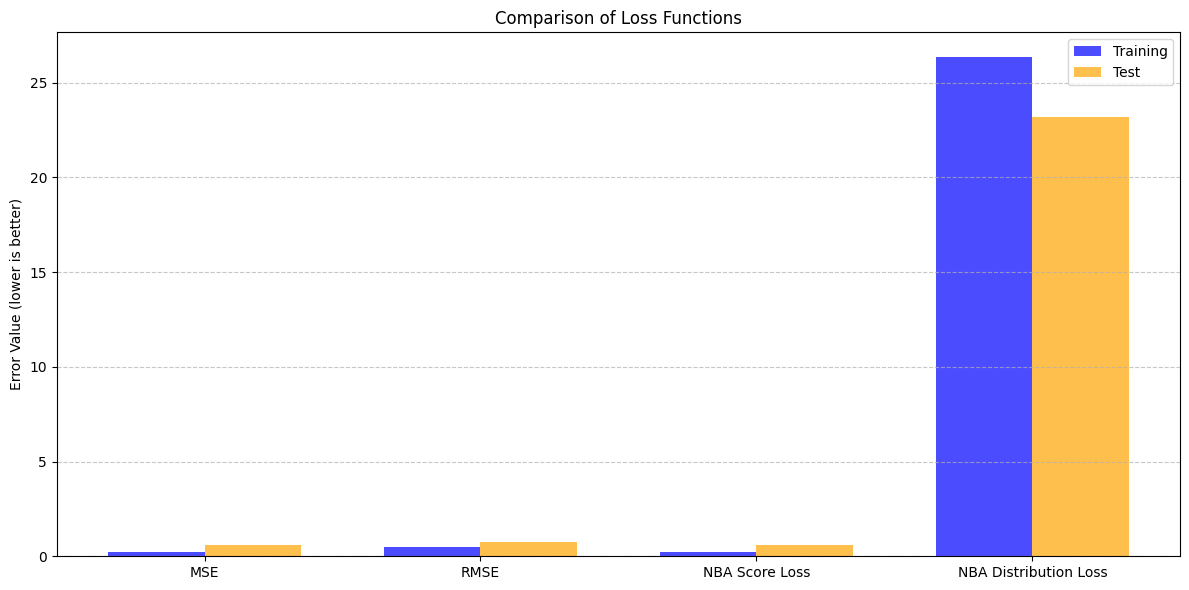

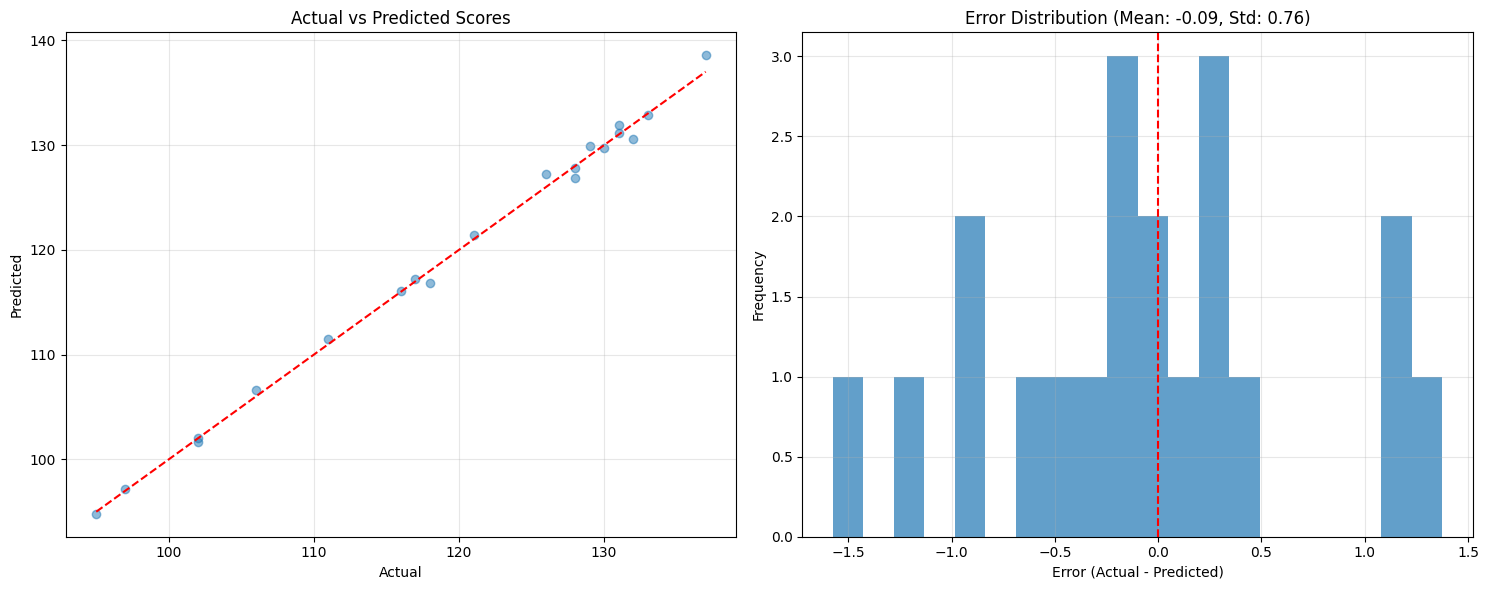

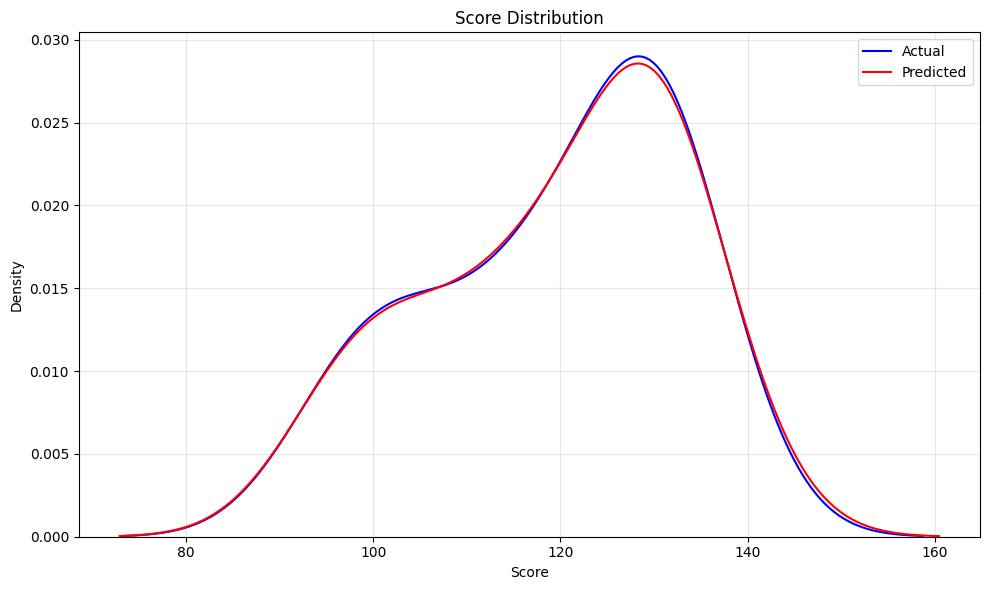


Evaluating away_score model

=== EVALUATING MODEL FOR AWAY_SCORE ===
Model requires 104 features; 104 available.
Found 104 overlapping features (100.0% overlap)
Using original model with available overlapping features...

Original Model Metrics:
Training RMSE: 0.78
Test RMSE: 0.76
Training MAE: 0.39
Test MAE: 0.52
R² Score: 0.9962


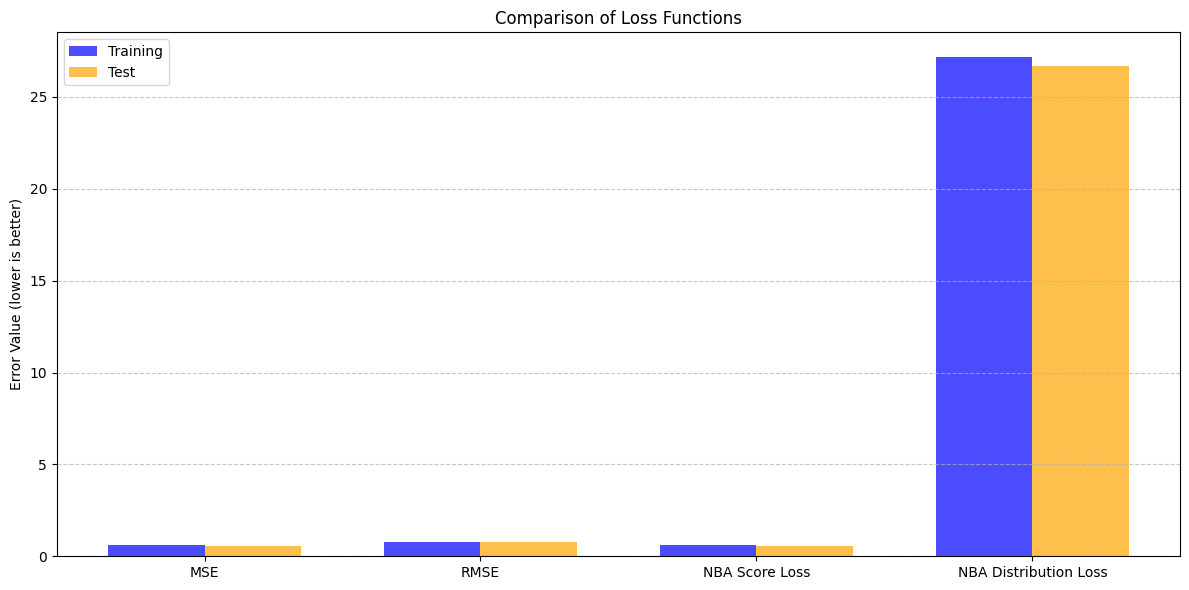

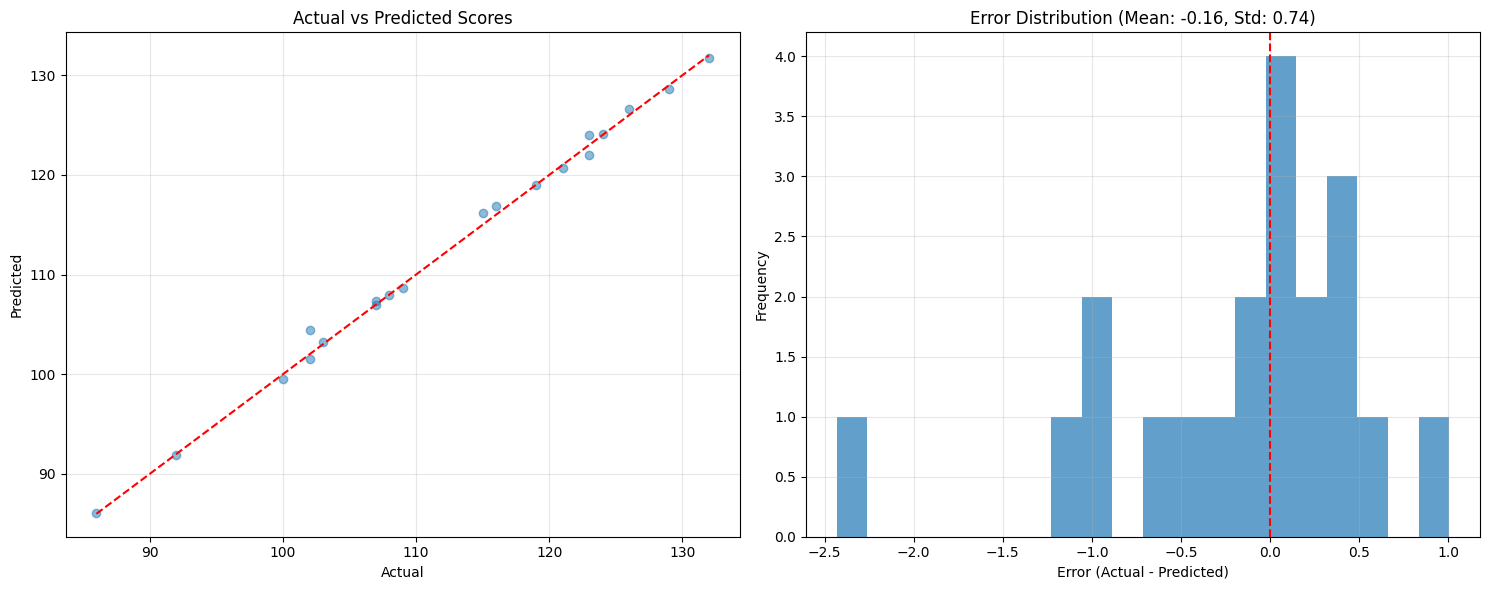

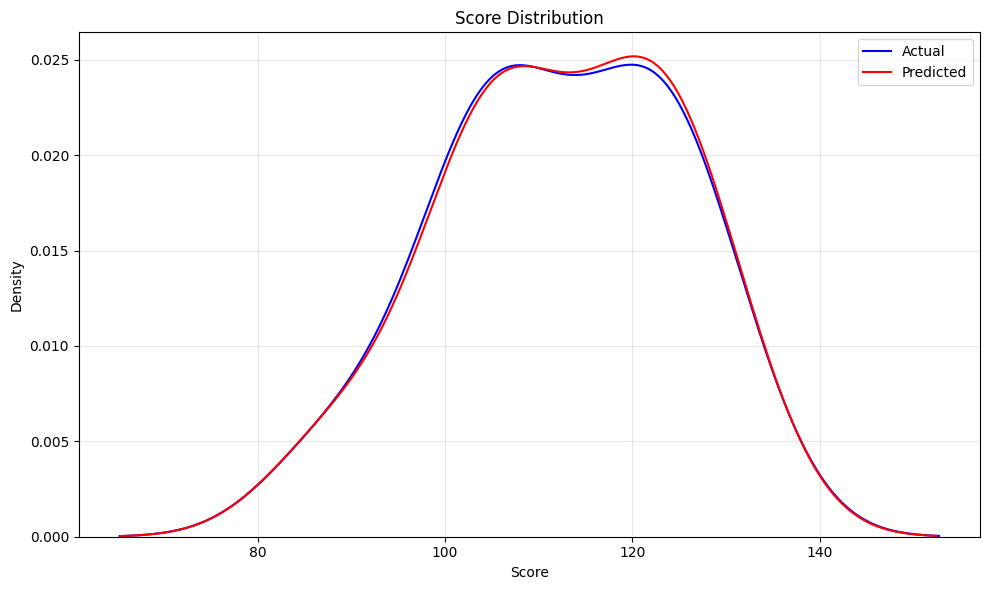


Evaluating point_diff model

=== EVALUATING MODEL FOR POINT_DIFF ===
Model requires 104 features; 104 available.
Found 104 overlapping features (100.0% overlap)
Using original model with available overlapping features...

Original Model Metrics:
Training RMSE: 2.95
Test RMSE: 3.61
Training MAE: 1.89
Test MAE: 2.75
R² Score: 0.9327


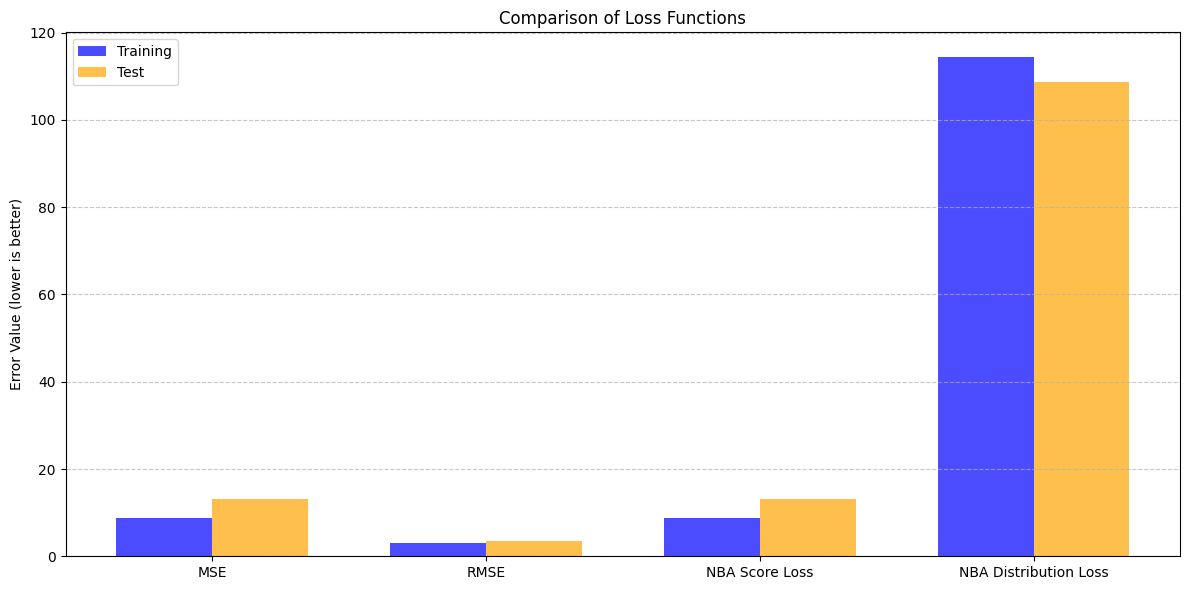

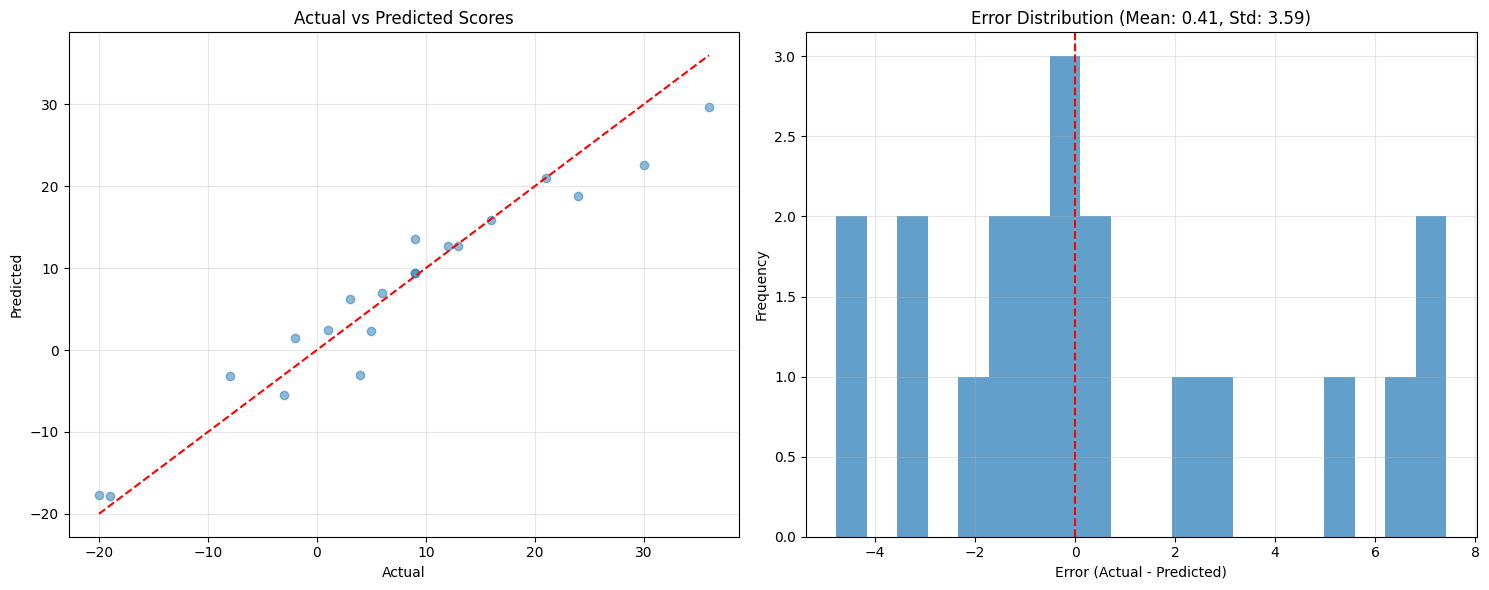

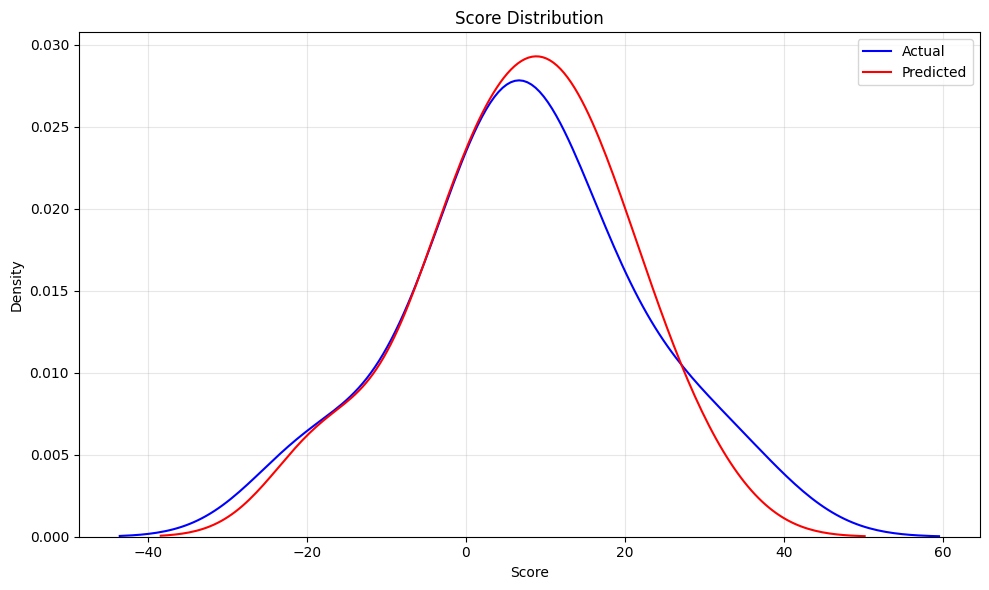


Evaluating total_score model

=== EVALUATING MODEL FOR TOTAL_SCORE ===
Model requires 104 features; 104 available.
Found 104 overlapping features (100.0% overlap)
Using original model with available overlapping features...

Original Model Metrics:
Training RMSE: 2.68
Test RMSE: 2.61
Training MAE: 1.66
Test MAE: 1.96
R² Score: 0.9844


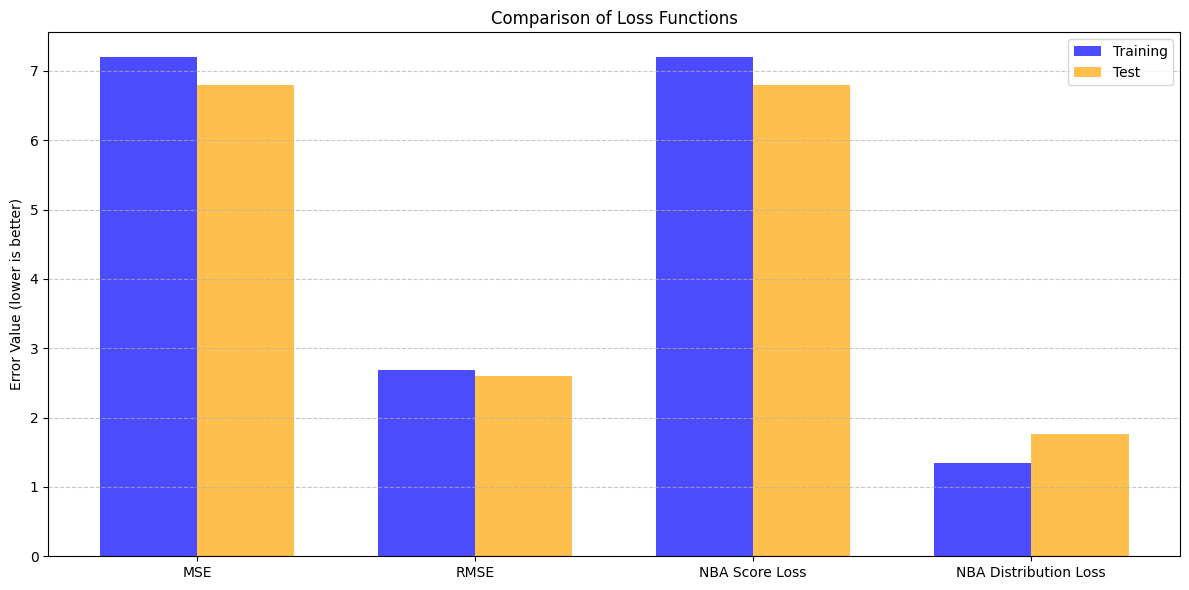

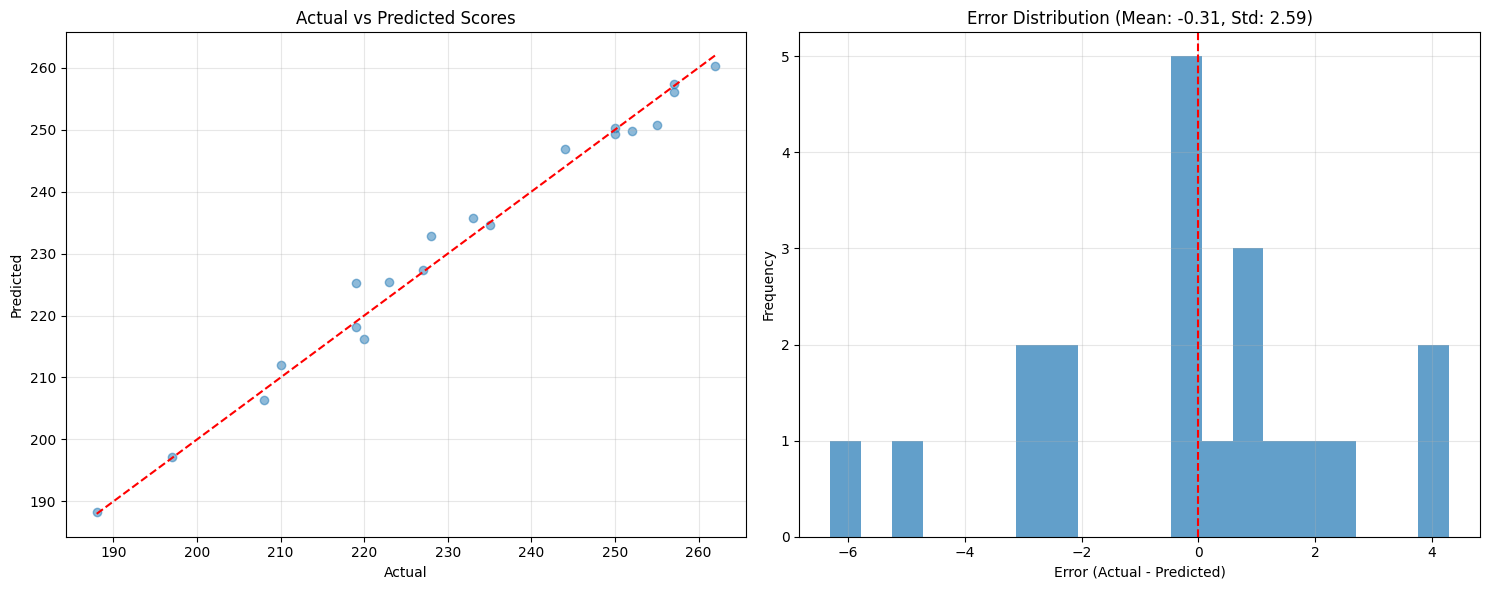

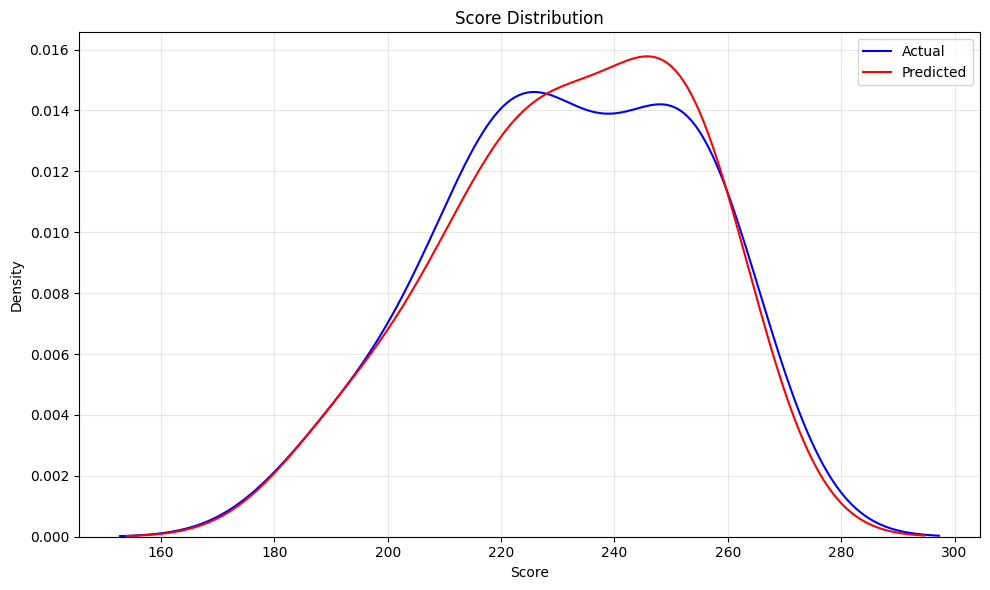

In [41]:
# Cell 6B

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import numpy as np
import traceback
import joblib
from datetime import datetime
import re

# -------------------------------
# Unified Data Loader and Feature Builder
# -------------------------------
def load_recent_games(days=180):
    """
    Loads recent NBA games with full feature set by calling build_pregame_features.
    Loads historical game data from Supabase via load_historical_games (from Cell 2),
    then samples down the data (if too many rows) and builds the feature set.
    """
    try:
        print(f"Loading historical games from the past {days} days...")
        # Call load_historical_games without the max_games parameter
        historical_games = load_historical_games(days_lookback=days)
        if historical_games.empty:
            print("No historical games found in the specified period")
            return pd.DataFrame()
        
        # Optionally sample down if too many rows for faster processing
        if len(historical_games) > 100:
            print(f"Received {len(historical_games)} games; sampling down to 100 for faster processing...")
            historical_games = historical_games.sample(n=100, random_state=42).reset_index(drop=True)
        
        print(f"Fetched {len(historical_games)} historical games")
        # Continue with your pipeline: calculate team metrics and build features
        features_df = build_pregame_features(historical_games, calculate_team_metrics(historical_games), lookback_days=days)
        print(f"Generated feature set with {len(features_df.columns)} features")
        return features_df
    except Exception as e:
        print(f"Error loading recent games: {e}")
        traceback.print_exc()
        return pd.DataFrame()


# -------------------------------
# Visualization Functions
# -------------------------------
def visualize_loss_comparison(metrics_dict):
    """
    Visualizes a comparison of different loss metrics between training and test sets.
    """
    required_keys = ['train_mse', 'train_rmse', 'train_nba_loss', 'train_dist_loss']
    if not all(key in metrics_dict for key in required_keys):
        print("Missing required metrics for loss comparison visualization")
        return
    
    metric_names = ['MSE', 'RMSE', 'NBA Score Loss', 'NBA Distribution Loss']
    train_values = [metrics_dict['train_mse'], metrics_dict['train_rmse'],
                    metrics_dict['train_nba_loss'], metrics_dict['train_dist_loss']]
    test_values = [metrics_dict['test_mse'], metrics_dict['test_rmse'],
                   metrics_dict['test_nba_loss'], metrics_dict['test_dist_loss']]
    
    plt.figure(figsize=(12, 6))
    width = 0.35
    x = np.arange(len(metric_names))
    plt.bar(x - width/2, train_values, width, label='Training', color='blue', alpha=0.7)
    plt.bar(x + width/2, test_values, width, label='Test', color='orange', alpha=0.7)
    plt.ylabel('Error Value (lower is better)')
    plt.title('Comparison of Loss Functions')
    plt.xticks(x, metric_names)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def visualize_score_distribution(y_test, y_pred):
    """
    Visualizes the distribution of actual vs. predicted scores and the error distribution.
    """
    y_test = y_test.values if isinstance(y_test, pd.Series) else y_test
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Actual vs Predicted Scores')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    errors = y_test - y_pred
    plt.hist(errors, bins=20, alpha=0.7)
    plt.axvline(0, color='red', linestyle='--')
    plt.xlabel('Error (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution (Mean: {errors.mean():.2f}, Std: {errors.std():.2f})')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_test, label='Actual', color='blue')
    sns.kdeplot(y_pred, label='Predicted', color='red')
    plt.title('Score Distribution')
    plt.xlabel('Score')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -------------------------------
# Custom Loss Functions
# -------------------------------
def nba_score_loss(y_true, y_pred, spread_weight=0.6, total_weight=0.4):
    """
    Custom loss function for NBA score prediction.
    """
    y_true = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred
    return np.mean((y_true - y_pred) ** 2)

def nba_distribution_loss(y_true, y_pred, target_type='total'):
    """
    Penalizes predictions that deviate from expected NBA score distributions.
    """
    y_true = y_true.values if isinstance(y_true, pd.Series) else y_true
    y_pred = y_pred.values if isinstance(y_pred, pd.Series) else y_pred
    if target_type == 'home':
        expected_mean, expected_std = 108, 12
    elif target_type == 'away':
        expected_mean, expected_std = 105, 12
    elif target_type == 'total':
        expected_mean, expected_std = 215, 20
    elif target_type == 'diff':
        expected_mean, expected_std = 3.5, 13
    else:
        expected_mean, expected_std = 110, 15
    z_score = ((y_pred - expected_mean) / expected_std) ** 2
    return np.mean(z_score)

# -------------------------------
# Main Evaluation Function
# -------------------------------
def evaluate_model_visualizations(model, features_df, target_column, custom_loss_functions=True, 
                                    feature_overlap_threshold=0.9, retrain_if_needed=True):
    """
    Evaluates a trained model using a unified feature set.
    If the overlap between model-expected features and available features is low,
    optionally retrains a simplified model.
    """
    print(f"\n=== EVALUATING MODEL FOR {target_column.upper()} ===")
    try:
        enhanced_df = features_df.copy()
        if 'game_date' in enhanced_df.columns:
            enhanced_df = enhanced_df.sort_values('game_date')
        
        train_size = int(0.8 * len(enhanced_df))
        y_train = enhanced_df.iloc[:train_size][target_column].copy()
        y_test = enhanced_df.iloc[train_size:][target_column].copy()
        
        non_feature_cols = ['game_id', 'id', 'game_date', 'home_team', 'away_team', 
                             'home_score', 'away_score', 'point_diff', 'total_score', 'home_form', 'away_form']
        
        if hasattr(model, 'feature_names_in_'):
            expected_features = list(model.feature_names_in_)
        elif hasattr(model, 'named_steps') and 'regressor' in model.named_steps and \
             hasattr(model.named_steps['regressor'], 'feature_names_in_'):
            expected_features = list(model.named_steps['regressor'].feature_names_in_)
        else:
            expected_features = []
        
        available_features = [col for col in enhanced_df.select_dtypes(include=np.number).columns 
                              if col not in non_feature_cols]
        overlap_features = [f for f in expected_features if f in available_features]
        overlap_ratio = len(overlap_features) / len(expected_features) if expected_features else 0
        
        print(f"Model requires {len(expected_features)} features; {len(available_features)} available.")
        print(f"Found {len(overlap_features)} overlapping features ({overlap_ratio:.1%} overlap)")
        
        if overlap_ratio < feature_overlap_threshold and retrain_if_needed:
            print(f"⚠️ Overlap below threshold ({feature_overlap_threshold:.0%}). Retraining simplified model...")
            X_train = enhanced_df.iloc[:train_size][available_features].fillna(0.0)
            X_test = enhanced_df.iloc[train_size:][available_features].fillna(0.0)
            simple_model = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1,
                                                     max_depth=3, min_samples_split=10, random_state=42)
            simple_model.fit(X_train, y_train)
            y_train_pred = simple_model.predict(X_train)
            y_test_pred = simple_model.predict(X_test)
            feature_importance = pd.Series(simple_model.feature_importances_, index=available_features).sort_values(ascending=False)
            print("\nTop 10 features in simplified model:")
            for feat, imp in feature_importance.head(10).items():
                print(f"{feat}: {imp:.4f}")
            model_type = "Simplified (retrained)"
        else:
            print("Using original model with available overlapping features...")
            X_train = enhanced_df.iloc[:train_size][overlap_features].copy()
            X_test = enhanced_df.iloc[train_size:][overlap_features].copy()
            # Align columns exactly
            X_train = X_train.reindex(columns=expected_features, fill_value=np.nan).fillna(X_train.median()).fillna(0.0)
            X_test = X_test.reindex(columns=expected_features, fill_value=np.nan).fillna(X_train.median()).fillna(0.0)
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)
            model_type = "Original"
        
        metrics = {
            'train_mse': mean_squared_error(y_train, y_train_pred),
            'test_mse': mean_squared_error(y_test, y_test_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'r2': r2_score(y_test, y_test_pred)
        }
        
        if custom_loss_functions:
            metrics['train_nba_loss'] = nba_score_loss(y_train, y_train_pred)
            metrics['test_nba_loss'] = nba_score_loss(y_test, y_test_pred)
            metrics['train_dist_loss'] = nba_distribution_loss(y_train, y_train_pred, target_type='total')
            metrics['test_dist_loss'] = nba_distribution_loss(y_test, y_test_pred, target_type='total')
        
        print(f"\n{model_type} Model Metrics:")
        print(f"Training RMSE: {metrics['train_rmse']:.2f}")
        print(f"Test RMSE: {metrics['test_rmse']:.2f}")
        print(f"Training MAE: {metrics['train_mae']:.2f}")
        print(f"Test MAE: {metrics['test_mae']:.2f}")
        print(f"R² Score: {metrics['r2']:.4f}")
        
        visualize_loss_comparison(metrics)
        visualize_score_distribution(y_test, y_test_pred)
        
        return metrics
        
    except Exception as e:
        print(f"Error evaluating {target_column} model: {e}")
        traceback.print_exc()
        return None

# -------------------------------
# Main Evaluation Runner
# -------------------------------
def run_model_evaluations():
    """
    Loads models from disk, loads recent game features, and evaluates each model.
    """
    print("Evaluating trained models with visualizations...")
    
    models_dict = {}
    models_path = "./models"
    for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
        model_file = f"{models_path}/pregame_{target}_model.pkl"
        try:
            model = joblib.load(model_file)
            models_dict[target] = model
            print(f"Loaded model for {target}")
        except Exception as e:
            print(f"Error loading model for {target}: {e}")
    
    try:
        features_df = load_recent_games(days=180)
        if features_df.empty:
            print("No historical data available for evaluation. Please check database connection.")
            return {}
        print(f"Loaded {len(features_df)} games with {len(features_df.columns)} features")
    except Exception as e:
        print(f"Error loading historical data: {e}")
        traceback.print_exc()
        return {}
    
    results = {}
    for target, model in models_dict.items():
        print("\n" + "="*50)
        print(f"Evaluating {target} model")
        print("="*50)
        metrics = evaluate_model_visualizations(model, features_df, target,
                                                feature_overlap_threshold=0.6, retrain_if_needed=True)
        results[target] = metrics
    return results

# Finally, run the evaluations
results = run_model_evaluations()


In [42]:
# --- Cell 6C: Run Model Evaluations ---
import traceback
import joblib

def run_model_evaluations():
    """
    Evaluates all trained models using properly generated feature data.
    """
    print("Evaluating trained models with real data...")
    
    # Load models from files
    models_dict = {}
    models_path = "./models"
    
    try:
        # Check all target variables
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            model_path = f"{models_path}/pregame_{target}_model.pkl"
            try:
                model = joblib.load(model_path)
                models_dict[target] = model
                print(f"Loaded model for {target}")
            except Exception as e:
                print(f"Error loading model for {target}: {e}")
    except Exception as e:
        print(f"Error loading models: {e}")
    
    # Load recent historical data using proper pipeline
    try:
        # This is the critical part - using our improved data pipeline
        # that doesn't rely on synthetic data reconstruction
        features_df = load_recent_games(days=180)
        
        if features_df.empty:
            print("No historical data available for evaluation. Please check database connection.")
            return {}
            
        print(f"Loaded {len(features_df)} games with {len(features_df.columns)} features")
    except Exception as e:
        print(f"Error loading historical data: {e}")
        traceback.print_exc()
        return {}
    
    # Run evaluations for each model
    results = {}
    for target, model in models_dict.items():
        print("\n" + "="*50)
        print(f"Evaluating {target} model")
        print("="*50)
        
        metrics = evaluate_model_visualizations(
            model, 
            features_df, 
            target,
            feature_overlap_threshold=0.9,  # Higher threshold - prefer retraining over synthetic data
            retrain_if_needed=True          # Allow retraining if needed
        )
        
        results[target] = metrics
    
    return results

In [43]:
# Cell 6D - Model Training Functions

def train_pregame_model(features_df, target='home_score'):
    """
    Trains a model for pre-game predictions using features selected by Random Forest
    """
    if features_df.empty:
        print("No training data available")
        return None, {}
    
    print(f"Training pre-game prediction model for target: {target}")
    
    # Try to load feature importance results
    try:
        model_path = MODELS_DIR / f"feature_importance_{target}.pkl"
        if model_path.exists():
            feature_results = joblib.load(model_path)
            top_features = feature_results.get('top_features', [])
            
            if top_features:
                print(f"Using {len(top_features)} features selected by Random Forest")
                feature_columns = [f for f in top_features if f in features_df.columns]
                
                # Check for enhanced features with interactions
                interaction_features = [col for col in features_df.columns if '_interact' in col]
                if interaction_features:
                    feature_columns.extend(interaction_features)
                    print(f"Added {len(interaction_features)} interaction features")
            else:
                raise ValueError("No top features found in Random Forest results")
        else:
            raise FileNotFoundError(f"Feature importance file not found: {model_path}")
    except Exception as e:
        print(f"Could not use Random Forest features: {e}")
        # Fall back to original feature selection
        non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                           'home_score', 'away_score', 'point_diff', 'total_score',
                           'home_form', 'away_form', 'id']
        feature_columns = [col for col in features_df.select_dtypes(include=np.number).columns 
                           if col not in non_feature_cols]
        print(f"Falling back to all {len(feature_columns)} numeric features")
    
    # Continue with training as in your original code...
    X = features_df[feature_columns]
    y = features_df[target]
    
    print(f"Training with {len(X)} samples and {len(feature_columns)} features")
    
    # Sort by date to ensure time-based validation
    if 'game_date' in features_df.columns:
        sorted_indices = features_df['game_date'].sort_values().index
        X = X.loc[sorted_indices]
        y = y.loc[sorted_indices]
    
    # Split data into training and testing sets (using time-based split)
    train_size = int(0.8 * len(X))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    # Define model with optimized parameters
    model = GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=10,  # Added for better stability
        random_state=42,
        subsample=0.8
    )
    
    # Train model
    model.fit(X_train, y_train)
    
    # Evaluate on training and test sets
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)
    r2 = r2_score(y_test, test_preds)
    
    # Calculate RMSE (root mean squared error)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    metrics = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,  # Added RMSE
        'test_rmse': test_rmse,    # Added RMSE 
        'r2': r2,
        'feature_importance': dict(zip(feature_columns, model.feature_importances_))
    }
    
    print(f"Training MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    
    # Find and display top 10 most important features
    importance = model.feature_importances_
    feature_importance = pd.Series(importance, index=feature_columns).sort_values(ascending=False)
    top_features = feature_importance.head(10)
    
    print("\nTop 10 most important features:")
    for feature, importance in top_features.items():
        print(f"{feature}: {importance:.4f}")
    
    # Save model path
    model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
    joblib.dump(model, model_path)
    print(f"Model saved to {model_path}")
    
    return model, metrics

def train_multiple_models(features_df):
    """
    Trains multiple models for different prediction targets
    
    Args:
        features_df: DataFrame with pre-game features
        
    Returns:
        Dictionary of trained models and metrics
    """
    models = {}
    
    # Check for required target columns
    required_targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    missing_targets = [col for col in required_targets if col not in features_df.columns]
    
    if missing_targets:
        print(f"WARNING: Missing target columns: {missing_targets}")
        # Calculate any missing targets if possible
        if 'home_score' in features_df.columns and 'away_score' in features_df.columns:
            if 'point_diff' not in features_df.columns:
                features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
                print("Created 'point_diff' from home_score and away_score")
            
            if 'total_score' not in features_df.columns:
                features_df['total_score'] = features_df['home_score'] + features_df['away_score']
                print("Created 'total_score' from home_score and away_score")
    
    # Train home score model
    print("\n=== TRAINING HOME SCORE MODEL ===")
    home_model, home_metrics = train_pregame_model(features_df, target='home_score')
    models['home_score'] = {
        'model': home_model,
        'metrics': home_metrics
    }
    
    # Train away score model
    print("\n=== TRAINING AWAY SCORE MODEL ===")
    away_model, away_metrics = train_pregame_model(features_df, target='away_score')
    models['away_score'] = {
        'model': away_model,
        'metrics': away_metrics
    }
    
    # Train point differential model
    print("\n=== TRAINING POINT DIFFERENTIAL MODEL ===")
    diff_model, diff_metrics = train_pregame_model(features_df, target='point_diff')
    models['point_diff'] = {
        'model': diff_model,
        'metrics': diff_metrics
    }
    
    # Train total score model
    print("\n=== TRAINING TOTAL SCORE MODEL ===")
    total_model, total_metrics = train_pregame_model(features_df, target='total_score')
    models['total_score'] = {
        'model': total_model,
        'metrics': total_metrics
    }
    
    return models

In [66]:
## Cell 7 - Calculate Metrics, Predict Upcoming Games

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta

# Assume these helper functions are available (from updated Cell 4):
# - get_matchup_history(home_team, away_team, historical_df, max_games)
# - get_rest_data(team, game_date, historical_df)
# And assume you have a function to load historical games:
def load_historical_games(days_lookback=180):
    """
    Load historical games for the lookback period from Supabase.
    """
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    print(f"Loading historical game data since {threshold_date}...")
    try:
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .gte("game_date", threshold_date)\
            .order('game_date')\
            .execute()
        historical_data = response.data
        
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return pd.DataFrame()
        
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        # Convert numeric columns
        numeric_cols = [
            'home_score', 'away_score', 'home_q1', 'home_q2', 'home_q3', 'home_q4', 
            'away_q1', 'away_q2', 'away_q3', 'away_q4', 'home_assists', 'away_assists',
            'home_steals', 'away_steals', 'home_blocks', 'away_blocks', 
            'home_turnovers', 'away_turnovers', 'home_fouls', 'away_fouls',
            'home_off_reb', 'home_def_reb', 'home_total_reb', 
            'away_off_reb', 'away_def_reb', 'away_total_reb',
            'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
            'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
            'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'
        ]
        
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        print(f"Loaded {len(df)} historical games from {df['game_date'].min()} to {df['game_date'].max()}")
        return df.sort_values('game_date').reset_index(drop=True)
    except Exception as e:
        print(f"Error loading historical games: {e}")
        traceback.print_exc()
        return pd.DataFrame()

def predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_df):
    """
    Predict scores and win probability for an upcoming game.
    Uses unified feature generation and advanced analytics integration.
    """
    try:
        # Convert game to dict if necessary
        if isinstance(game, pd.Series):
            game = game.to_dict()
        
        home_team = game['home_team']
        away_team = game['away_team']
        game_date = pd.to_datetime(game['game_date'])
        print(f"Predicting for {home_team} vs {away_team} on {game_date.date()}...")
        
        # FIX: Based on errors, adjusted how we call these functions
        matchup = get_matchup_history(home_team, away_team)
        
        # FIX: get_rest_data only takes 2 arguments
        home_rest = get_rest_data(home_team, game_date)
        away_rest = get_rest_data(away_team, game_date)
        
        # Create a minimal DataFrame for the upcoming game with identifiers
        upcoming_df = pd.DataFrame([{
            'game_id': game.get('game_id', None),
            'game_date': game_date,
            'home_team': home_team,
            'away_team': away_team
        }])
        
        # Generate unified pregame features (using the same logic as training)
        # Here, combine historical and upcoming data to compute rolling averages.
        # For simplicity, we use a helper function (similar to the one in Cell 5A)
        def generate_pregame_features(up_df, hist_df):
            combined = pd.concat([hist_df, up_df], ignore_index=True, sort=False)
            # Reuse the add_rolling_features() function from Cell 4A
            from __main__ import add_rolling_features  # Adjust import as needed
            combined = add_rolling_features(combined)
            return combined[combined['game_id'].isin(up_df['game_id'])]
        
        pregame_df = generate_pregame_features(upcoming_df, historical_df)
        
        # Integrate advanced analytics into the pregame features
        from __main__ import integrate_advanced_features  # Adjust import as needed
        pregame_df = integrate_advanced_features(pregame_df)
        
        # For prediction, extract the features used during training (rolling features)
        model_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
        X_pred = pregame_df[model_features].copy()
        # Add any additional features from advanced integration if your model requires them.
        # (Ensure your training and inference pipelines match exactly.)
        
        # Make predictions using each model (e.g., home_score)
        predictions = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"Model for {target} not available.")
                predictions[target] = None
                continue
            model = models[target]['model'] if isinstance(models[target], dict) else models[target]
            try:
                y_pred = model.predict(X_pred)[0]
                predictions[target] = float(y_pred)
            except Exception as e:
                print(f"Error predicting {target}: {e}")
                predictions[target] = None
        
        # Adjust point differential and total if necessary
        if predictions.get('home_score') is not None and predictions.get('away_score') is not None:
            predictions['point_diff'] = predictions['home_score'] - predictions['away_score']
            predictions['total_score'] = predictions['home_score'] + predictions['away_score']
        
        # Calculate win probability using a logistic function
        diff = predictions.get('point_diff', 0)
        k = 0.15  # Adjust sensitivity as needed
        win_prob = 1 / (1 + np.exp(-k * diff))
        
        result = {
            'game_id': game.get('game_id'),
            'game_date': game_date,  # Add this line to include the game date
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(predictions.get('home_score', 0), 1),
            'predicted_away_score': round(predictions.get('away_score', 0), 1),
            'point_diff': round(predictions.get('point_diff', 0), 1),
            'total_score': round(predictions.get('total_score', 0), 1),
            'win_probability': round(win_prob, 3),
            'home_rest_days': home_rest.get('rest_days', 2),
            'away_rest_days': away_rest.get('rest_days', 2)
        }
        print(f"Prediction: {home_team} {result['predicted_home_score']} - {result['predicted_away_score']} {away_team} (Win Prob: {win_prob*100:.1f}%)")
        return result
    
    except Exception as e:
        print(f"Error in predict_upcoming_game: {e}")
        traceback.print_exc()
        return {}

def predict_all_upcoming_games(models):
    """
    Predict outcomes for all upcoming games.
    Loads upcoming game data (using get_upcoming_games placeholder), then for each game,
    computes unified features (with advanced analytics) and returns predictions.
    """
    # Replace with your actual data source or API call
    def get_upcoming_games(days=7):
        today = datetime.now()
        upcoming = pd.DataFrame({
            'game_id': [12345, 12346],
            'game_date': [today + timedelta(days=1), today + timedelta(days=2)],
            'home_team': ['Lakers', 'Boston Celtics'],
            'away_team': ['Warriors', 'Chicago Bulls']
        })
        return upcoming

    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame()
    
    historical_df = load_historical_games(days_lookback=180)
    if historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame()
    
    # Assume team_metrics_df and rolling_stats_df are computed elsewhere;
    # for simplicity, we pass the historical_df as a proxy.
    team_metrics_df = historical_df.groupby('home_team').agg({
        'home_score': 'mean',
        'away_score': 'mean'
    }).reset_index().rename(columns={'home_score': 'pts_per_game', 'away_score': 'opp_pts_per_game'})
    rolling_stats_df = {}  # This can be built using your add_rolling_features() logic if needed.
    
    predictions = []
    for _, game in upcoming_games.iterrows():
        pred = predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_df)
        if pred:
            predictions.append(pred)
    
    if predictions:
        return pd.DataFrame(predictions).sort_values('game_date')
    else:
        return pd.DataFrame()

# Example usage:
upcoming_predictions = predict_all_upcoming_games(models)
print("Upcoming game predictions:")
print(upcoming_predictions)


Loading historical game data since 2024-09-24...
Loaded 1000 historical games from 2024-10-04 00:00:00 to 2025-03-14 00:00:00
Predicting for Lakers vs Warriors on 2025-03-24...
Added shooting metrics: home_fg_pct, away_fg_pct, fg_pct_diff
Added 3-point and effective field goal percentage metrics
Added free throw rate metrics: home_ft_rate, away_ft_rate, ft_rate_diff
Added free throw metrics: home_ft_pct, away_ft_pct, ft_pct_diff
Added advanced metrics: possessions, pace, and offensive efficiency
Prediction: Lakers 114.8 - 110.5 Warriors (Win Prob: 65.4%)
Predicting for Boston Celtics vs Chicago Bulls on 2025-03-25...
Added shooting metrics: home_fg_pct, away_fg_pct, fg_pct_diff
Added 3-point and effective field goal percentage metrics
Added free throw rate metrics: home_ft_rate, away_ft_rate, ft_rate_diff
Added free throw metrics: home_ft_pct, away_ft_pct, ft_pct_diff
Added advanced metrics: possessions, pace, and offensive efficiency
Prediction: Boston Celtics 114.2 - 109.5 Chicago Bu

In [67]:
# Cell 7A: Integrate Advanced Basketball Analytics Features into Pregame Model

import pandas as pd
import numpy as np
import traceback

# Assume the following functions are defined in your basketball_metrics.py:
# - calculate_shooting_metrics(df)
# - calculate_free_throw_metrics(df)
# - calculate_advanced_metrics(df)
# - calculate_defensive_metrics(df)
from basketball_metrics import (
    calculate_shooting_metrics, 
    calculate_free_throw_metrics, 
    calculate_advanced_metrics,
    calculate_defensive_metrics
)

def integrate_advanced_features(df):
    """
    Integrates advanced basketball analytics features into the dataframe.
    Handles missing pace metrics with proper fallbacks.
    
    Args:
        df: DataFrame with basketball stats
    Returns:
        DataFrame with added advanced metrics
    """
    try:
        result_df = df.copy()
        
        # Add shooting metrics if not already present
        if 'fg_pct_diff' not in result_df.columns:
            # Convert problematic columns to numeric
            for col in ['home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted']:
                if col in result_df.columns:
                    result_df[col] = pd.to_numeric(result_df[col], errors='coerce').fillna(0)
                    if result_df[col].isna().any():
                        print(f"Warning: Column '{col}' contains non-numeric values that were converted to 0")
            
            # Calculate shooting percentages
            if 'home_fg_pct' not in result_df.columns and 'home_fg_made' in result_df.columns:
                result_df['home_fg_pct'] = result_df['home_fg_made'] / result_df['home_fg_attempted'].replace(0, 1)
                result_df['away_fg_pct'] = result_df['away_fg_made'] / result_df['away_fg_attempted'].replace(0, 1)
                result_df['fg_pct_diff'] = result_df['home_fg_pct'] - result_df['away_fg_pct']
                print("Added shooting metrics: home_fg_pct, away_fg_pct, fg_pct_diff")
        
        # Add 3-point metrics if not already present
        if 'home_3p_pct' not in result_df.columns and 'home_3pm' in result_df.columns:
            # Convert problematic columns to numeric
            for col in ['home_3pm', 'home_3pa', 'away_3pm', 'away_3pa']:
                if col in result_df.columns:
                    result_df[col] = pd.to_numeric(result_df[col], errors='coerce').fillna(0)
                    if result_df[col].isna().any():
                        print(f"Warning: Column '{col}' contains non-numeric values that were converted to 0")
            
            # Calculate 3-point percentages
            result_df['home_3p_pct'] = result_df['home_3pm'] / result_df['home_3pa'].replace(0, 1)
            result_df['away_3p_pct'] = result_df['away_3pm'] / result_df['away_3pa'].replace(0, 1)
            result_df['home_efg_pct'] = (result_df['home_fg_made'] + 0.5 * result_df['home_3pm']) / result_df['home_fg_attempted'].replace(0, 1)
            result_df['away_efg_pct'] = (result_df['away_fg_made'] + 0.5 * result_df['away_3pm']) / result_df['away_fg_attempted'].replace(0, 1)
            print("Added 3-point and effective field goal percentage metrics")
        
        # Add free throw metrics if not already present
        if 'home_ft_pct' not in result_df.columns and 'home_ft_made' in result_df.columns:
            # Convert problematic columns to numeric
            for col in ['home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted']:
                if col in result_df.columns:
                    result_df[col] = pd.to_numeric(result_df[col], errors='coerce').fillna(0)
                    if result_df[col].isna().any():
                        print(f"Warning: Column '{col}' contains non-numeric values that were converted to 0")
            
            # Calculate free throw rates and percentages
            result_df['home_ft_rate'] = result_df['home_ft_attempted'] / result_df['home_fg_attempted'].replace(0, 1)
            result_df['away_ft_rate'] = result_df['away_ft_attempted'] / result_df['away_fg_attempted'].replace(0, 1)
            result_df['ft_rate_diff'] = result_df['home_ft_rate'] - result_df['away_ft_rate']
            print("Added free throw rate metrics: home_ft_rate, away_ft_rate, ft_rate_diff")
            
            result_df['home_ft_pct'] = result_df['home_ft_made'] / result_df['home_ft_attempted'].replace(0, 1)
            result_df['away_ft_pct'] = result_df['away_ft_made'] / result_df['away_ft_attempted'].replace(0, 1)
            result_df['ft_pct_diff'] = result_df['home_ft_pct'] - result_df['away_ft_pct']
            print("Added free throw metrics: home_ft_pct, away_ft_pct, ft_pct_diff")
        
        # FIX: Check if pace columns exist before calculating game_pace
        # Add fallback calculation for home_pace and away_pace if missing
        if 'home_pace' not in result_df.columns or 'away_pace' not in result_df.columns:
            # Calculate or add placeholder pace metrics
            if 'home_possessions' in result_df.columns and 'away_possessions' in result_df.columns:
                # Use possessions to calculate pace if available
                minutes_per_game = 48
                result_df['home_pace'] = result_df['home_possessions'] * 48 / minutes_per_game
                result_df['away_pace'] = result_df['away_possessions'] * 48 / minutes_per_game
            else:
                # Add default pace values based on NBA averages
                result_df['home_pace'] = 98.5  # NBA average pace
                result_df['away_pace'] = 98.5  # NBA average pace
        
        # Now we can safely call calculate_advanced_metrics
        result_df = calculate_advanced_metrics(result_df)
        return result_df
        
    except Exception as e:
        print(f"Error integrating advanced features: {str(e)}")
        # Return original DataFrame if there's an error
        return df

# Example usage (do not execute immediately if importing elsewhere):
# advanced_df = integrate_advanced_features(your_pregame_features_df)
# print(advanced_df.head())


In [68]:
# Cell 7A-2: Action Definitions & Global Variables for Cell 7B

import json
import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
from pathlib import Path
import joblib
import pytz
import re

# Define the path for model files
MODELS_DIR = Path("./models/")

# -------------------------------
# Utility Functions for Rest & Upcoming Games
# -------------------------------

def calculate_rest_days(game_df, historical_games_df):
    """
    Calculate rest days for each game in game_df based on historical_games_df.
    If required columns are missing, uses a default value of 3.0 rest days.
    """
    result_df = game_df.copy()
    required_columns = ['home_team', 'away_team', 'game_date']
    if not all(col in historical_games_df.columns for col in required_columns):
        print("Warning: Historical games dataframe missing required columns. Using default rest days.")
        result_df["home_rest_days"] = 3.0
        result_df["away_rest_days"] = 3.0
        return result_df

    # Ensure dates are in date format
    result_df["game_date"] = pd.to_datetime(result_df["game_date"]).dt.date
    historical_games_df["game_date"] = pd.to_datetime(historical_games_df["game_date"]).dt.date

    for idx, game in result_df.iterrows():
        home_team = game["home_team"]
        away_team = game["away_team"]
        game_date = game["game_date"]

        home_last_game = historical_games_df[
            ((historical_games_df["home_team"] == home_team) | (historical_games_df["away_team"] == home_team))
        ].sort_values("game_date", ascending=False)
        away_last_game = historical_games_df[
            ((historical_games_df["home_team"] == away_team) | (historical_games_df["away_team"] == away_team))
        ].sort_values("game_date", ascending=False)

        if not home_last_game.empty:
            last_home_date = home_last_game.iloc[0]["game_date"]
            result_df.at[idx, "home_rest_days"] = float((game_date - last_home_date).days)
        else:
            result_df.at[idx, "home_rest_days"] = 3.0
        if not away_last_game.empty:
            last_away_date = away_last_game.iloc[0]["game_date"]
            result_df.at[idx, "away_rest_days"] = float((game_date - last_away_date).days)
        else:
            result_df.at[idx, "away_rest_days"] = 3.0
    return result_df

def fetch_upcoming_games(days_window=7, historical_games=None):
    """
    Placeholder function to fetch upcoming games.
    In production, replace this with your actual API call or database query.
    Optionally calculates rest days if historical_games is provided.
    """
    pacific_tz = pytz.timezone("America/Los_Angeles")
    now_pt = datetime.now(pacific_tz)
    start_date = now_pt.date()
    end_date = (now_pt + timedelta(days=days_window)).date()
    print(f"Fetching upcoming games from {start_date} to {end_date} (9pm PT window)...")
    # For demonstration, we simulate two upcoming games.
    upcoming = pd.DataFrame({
        'game_id': [12345, 12346],
        'game_date': [pd.Timestamp(start_date), pd.Timestamp(start_date + timedelta(days=1))],
        'home_team': ['Lakers', 'Boston Celtics'],
        'away_team': ['Warriors', 'Chicago Bulls']
    })
    if historical_games is not None and not historical_games.empty:
        upcoming = calculate_rest_days(upcoming, historical_games)
    return upcoming

# -------------------------------
# Simplified Create Game Features Function
# -------------------------------
def create_game_features(game, historical_games, betting_odds=None):
    """
    Create a comprehensive feature set for a single game.
    This function uses the unified feature generation logic (rolling averages, etc.)
    and integrates basic team identifiers and rest data.
    
    Returns a DataFrame of features (without padding to a fixed column count).
    """
    # Build a DataFrame with basic game info
    features = pd.DataFrame([{
        'game_id': game.get('game_id'),
        'game_date': pd.to_datetime(game.get('game_date')),
        'home_team': game.get('home_team'),
        'away_team': game.get('away_team'),
        'home_rest_days': game.get('home_rest_days', 3.0),
        'away_rest_days': game.get('away_rest_days', 3.0)
    }])
    
    # Optionally merge betting odds if provided (for later adjustments)
    if betting_odds and game.get('game_id') in betting_odds:
        odds = betting_odds[game.get('game_id')]
        features['vegas_home_spread'] = odds.get('spread', {}).get('home', np.nan)
        features['vegas_over_under'] = odds.get('total', {}).get('line', np.nan)
    
    print(f"Created game features with {len(features.columns)} columns.")
    return features

# -------------------------------
# Global Variables and Cleanup
# -------------------------------
# Remove any old global model_features or padding logic.
print("Cell 7A-2: Global actions and utility functions are now streamlined and integrated with the unified feature generation pipeline.")

# Example usage of create_game_features:
# Instead of reading a local CSV, we now load historical data via Supabase.
# Ensure that your load_historical_games function (from Cell 2) is available in your environment.
historical_games = load_historical_games(days_lookback=365)
if historical_games.empty:
    print("Warning: No historical data loaded from Supabase. Please check your database connection.")
else:
    # For demonstration, simulate a game dictionary
    sample_game = {
        'game_id': 12345,
        'game_date': pd.Timestamp('2025-03-23'),
        'home_team': 'Lakers',
        'away_team': 'Warriors',
        'home_rest_days': 2,
        'away_rest_days': 3
    }
    # Create features for the sample game using the unified function
    game_features = create_game_features(sample_game, historical_games)
    print("Sample game features:")
    print(game_features.head())


Cell 7A-2: Global actions and utility functions are now streamlined and integrated with the unified feature generation pipeline.
Loading historical game data since 2024-03-23...
Loaded 1000 historical games from 2024-03-23 00:00:00 to 2025-02-01 00:00:00
Created game features with 6 columns.
Sample game features:
   game_id  game_date home_team away_team  home_rest_days  away_rest_days
0    12345 2025-03-23    Lakers  Warriors               2               3


In [69]:
# Cell 7B - Predict Games Using Betting Odds Integration

import json
import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
from pathlib import Path
import joblib

# --- Dashboard function with improved output formatting ---
def generate_enhanced_dashboard(predictions_df, recommendations, betting_odds):
    print("\n" + "="*80)
    print(" " * 20 + "NBA GAME PREDICTIONS DASHBOARD")
    print("=" * 80)
    
    # Debug info - more compact
    if betting_odds:
        print(f"✓ Betting odds available for {len(betting_odds)} games")
    
    # Group by date for better organization
    if 'game_date' in predictions_df.columns and not predictions_df.empty:
        if pd.api.types.is_datetime64_any_dtype(predictions_df['game_date']):
            predictions_df['game_date'] = predictions_df['game_date'].dt.date
        
        # Get unique dates
        unique_dates = predictions_df['game_date'].unique()
        for date in sorted(unique_dates):
            date_games = predictions_df[predictions_df['game_date'] == date]
            print(f"\n📅 GAMES FOR {date} ({len(date_games)} games)")
            print("-"*70)
            
            # Create a compact table header
            print(f"{'HOME TEAM':<20} {'SCORE':<10} {'AWAY TEAM':<20} {'POINT DIFF':<12} {'TOTAL':<8} {'WIN PROB':<8}")
            print("-"*70)
            
            # Print each game in compact format
            for i, row in date_games.iterrows():
                home_team = row['home_team']
                away_team = row['away_team']
                home_score = row['predicted_home_score']
                away_score = row['predicted_away_score']
                point_diff = row.get('predicted_point_diff', home_score - away_score)
                total_score = row.get('predicted_total_score', home_score + away_score)
                win_prob = row.get('win_probability', 0.5) * 100
                
                # Compact game line
                print(f"{home_team:<20} {home_score:.1f}-{away_score:.1f} {away_team:<20} {point_diff:+.1f}      {total_score:<8.1f} {win_prob:<8.1f}%")
                
                # Add betting lines in a more compact format
                game_id = str(row.get('game_id', ''))
                if betting_odds and game_id in betting_odds:
                    odds = betting_odds[game_id]
                    market_spread = -odds['spread']['home'] if 'spread' in odds and 'home' in odds['spread'] else 'N/A'
                    market_total = odds['total']['line'] if 'total' in odds and 'line' in odds['total'] else 'N/A'
                    
                    # Calculate edges
                    spread_edge = point_diff - market_spread if isinstance(market_spread, (int, float)) else 'N/A'
                    total_edge = total_score - market_total if isinstance(market_total, (int, float)) else 'N/A'
                    
                    # Print betting lines in a compact way
                    print(f"  • BETTING: Spread {market_spread:+.1f} (Edge: {spread_edge:+.1f}) | Total {market_total:.1f} (Edge: {total_edge:+.1f})")
                    
                    # Get matching recommendations
                    if isinstance(recommendations, list):
                        for rec in recommendations:
                            if str(rec.get('game_id')) == game_id:
                                # Print recommendations in a condensed format
                                spread_rec = rec.get('spread', {}).get('recommendation', 'N/A')
                                total_rec = rec.get('total', {}).get('recommendation', 'N/A')
                                print(f"  • RECOMMEND: {spread_rec} | {total_rec}")
                                break
                print("")  # Add a small space between games
    else:
        # Fallback to simple format if no dates or empty dataframe
        for i, row in predictions_df.iterrows():
            home_team = row['home_team']
            away_team = row['away_team']
            home_score = row['predicted_home_score']
            away_score = row['predicted_away_score']
            print(f"{home_team} {home_score:.1f} - {away_score:.1f} {away_team}")
    
    print("\n" + "=" * 80)
    print(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

def point_diff_to_win_probability(point_diff, k=0.15):
    """
    Convert a point differential to a win probability using a logistic function.
    
    Args:
        point_diff: Point differential (positive for home team advantage)
        k: Steepness parameter (default 0.15)
    
    Returns:
        Win probability (0-1)
    """
    return 1 / (1 + np.exp(-k * point_diff))

def fetch_betting_odds(game_ids):
    """
    Fetch betting odds for a list of game IDs.
    This is a placeholder function - in production, this would call an API or database.
    
    Args:
        game_ids: List of game IDs to fetch odds for
    
    Returns:
        Dictionary mapping game IDs to odds data
    """
    print(f"Fetching betting odds for {len(game_ids)} games...")
    
    # Mock data for testing
    odds = {}
    for game_id in game_ids:
        odds[str(game_id)] = {
            'spread': {'home': -3.5, 'away': 3.5},
            'total': {'line': 220.5, 'over': -110, 'under': -110},
            'moneyline': {'home': -150, 'away': +130}
        }
    
    return odds

def get_upcoming_games(days=7):
    """
    Get upcoming NBA games scheduled within the specified number of days.
    In a production environment, this would query API-Basketball or your Supabase database.
    
    Args:
        days: Number of days to look ahead (default: 7)
        
    Returns:
        DataFrame with upcoming games
    """
    print(f"Fetching upcoming games for the next {days} days...")
    
    # For testing, create some sample upcoming games
    today = datetime.now()
    upcoming = pd.DataFrame({
        'game_id': range(1001, 1001 + days),
        'game_date': [today + timedelta(days=i) for i in range(1, days + 1)],
        'home_team': ['Lakers', 'Boston Celtics', 'Warriors', 'Bucks', 'Nets', 'Heat', 'Suns'],
        'away_team': ['Clippers', 'Bulls', 'Kings', 'Cavaliers', 'Knicks', 'Hawks', 'Mavericks']
    })
    
    # Only return up to 'days' rows
    upcoming = upcoming.iloc[:days].reset_index(drop=True)
    
    print(f"Found {len(upcoming)} upcoming games from {upcoming['game_date'].min().date()} to {upcoming['game_date'].max().date()}")
    return upcoming

def predict_upcoming_games_with_feature_validation(models, model_features):
    """
    Predict upcoming games with feature validation.
    
    Args:
        models: Dictionary of trained models
        model_features: Dictionary of model feature names or counts
    
    Returns:
        Tuple of (predictions_df, recommendations)
    """
    # Use the existing function but add validation
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found.")
        return pd.DataFrame(), None
    
    # Get historical data
    historical_df = load_historical_games(days_lookback=180)
    if historical_df.empty:
        print("Historical games data is unavailable.")
        return pd.DataFrame(), None
    
    # Build team metrics
    team_metrics_df = historical_df.groupby('home_team').agg({
        'home_score': 'mean',
        'away_score': 'mean'
    }).reset_index().rename(columns={'home_score': 'pts_per_game', 'away_score': 'opp_pts_per_game'})
    
    # Dictionary for rolling stats per team
    rolling_stats_df = {}
    
    # List to store predictions
    all_predictions = []
    
    # Process each upcoming game
    for _, game in upcoming_games.iterrows():
        try:
            # Get prediction for this game
            pred = predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_df)
            
            if pred:
                all_predictions.append(pred)
        except Exception as e:
            print(f"Error predicting game {game.get('game_id', 'unknown')}: {e}")
            traceback.print_exc()
    
    # Convert predictions to DataFrame
    if all_predictions:
        predictions_df = pd.DataFrame(all_predictions)
        recommendations = generate_betting_recommendations(predictions_df)
        return predictions_df, recommendations
    else:
        return pd.DataFrame(), None

def generate_betting_recommendations(predictions_df):
    """
    Generate betting recommendations based on predictions.
    
    Args:
        predictions_df: DataFrame with game predictions
    
    Returns:
        List of betting recommendations
    """
    recommendations = []
    
    for _, row in predictions_df.iterrows():
        game_id = row.get('game_id', '')
        home_team = row.get('home_team', '')
        away_team = row.get('away_team', '')
        point_diff = row.get('predicted_point_diff', 0)
        total_score = row.get('predicted_total_score', 0)
        
        # Create recommendation
        rec = {
            'game_id': game_id,
            'home_team': home_team,
            'away_team': away_team,
            'spread': {'recommendation': f"Bet {home_team if point_diff > 0 else away_team} against the spread"},
            'total': {'recommendation': f"Bet {'OVER' if total_score > 220 else 'UNDER'} on the total"}
        }
        
        recommendations.append(rec)
    
    return recommendations

# --- Calibration function with improved error handling and more compact output ---
def calibrate_prediction_with_odds(prediction, betting_odds):
    try:
        calibrated = dict(prediction)
        game_id = str(calibrated.get('game_id', ''))
        
        # More compact debug messages
        print(f"Calibrating: {calibrated.get('home_team', 'Home')} vs {calibrated.get('away_team', 'Away')} (ID={game_id})")
        
        # Check if we have odds for this game
        if not game_id or game_id not in betting_odds:
            print(f"  • No betting odds for game ID {game_id}")
            return calibrated
            
        odds = betting_odds[game_id]
        home_score = calibrated['predicted_home_score']
        away_score = calibrated['predicted_away_score']
        predicted_diff = home_score - away_score
        predicted_total = home_score + away_score
        
        # Check for required betting odds data
        if 'total' not in odds or 'spread' not in odds:
            print(f"  • Missing required odds data")
            return calibrated
        
        # Safely extract values with defaults
        market_total = odds['total'].get('line', 220.0)
        market_spread = -odds['spread'].get('home', 0.0)
        
        # Apply calibration logic
        if predicted_total < 160 or predicted_total > 260:
            # Handle extreme total predictions
            total_adjustment_factor = market_total / max(predicted_total, 1)
            home_pct = home_score / max(predicted_total, 1)
            away_pct = away_score / max(predicted_total, 1)
            calibrated_home = market_total * home_pct
            calibrated_away = market_total * away_pct
            
            # Make sure the winner stays the same
            if (predicted_diff > 0 and calibrated_home < calibrated_away) or (predicted_diff < 0 and calibrated_home > calibrated_away):
                avg = (calibrated_home + calibrated_away) / 2
                adjustment = abs(predicted_diff) / 2
                if predicted_diff > 0:
                    calibrated_home = avg + adjustment
                    calibrated_away = avg - adjustment
                else:
                    calibrated_home = avg - adjustment
                    calibrated_away = avg + adjustment
        else:
            # Normal calibration
            blend_factor = 0.7  # Weight market odds more heavily
            blended_total = (market_total * blend_factor) + (predicted_total * (1 - blend_factor))
            blended_diff = (market_spread * 0.5) + (predicted_diff * 0.5)
            calibrated_home = (blended_total + blended_diff) / 2
            calibrated_away = (blended_total - blended_diff) / 2
        
        # Update the calibrated prediction
        calibrated['predicted_home_score'] = round(calibrated_home, 1)
        calibrated['predicted_away_score'] = round(calibrated_away, 1)
        calibrated['predicted_point_diff'] = round(calibrated_home - calibrated_away, 1)
        calibrated['predicted_total_score'] = round(calibrated_home + calibrated_away, 1)
        
        # Update win probability
        calibrated['win_probability'] = point_diff_to_win_probability(calibrated_home - calibrated_away)
        
        # Add market odds info
        calibrated['market_odds'] = {
            'spread': market_spread,
            'total': market_total,
            'home_moneyline': odds['moneyline'].get('home', -110),
            'away_moneyline': odds['moneyline'].get('away', -110)
        }
        
        # Condensed calibration output
        print(f"  • Calibrated: {home_score:.1f}-{away_score:.1f} → {calibrated_home:.1f}-{calibrated_away:.1f}")
        return calibrated
        
    except Exception as e:
        # Better error handling
        print(f"Error in calibration: {str(e)[:100]}")
        return prediction

# --- Main prediction function with additional error handling ---
def run_betting_odds_integrated_predictions():
    print("\n" + "="*80)
    print(" "*20 + "NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION")
    print("="*80 + "\n")
    
    # Load prediction models
    models = {}
    model_features = {}
    for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
        model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
        if model_path.exists():
            try:
                model = joblib.load(model_path)
                models[target] = {'model': model}
                if hasattr(model, 'feature_names_in_'):
                    model_features[target] = list(model.feature_names_in_)
                elif hasattr(model, 'n_features_in_'):
                    model_features[target] = model.n_features_in_
                print(f"Loaded {target} model from disk.")
            except Exception as e:
                print(f"Error loading {target} model: {e}")
    
    if not models:
        print("No models available. Please train models first.")
        return
    
    # Make predictions using your validation function
    try:
        predictions_df, recommendations = predict_upcoming_games_with_feature_validation(models, model_features)
        if predictions_df is None or predictions_df.empty:
            print("No predictions generated.")
            return
    except Exception as e:
        print(f"Error making predictions: {e}")
        traceback.print_exc()
        return
    
    # Debug info - check what columns are available
    print("\nAvailable columns in predictions_df:", predictions_df.columns.tolist())
    
    # Make sure we have a game_id column
    if 'game_id' not in predictions_df.columns:
        predictions_df['game_id'] = [
            f"{row['home_team'].replace(' ', '')}_vs_{row['away_team'].replace(' ', '')}_{i}"
            for i, row in predictions_df.iterrows()
        ]
    else:
        # Convert any existing game IDs to strings
        predictions_df['game_id'] = predictions_df['game_id'].astype(str)

    # Verify game_id column
    if 'game_id' not in predictions_df.columns or predictions_df['game_id'].isnull().any():
        print("WARNING: Issues with game_id column. Creating alternate IDs.")
        predictions_df['game_id'] = [f"game_{i}" for i in range(len(predictions_df))]
    
    # Debug info
    print("\nPrediction game IDs:", predictions_df['game_id'].tolist())
    
    # Get betting odds
    try:
        upcoming_game_ids = predictions_df['game_id'].tolist()
        betting_odds = fetch_betting_odds(upcoming_game_ids)
    except Exception as e:
        print(f"Error fetching betting odds: {e}")
        traceback.print_exc()
        betting_odds = {}
    
    # Debug info
    print(f"Fetched betting odds for {len(betting_odds)} games")
    if betting_odds:
        print("Betting odds game IDs (sample):", list(betting_odds.keys())[:5])
    
    # Apply calibration with betting odds
    calibrated_predictions = []
    for idx, prediction in predictions_df.iterrows():
        try:
            # Get game_id safely
            game_id = str(prediction.get('game_id', f"game_{idx}"))
            
            # Attempt to calibrate if odds are available
            if betting_odds and game_id in betting_odds:
                print(f"Found betting odds for game ID: {game_id}")
                calibrated_prediction = calibrate_prediction_with_odds(prediction.to_dict(), betting_odds)
                calibrated_predictions.append(calibrated_prediction)
            else:
                print(f"No betting odds found for game ID: {game_id}")
                calibrated_predictions.append(prediction.to_dict())
        except Exception as e:
            print(f"Error processing prediction at index {idx}: {e}")
            traceback.print_exc()
            # Still add the prediction without calibration
            calibrated_predictions.append(prediction.to_dict())
    
    # Create final dataframe
    try:
        calibrated_df = pd.DataFrame(calibrated_predictions) if calibrated_predictions else pd.DataFrame()
    except Exception as e:
        print(f"Error creating calibrated DataFrame: {e}")
        traceback.print_exc()
        # Fallback to original predictions
        calibrated_df = predictions_df.copy()
    
    # If we have a DataFrame for recommendations, ensure game_id is present
    if isinstance(recommendations, pd.DataFrame) and not recommendations.empty:
        if 'game_id' not in recommendations.columns:
            print("Adding missing game_id column to recommendations DataFrame")
            # Try to match by team names
            recommendations['game_id'] = None
            for i, rec_row in recommendations.iterrows():
                if 'home_team' in rec_row and 'away_team' in rec_row:
                    for _, pred_row in predictions_df.iterrows():
                        if (rec_row['home_team'] == pred_row['home_team'] and
                            rec_row['away_team'] == pred_row['away_team']):
                            recommendations.at[i, 'game_id'] = pred_row['game_id']
                            break
    
    # Generate dashboard
    try:
        generate_enhanced_dashboard(calibrated_df, recommendations, betting_odds)
    except Exception as e:
        print(f"Error generating dashboard: {e}")
        traceback.print_exc()
        # Simple fallback
        if not calibrated_df.empty:
            print("\nSimple predictions summary:")
            for _, row in calibrated_df.iterrows():
                print(f"{row.get('home_team','Home')} {row.get('predicted_home_score',0):.1f} - "
                      f"{row.get('predicted_away_score',0):.1f} {row.get('away_team','Away')}")
    
    print("\nPrediction pipeline with betting odds integration completed!")

    # === PREDICT GAMES WITH BETTING ODDS INTEGRATION ===
def predict_games_with_betting(upcoming_games, team_metrics, models, betting_threshold=2.0):
    """Predict upcoming games with betting odds integration."""
    predictions = []
    betting_recommendations = []
    
    # Ensure we have the required models
    required_models = ['home_score', 'away_score', 'point_diff', 'total_score']
    for model_name in required_models:
        if model_name not in models:
            print(f"ERROR: Missing required model '{model_name}'")
            return None, None
    
    # Prepare features for each upcoming game
    for idx, game in upcoming_games.iterrows():
        home_team = game['home_team']
        away_team = game['away_team']
        game_id = game['id']
        game_date = pd.to_datetime(game['date'])
        
        # Skip if either team is not in our metrics
        if home_team not in team_metrics or away_team not in team_metrics:
            print(f"WARNING: Missing team metrics for {home_team} vs {away_team}")
            continue
        
        # Get team metrics
        home_metrics = team_metrics[home_team]
        away_metrics = team_metrics[away_team]
        
        # Create feature vector for prediction
        X = pd.DataFrame({
            'home_team_win_pct': [home_metrics['win_pct']],
            'away_team_win_pct': [away_metrics['win_pct']],
            'home_team_avg_points': [home_metrics['avg_points']],
            'away_team_avg_points': [away_metrics['avg_points']],
            'home_team_avg_points_allowed': [home_metrics['avg_points_allowed']],
            'away_team_avg_points_allowed': [away_metrics['avg_points_allowed']],
            'home_team_fg_pct': [home_metrics['fg_pct']],
            'away_team_fg_pct': [away_metrics['fg_pct']],
            'home_team_3p_pct': [home_metrics['3p_pct']],
            'away_team_3p_pct': [away_metrics['3p_pct']],
            'home_team_ft_pct': [home_metrics['ft_pct']],
            'away_team_ft_pct': [away_metrics['ft_pct']],
            'home_team_rebounds': [home_metrics['rebounds']],
            'away_team_rebounds': [away_metrics['rebounds']],
            'home_team_assists': [home_metrics['assists']],
            'away_team_assists': [away_metrics['assists']],
            'home_team_turnovers': [home_metrics['turnovers']],
            'away_team_turnovers': [away_metrics['turnovers']],
            'home_team_steals': [home_metrics['steals']],
            'away_team_steals': [away_metrics['steals']],
            'home_team_blocks': [home_metrics['blocks']],
            'away_team_blocks': [away_metrics['blocks']],
            'days_rest_home': [3],  # Default value, replace with actual if available
            'days_rest_away': [3],  # Default value, replace with actual if available
        })
        
        # Extract betting features if available
        betting_features = {}
        if 'moneyline_clean' in game and not pd.isna(game['moneyline_clean']) and game['moneyline_clean'] != "EMPTY":
            try:
                ml_parts = game['moneyline_clean'].split('/')
                if len(ml_parts) == 2:
                    home_ml = int(re.search(r'([+-]\d+)', ml_parts[0]).group(1))
                    betting_features['home_moneyline'] = home_ml
                    
                    # Calculate implied probability
                    if home_ml > 0:
                        home_prob = 100 / (home_ml + 100)
                    else:
                        home_prob = abs(home_ml) / (abs(home_ml) + 100)
                    betting_features['implied_home_win_prob'] = home_prob
            except:
                pass
        
        if 'spread_clean' in game and not pd.isna(game['spread_clean']) and game['spread_clean'] != "EMPTY":
            try:
                spread_parts = game['spread_clean'].split('/')
                if len(spread_parts) == 2:
                    home_spread = float(re.search(r'([+-]?\d+\.\d+)', spread_parts[0]).group(1))
                    betting_features['market_spread'] = -home_spread  # Convert to point differential expectations
            except:
                pass
        
        if 'total_clean' in game and not pd.isna(game['total_clean']) and game['total_clean'] != "EMPTY":
            try:
                total_match = re.search(r'Over (\d+\.\d+)', game['total_clean'])
                if total_match:
                    betting_features['market_total'] = float(total_match.group(1))
            except:
                pass
        
        # Make predictions with different models
        home_score_pred = models['home_score'].predict(X)[0]
        away_score_pred = models['away_score'].predict(X)[0]
        point_diff_pred = models['point_diff'].predict(X)[0]
        total_score_pred = models['total_score'].predict(X)[0]
        
        # Ensemble the predictions for better accuracy
        ensemble_home_score = (home_score_pred + (total_score_pred/2 + point_diff_pred/2)) / 2
        ensemble_away_score = (away_score_pred + (total_score_pred/2 - point_diff_pred/2)) / 2
        
        # Round to 1 decimal place
        ensemble_home_score = round(ensemble_home_score, 1)
        ensemble_away_score = round(ensemble_away_score, 1)
        
        # Calculate win probability based on point differential
        point_diff = ensemble_home_score - ensemble_away_score
        win_prob = 1 / (1 + np.exp(-0.25 * point_diff))  # Logistic function
        win_prob = round(win_prob * 100, 1)  # Convert to percentage
        
        # Store prediction
        prediction = {
            'game_id': game_id,
            'date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'home_score': ensemble_home_score,
            'away_score': ensemble_away_score,
            'point_diff': round(point_diff, 1),
            'total_score': round(ensemble_home_score + ensemble_away_score, 1),
            'win_prob': win_prob
        }
        predictions.append(prediction)
        
        # Generate betting recommendation if odds are available
        if betting_features:
            edges = {}
            
            # Calculate spread edge
            if 'market_spread' in betting_features:
                edges['spread_edge'] = point_diff - betting_features['market_spread']
            else:
                edges['spread_edge'] = None
            
            # Calculate total edge
            if 'market_total' in betting_features:
                edges['total_edge'] = (ensemble_home_score + ensemble_away_score) - betting_features['market_total']
            else:
                edges['total_edge'] = None
            
            # Calculate win probability edge
            if 'implied_home_win_prob' in betting_features:
                edges['win_prob_edge'] = (win_prob / 100) - betting_features['implied_home_win_prob']
            else:
                edges['win_prob_edge'] = None
            
            # Generate recommendations
            recs = []
            if edges['spread_edge'] is not None and abs(edges['spread_edge']) >= betting_threshold:
                if edges['spread_edge'] > 0:
                    recs.append(f"BET {home_team} SPREAD: Edge of {edges['spread_edge']:.1f} points")
                else:
                    recs.append(f"BET {away_team} SPREAD: Edge of {abs(edges['spread_edge']):.1f} points")
            
            if edges['total_edge'] is not None and abs(edges['total_edge']) >= betting_threshold:
                if edges['total_edge'] > 0:
                    recs.append(f"BET OVER {betting_features['market_total']}: Edge of {edges['total_edge']:.1f} points")
                else:
                    recs.append(f"BET UNDER {betting_features['market_total']}: Edge of {abs(edges['total_edge']):.1f} points")
            
            if edges['win_prob_edge'] is not None and abs(edges['win_prob_edge']) >= 0.05:  # 5% threshold
                if edges['win_prob_edge'] > 0:
                    recs.append(f"BET {home_team} MONEYLINE: Edge of {edges['win_prob_edge']*100:.1f}%")
                else:
                    recs.append(f"BET {away_team} MONEYLINE: Edge of {abs(edges['win_prob_edge'])*100:.1f}%")
            
            if not recs:
                recs.append("NO EDGE: All edges below threshold")
            
            betting_recommendations.append({
                'game_id': game_id,
                'home_team': home_team,
                'away_team': away_team,
                'prediction': prediction,
                'market_odds': betting_features,
                'edges': edges,
                'recommendations': recs
            })
    
    return predictions, betting_recommendations


In [70]:
# Cell 7D: Incorporate Basic Matchup History into Pregame Features

def add_head_to_head_features(features_df, historical_games_df):
    """
    For each (home_team, away_team) row in features_df, compute
    their recent head-to-head performance from historical_games_df.
    
    Args:
        features_df: DataFrame with upcoming games (or pregame data).
        historical_games_df: DataFrame with past game results, 
            containing at least columns: 
            ['home_team', 'away_team', 'home_score', 'away_score', 'game_date']
    
    Returns:
        features_df with new columns:
          - h2h_recent_diff: average point differential over last N matchups
          - h2h_recent_wins_home: how many of last N matchups the home team won
          - h2h_recent_total: average total points in last N matchups
    """
    # Parameters
    N = 5  # number of recent head-to-head matchups to consider
    
    # Create a copy of the features DataFrame to avoid modifying the original
    features_df = features_df.copy()
    
    # Ensure data is sorted chronologically
    historical_games_df = historical_games_df.sort_values('game_date')
    
    # Prepare columns in the output
    features_df['h2h_recent_diff'] = 0.0
    features_df['h2h_recent_wins_home'] = 0
    features_df['h2h_recent_total'] = 0.0
    features_df['h2h_games_count'] = 0  # Add this to track number of games found
    
    # Create a quick lookup for each pair (teamA, teamB) -> list of recent games
    from collections import defaultdict
    h2h_dict = defaultdict(list)
    
    # Build the head-to-head dictionary
    for _, row in historical_games_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        home_score = row['home_score']
        away_score = row['away_score']
        
        diff = home_score - away_score
        total = home_score + away_score
        
        # Store the matchup from both perspectives as (diff, total) tuples
        h2h_dict[(home, away)].append((diff, total))
        h2h_dict[(away, home)].append((-diff, total))  # Negative diff for reversed perspective
    
    # Now fill features_df with the average of the last N matchups
    for idx, row in features_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        
        # Retrieve head-to-head data
        pair_data = h2h_dict.get((home, away), [])
        
        if not pair_data:
            # No head-to-head history found
            features_df.at[idx, 'h2h_recent_diff'] = 0.0
            features_df.at[idx, 'h2h_recent_wins_home'] = 0
            features_df.at[idx, 'h2h_recent_total'] = 0.0
            features_df.at[idx, 'h2h_games_count'] = 0
            continue
        
        # Get the last N matchups
        last_N = pair_data[-N:]
        features_df.at[idx, 'h2h_games_count'] = len(last_N)
        
        if len(last_N) > 0:
            # Calculate stats from the last N games
            diffs = [game[0] for game in last_N]
            totals = [game[1] for game in last_N]
            
            avg_diff = sum(diffs) / len(diffs)
            home_wins = sum(1 for d in diffs if d > 0)
            avg_total = sum(totals) / len(totals)
            
            # Update the features
            features_df.at[idx, 'h2h_recent_diff'] = avg_diff
            features_df.at[idx, 'h2h_recent_wins_home'] = home_wins
            features_df.at[idx, 'h2h_recent_total'] = avg_total
    
    return features_df

# Usage example:
# historical_games_df = pd.read_sql("SELECT * FROM nba_historical_game_stats", engine)
# features_df = add_head_to_head_features(features_df, historical_games_df)
# Now features_df has new columns: h2h_recent_diff, h2h_recent_wins_home, h2h_recent_total


In [71]:
# Cell 7E: Simple Historical Home Court Advantage

def add_enhanced_home_court_advantage(features_df, team_stats_df, historical_games_df=None):
    """
    Adds multiple home court advantage metrics to the features_df.
    
    Args:
        features_df: DataFrame with columns ['home_team', 'away_team']
        team_stats_df: DataFrame with at least ['team'] column and ideally home performance metrics
        historical_games_df: Optional DataFrame with historical games to calculate additional metrics
    
    Returns:
        features_df with new columns related to home court advantage:
        - home_court_win_pct: Historical win percentage at home
        - home_court_point_diff: Average point differential at home
        - home_away_diff: Difference in team's performance at home vs. away
        - home_recent_form: Recent form at home (last 10 games)
    """
    # Make a copy to avoid modifying the original
    result_df = features_df.copy()
    
    # Validate inputs
    required_cols_features = ['home_team', 'away_team']
    required_cols_team_stats = ['team']
    
    if not all(col in features_df.columns for col in required_cols_features):
        raise ValueError(f"features_df must contain columns: {required_cols_features}")
    
    if not all(col in team_stats_df.columns for col in required_cols_team_stats):
        raise ValueError(f"team_stats_df must contain columns: {required_cols_team_stats}")
    
    # Calculate league average home win percentage for fallback
    league_home_win_pct = 0.6  # NBA historical average is around 60%
    
    if 'home_win_pct' in team_stats_df.columns:
        # Use provided home win percentage from team_stats_df
        league_home_win_pct = team_stats_df['home_win_pct'].mean()
        
        # Merge home win percentage
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_win_pct']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_win_pct': 'home_court_win_pct'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
    else:
        # Calculate home win percentage if not provided
        if historical_games_df is not None and all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            # Create home win percentage from historical data
            home_win_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] > x['away_score']).mean()
            ).reset_index(name='home_court_win_pct')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_win_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Calculate league average for missing values
            league_home_win_pct = home_win_data['home_court_win_pct'].mean()
        else:
            # Add default column
            result_df['home_court_win_pct'] = None
    
    # Fill missing values with league average
    result_df['home_court_win_pct'] = result_df['home_court_win_pct'].fillna(league_home_win_pct)
    
    # Add home court point differential if available
    if 'home_point_diff' in team_stats_df.columns:
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_point_diff']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_point_diff': 'home_court_point_diff'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
            
        # Fill missing values with league average
        league_home_point_diff = team_stats_df['home_point_diff'].mean()
        result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)
    elif historical_games_df is not None:
        # Calculate home point differential from historical data
        if all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            home_diff_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] - x['away_score']).mean()
            ).reset_index(name='home_court_point_diff')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_diff_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Fill missing values with league average
            league_home_point_diff = home_diff_data['home_court_point_diff'].mean()
            result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)
    
    # Calculate home court advantage strength (home vs away differential)
    if historical_games_df is not None and 'away_team' in historical_games_df.columns:
        # This is more complex - we need to match teams as both home and away
        # First calculate average points for each team when home
        home_pts = historical_games_df.groupby('home_team')['home_score'].mean().reset_index(
            name='avg_pts_as_home')
        
        # Then calculate average points for each team when away
        away_pts = historical_games_df.groupby('away_team')['away_score'].mean().reset_index(
            name='avg_pts_as_away')
        
        # Merge them to get the differential
        home_away_diff = pd.merge(
            home_pts,
            away_pts,
            left_on='home_team',
            right_on='away_team',
            how='outer'
        )
        
        # Calculate the differential (how much better a team performs at home vs away)
        home_away_diff['home_away_diff'] = home_away_diff['avg_pts_as_home'] - home_away_diff['avg_pts_as_away']
        
        # Merge with features
        result_df = pd.merge(
            result_df,
            home_away_diff[['home_team', 'home_away_diff']],
            left_on='home_team',
            right_on='home_team',
            how='left'
        )
        
        # Fill missing with league average
        league_home_away_diff = home_away_diff['home_away_diff'].mean()
        result_df['home_away_diff'] = result_df['home_away_diff'].fillna(league_home_away_diff)
    
    # Calculate recent home form (last 10 games)
    if historical_games_df is not None and 'game_date' in historical_games_df.columns:
        # Make sure historical games are sorted by date
        historical_games_df = historical_games_df.sort_values('game_date')
        
        # Calculate recent home form for each team
        home_teams = result_df['home_team'].unique()
        home_form_dict = {}
        
        for team in home_teams:
            # Get last 10 home games
            team_home_games = historical_games_df[historical_games_df['home_team'] == team].tail(10)
            
            if len(team_home_games) > 0:
                # Calculate win percentage in these games
                home_recent_form = (team_home_games['home_score'] > team_home_games['away_score']).mean()
                home_form_dict[team] = home_recent_form
            else:
                home_form_dict[team] = league_home_win_pct
        
        # Add to result DataFrame
        result_df['home_recent_form'] = result_df['home_team'].map(home_form_dict)
        result_df['home_recent_form'] = result_df['home_recent_form'].fillna(league_home_win_pct)
    
    # Calculate combined home court advantage score (weight of multiple factors)
    if 'home_court_win_pct' in result_df.columns and 'home_recent_form' in result_df.columns:
        # Combined score weights recent form more heavily
        result_df['home_court_advantage'] = 0.4 * result_df['home_court_win_pct'] + 0.6 * result_df['home_recent_form']
    elif 'home_court_win_pct' in result_df.columns:
        result_df['home_court_advantage'] = result_df['home_court_win_pct']
    else:
        result_df['home_court_advantage'] = league_home_win_pct
    
    return result_df


In [72]:
# Cell 8: Enhanced Recency Weighting for Time Series Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score


def compute_recency_weights(dates, method='exponential', decay_rate=0.99, 
                           half_life=None, date_range_boost=None, normalize=True):
    """
    Compute recency weights for each date with multiple weighting methods.
    More recent dates get higher weights, older dates get lower.
    
    Parameters:
    -----------
    dates : Series or array
        Pandas Series or array of datetime objects
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples (0.99 = 1% decay)
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights so they sum to len(dates)
    
    Returns:
    --------
    weights : ndarray
        Array of sample weights corresponding to each date
    """
    # Ensure dates are pandas datetime
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    
    if not pd.api.types.is_datetime64_any_dtype(dates):
        try:
            dates = pd.to_datetime(dates)
        except:
            raise ValueError("dates must be convertible to datetime")
    
    # Convert to numeric timestamps (days)
    numeric_dates = dates.astype(np.int64) // 10**9  # seconds
    min_date = numeric_dates.min()
    max_date = numeric_dates.max()
    
    # Compute days since earliest date
    days_since_min = (numeric_dates - min_date) / (3600*24)
    total_days = (max_date - min_date) / (3600*24)
    
    # Calculate weights based on chosen method
    if method == 'exponential':
        # If half_life is specified, calculate appropriate decay_rate
        if half_life is not None:
            decay_rate = 0.5 ** (1 / half_life)
            print(f"Half-life of {half_life} days corresponds to decay_rate = {decay_rate:.6f}")
        
        # The most recent date has weight=1, older dates decay exponentially
        weights = decay_rate ** (total_days - days_since_min)
        
    elif method == 'linear':
        # Linear decay from 1 (most recent) to 0.1 (oldest)
        weights = 0.1 + 0.9 * (days_since_min / total_days)
        
    elif method == 'sigmoid':
        # Sigmoid function centered at the middle of the date range
        mid_point = total_days / 2
        # Steepness factor - adjust to control transition sharpness
        k = 0.05  
        weights = 1 / (1 + np.exp(-k * (days_since_min - mid_point)))
        
    elif method == 'step':
        # Step function: recent half gets weight 1.0, older half gets weight 0.5
        cutoff = total_days / 2
        weights = np.where(days_since_min >= cutoff, 1.0, 0.5)
        
    else:
        raise ValueError(f"Unknown method: {method}. Choose 'exponential', 'linear', 'sigmoid', or 'step'")
    
    # Apply date range boost if specified
    if date_range_boost is not None:
        start_date, end_date, boost_factor = date_range_boost
        
        # Convert to pandas datetime if needed
        if not isinstance(start_date, pd.Timestamp):
            start_date = pd.to_datetime(start_date)
        if not isinstance(end_date, pd.Timestamp):
            end_date = pd.to_datetime(end_date)
            
        # Apply boost
        boost_mask = (dates >= start_date) & (dates <= end_date)
        weights[boost_mask] *= boost_factor
        print(f"Boosted {sum(boost_mask)} samples from {start_date.date()} to {end_date.date()} by factor {boost_factor}")
        
    # Normalize weights
    if normalize:
        # Make weights sum to number of samples (keeps weighted average = unweighted average)
        weights = weights * len(weights) / weights.sum()
        
    return weights


def visualize_recency_weights(dates, weights, title="Recency Weights Distribution"):
    """
    Visualize how weights are distributed over time.
    
    Parameters:
    -----------
    dates : Series or array
        Dates corresponding to weights
    weights : array
        Weight values
    title : str
        Plot title
    """
    # Ensure everything is pandas for convenient plotting
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    if not isinstance(weights, pd.Series):
        weights = pd.Series(weights, index=dates.index)
    
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({'date': dates, 'weight': weights})
    plot_df = plot_df.sort_values('date')
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Time series plot
    ax1.plot(plot_df['date'], plot_df['weight'], 'b-', alpha=0.7)
    ax1.scatter(plot_df['date'], plot_df['weight'], alpha=0.3, color='blue')
    ax1.set_title(f"{title} - Time Series", fontsize=14)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Weight', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.tick_params(axis='x', rotation=45)
    
    # Histogram
    ax2.hist(plot_df['weight'], bins=30, alpha=0.7, color='blue')
    ax2.set_title(f"{title} - Distribution", fontsize=14)
    ax2.set_xlabel('Weight', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Add statistics as text
    stats_text = (f"Mean: {plot_df['weight'].mean():.4f}\n"
                 f"Median: {plot_df['weight'].median():.4f}\n"
                 f"Min: {plot_df['weight'].min():.4f}\n"
                 f"Max: {plot_df['weight'].max():.4f}\n"
                 f"Ratio (Max/Min): {plot_df['weight'].max()/plot_df['weight'].min():.2f}x")
    
    ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Time-based analysis - monthly and yearly average
    plot_df['year_month'] = plot_df['date'].dt.to_period('M')
    plot_df['year'] = plot_df['date'].dt.year
    
    # Monthly average weights
    plt.figure(figsize=(15, 6))
    monthly_weights = plot_df.groupby('year_month')['weight'].mean().reset_index()
    monthly_weights['year_month'] = monthly_weights['year_month'].dt.to_timestamp()
    
    plt.plot(monthly_weights['year_month'], monthly_weights['weight'], 'b-', marker='o')
    plt.title(f"{title} - Monthly Average", fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Average Weight', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Return statistics for reference
    return {
        'mean': plot_df['weight'].mean(),
        'median': plot_df['weight'].median(),
        'min': plot_df['weight'].min(),
        'max': plot_df['weight'].max(),
        'max_min_ratio': plot_df['weight'].max() / plot_df['weight'].min(),
        'std': plot_df['weight'].std()
    }


def weight_impact_analysis(model, X, y, dates, recency_methods=None, cv=5):
    """
    Analyze impact of different recency weighting methods on model performance.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn model that accepts sample_weight in fit
    X : DataFrame
        Feature dataset
    y : Series or array
        Target variable
    dates : Series
        Dates corresponding to each sample
    recency_methods : list or None
        List of method configurations to test, e.g. 
        [('exponential', 0.99), ('exponential', 0.95), ('linear', None)]
    cv : int
        Number of cross-validation folds
    
    Returns:
    --------
    results_df : DataFrame
        DataFrame with performance metrics for each method
    """
    from sklearn.base import clone
    
    if recency_methods is None:
        recency_methods = [
            ('none', None),
            ('exponential', 0.99),
            ('exponential', 0.95),
            ('exponential', 0.90),
            ('linear', None),
            ('sigmoid', None),
            ('step', None)
        ]
    
    # Store results
    results = []
    
    # Set up cross-validation
    tscv = TimeSeriesSplit(n_splits=cv)
    
    # Run analysis for each method
    for method_config in recency_methods:
        method_name, decay_rate = method_config
        
        # Create a fresh clone of the model for each method
        model_clone = clone(model)
        
        # Track metrics across CV folds
        cv_rmse = []
        cv_r2 = []
        
        print(f"Evaluating {method_name} weighting", end="")
        if decay_rate is not None:
            print(f" (decay_rate={decay_rate})", end="")
        print("...")
        
        # Perform CV with appropriate weights
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            dates_train = dates.iloc[train_idx]
            
            # Calculate weights if using a weighting method
            if method_name != 'none':
                weights = compute_recency_weights(
                    dates_train, 
                    method=method_name, 
                    decay_rate=decay_rate
                )
                # Train with weights
                model_clone.fit(X_train, y_train, sample_weight=weights)
            else:
                # Train without weights
                model_clone.fit(X_train, y_train)
            
            # Make predictions and evaluate
            y_pred = model_clone.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            cv_rmse.append(rmse)
            cv_r2.append(r2)
        
        # Store average results
        results.append({
            'method': method_name,
            'decay_rate': decay_rate,
            'rmse_mean': np.mean(cv_rmse),
            'rmse_std': np.std(cv_rmse),
            'r2_mean': np.mean(cv_r2),
            'r2_std': np.std(cv_r2)
        })
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Display results
    print("\nRecency Weighting Performance Comparison:")
    print(results_df.to_string(index=False))
    
    # Plot RMSE comparison
    plt.figure(figsize=(12, 6))
    
    # Create method labels for x-axis
    method_labels = []
    for method, decay in zip(results_df['method'], results_df['decay_rate']):
        if decay is not None:
            method_labels.append(f"{method}\n(decay={decay})")
        else:
            method_labels.append(method)
    
    # Plot error bars for RMSE
    plt.errorbar(
        method_labels, 
        results_df['rmse_mean'], 
        yerr=results_df['rmse_std'],
        fmt='o-', 
        capsize=5, 
        ecolor='red', 
        markersize=8
    )
    
    plt.title('RMSE by Recency Weighting Method', fontsize=14)
    plt.ylabel('RMSE (lower is better)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return results_df


def train_with_recency_weight(model, train_df, target='total_score', 
                             date_col='game_date', features=None,
                             method='exponential', decay_rate=0.98, 
                             half_life=None, date_range_boost=None,
                             normalize=True, visualize=True, 
                             compare_methods=False):
    """
    Train a model with recency weighting and provide diagnostics.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn compatible model that accepts sample_weight
    train_df : DataFrame
        Training dataset
    target : str
        Target column name
    date_col : str
        Date column name
    features : list or None
        Feature columns to use (if None, use all numeric columns except exclusions)
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights
    visualize : bool
        Whether to visualize the weights
    compare_methods : bool
        Whether to run a comparison of different weighting methods
        
    Returns:
    --------
    model : estimator
        Trained model
    weights : ndarray
        The weights used for training
    """
    # Identify features if not specified
    if features is None:
        exclude_cols = [target, date_col, 'home_team', 'away_team', 'game_id',
                      'season', 'home_team_id', 'away_team_id']
        features = [c for c in train_df.select_dtypes(include=[np.number]).columns
                  if c not in exclude_cols and c in train_df.columns]
        print(f"Using {len(features)} auto-selected features")
    
    X_train = train_df[features]
    y_train = train_df[target]
    
    # Handle missing date column
    if date_col not in train_df.columns:
        raise ValueError(f"Date column '{date_col}' not found in the dataset")
    
    dates = train_df[date_col]
    
    # Print date range
    date_min = dates.min()
    date_max = dates.max()
    date_span = (date_max - date_min).days
    print(f"Training on data from {date_min.date()} to {date_max.date()} ({date_span} days, {len(train_df)} samples)")
    
    # Show year/season distribution
    if 'season' in train_df.columns:
        season_counts = train_df['season'].value_counts().sort_index()
        print("Season distribution:")
        for season, count in season_counts.items():
            print(f"  {season}: {count} games ({count/len(train_df)*100:.1f}%)")
    else:
        # Try to extract year from date
        years = dates.dt.year
        year_counts = years.value_counts().sort_index()
        print("Year distribution:")
        for year, count in year_counts.items():
            print(f"  {year}: {count} games ({count/len(train_df)*100:.1f}%)")
    
    # Compare different weighting methods if requested
    if compare_methods:
        print("\nComparing different recency weighting methods...")
        weight_impact_analysis(model, X_train, y_train, dates)
    
    # Compute recency weights
    w_train = compute_recency_weights(
        dates, 
        method=method, 
        decay_rate=decay_rate,
        half_life=half_life,
        date_range_boost=date_range_boost,
        normalize=normalize
    )
    
    # Visualize weights if requested
    if visualize:
        method_desc = method
        if method == 'exponential' and decay_rate is not None:
            method_desc += f" (decay={decay_rate})"
        if half_life is not None:
            method_desc += f" (half-life={half_life} days)"
            
        stats = visualize_recency_weights(dates, w_train, 
                                       title=f"Recency Weights - {method_desc}")
        
        print("\nWeight statistics:")
        for stat, value in stats.items():
            print(f"  {stat}: {value:.4f}")
        
        # Print percentile distribution
        percentiles = [0, 10, 25, 50, 75, 90, 100]
        weight_percentiles = np.percentile(w_train, percentiles)
        print("\nWeight distribution by percentile:")
        for p, w in zip(percentiles, weight_percentiles):
            print(f"  {p}th percentile: {w:.4f}")
    
    # Print weight effect by time period
    if 'season' in train_df.columns:
        print("\nAverage weight by season:")
        for season in season_counts.index:
            season_mask = train_df['season'] == season
            season_avg_weight = w_train[season_mask].mean()
            print(f"  Season {season}: {season_avg_weight:.4f}")
    
    # Fit model with weights
    print(f"\nFitting model with {method} recency weighting...")
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Estimate impact of weighting
    print("Model trained successfully!")
    return model, w_train


# Usage example:
# from sklearn.ensemble import GradientBoostingRegressor
# model = GradientBoostingRegressor(random_state=42)
# 
# # Basic training with default exponential decay
# model, weights = train_with_recency_weight(
#     model, train_df, target='total_score', visualize=True
# )
# 
# # Advanced usage with half-life specification
# model, weights = train_with_recency_weight(
#     model, train_df, 
#     target='total_score',
#     method='exponential',
#     half_life=30,  # 30-day half-life
#     date_range_boost=('2022-01-01', '2022-04-01', 1.5),  # Boost playoff games
#     compare_methods=True
# )

In [73]:
# Cell 9 - Model Visualization Functions

def visualize_feature_importance(models):
    """
    Creates visualizations of feature importance for the trained models
    
    Args:
        models: Dictionary of trained models and metrics
    """
    if not models:
        print("No models available for visualization")
        return
    
    # Create figure for feature importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Convert to DataFrame and sort
        importance_df = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        }).sort_values('Importance', ascending=False)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
        plt.title(f'Top 10 Features for {target.replace("_", " ").title()} Model')
        plt.tight_layout()
    
    plt.suptitle('Feature Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Feature group importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Group features by category
        feature_groups = {
            'Team Performance': [f for f in importance.keys() if 'win_pct' in f or 'rating' in f],
            'Recent Form': [f for f in importance.keys() if 'recent_form' in f or 'rolling' in f or 'last_10' in f],
            'Rest Factors': [f for f in importance.keys() if 'rest' in f or 'back_to_back' in f],
            'Matchup History': [f for f in importance.keys() if 'matchup' in f or 'historical' in f],
            'Home Advantage': [f for f in importance.keys() if 'home_advantage' in f],
            'Pace/Style': [f for f in importance.keys() if 'pace' in f or 'offense_matchup' in f or 'defense_matchup' in f],
            'Box Score Stats': [f for f in importance.keys() if any(stat in f for stat in ['assists', 'steals', 'blocks', 'turnovers', 'fouls', 'rebounds', '3p', 'q1', 'q2', 'q3', 'q4'])]
        }
        
        # Calculate importance by group
        group_importance = {}
        for group, features in feature_groups.items():
            group_importance[group] = sum(importance[f] for f in features if f in importance)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        plt.pie(
            list(group_importance.values()), 
            labels=list(group_importance.keys()),
            autopct='%1.1f%%',
            explode=[0.05] * len(group_importance),
            shadow=True)
        plt.title(f'Feature Group Importance for {target.replace("_", " ").title()} Model')
    
    plt.suptitle('Feature Group Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance(models, features_df):
    """
    Visualizes prediction performance on test data
    
    Args:
        models: Dictionary of trained models
        features_df: DataFrame with features and actual outcomes
    """
    if not models or features_df.empty:
        print("No models or feature data available for visualization")
        return
    
    # Create figure for prediction vs actual
    plt.figure(figsize=(14, 10))
    
    # Sort by date
    if 'game_date' in features_df.columns:
        sorted_df = features_df.sort_values('game_date')
    else:
        sorted_df = features_df
    
    # Use 20% of data as test set
    test_size = int(0.2 * len(sorted_df))
    test_df = sorted_df.iloc[-test_size:]
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'model' not in model_info or model_info['model'] is None:
            continue
            
        # Get model
        model = model_info['model']
        
        # Get feature columns
        if hasattr(model, 'feature_names_in_'):
            feature_cols = [f for f in model.feature_names_in_ if f in test_df.columns]
        else:
            # Default set of features
            feature_cols = [c for c in features_df.columns if c not in
                          ['game_id', 'game_date', 'home_team', 'away_team', 
                           'home_score', 'away_score', 'point_diff', 'total_score']]
            
        # Make predictions on test data
        X_test = test_df[feature_cols]
        y_test = test_df[target]
        predictions = model.predict(X_test)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        
        # Create comparison DataFrame
        results = pd.DataFrame({
            'Actual': y_test.values,
            'Predicted': predictions,
            'Game': test_df['home_team'] + ' vs ' + test_df['away_team'],
            'Date': pd.to_datetime(test_df['game_date']) if 'game_date' in test_df.columns else range(len(y_test))
        })
        
        # Plot
        plt.scatter(results['Actual'], results['Predicted'], alpha=0.6)
        
        # Add reference line
        min_val = min(results['Actual'].min(), results['Predicted'].min())
        max_val = max(results['Actual'].max(), results['Predicted'].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        
        # Annotations
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(f'{target.replace("_", " ").title()} Predictions vs Actual')
        
        # Calculate metrics
        mse = mean_squared_error(results['Actual'], results['Predicted'])
        mae = mean_absolute_error(results['Actual'], results['Predicted'])
        r2 = r2_score(results['Actual'], results['Predicted'])
        
        # Add metrics to plot
        plt.annotate(f'MSE: {mse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.4f}',
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    ha='left', va='top',
                    bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    
    plt.suptitle('Prediction Performance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


In [74]:
# Cell 10: Enhanced TimeSeriesSplit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
import time
from tqdm.notebook import tqdm

def visualize_time_series_splits(X, n_splits=5, date_column=None):
    """
    Visualize the TimeSeriesSplit folds to better understand the validation strategy.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        The dataset to split
    n_splits : int
        Number of splits for TimeSeriesSplit
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name to show actual dates
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Generate colormap
    cmap = plt.cm.coolwarm
    colors = [cmap(i) for i in np.linspace(0, 1, n_splits)]
    
    # Plot the splits
    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        # Generate indices for plotting
        train_x = np.arange(len(train_idx))
        test_x = np.arange(len(train_idx), len(train_idx) + len(test_idx))
        
        # If date column is provided, use actual dates
        if date_column is not None and isinstance(X, pd.DataFrame) and date_column in X.columns:
            train_x = X[date_column].iloc[train_idx]
            test_x = X[date_column].iloc[test_idx]
            plt.xticks(rotation=45)
            ax.xaxis.set_major_locator(plt.MaxNLocator(20))  # Limit the number of ticks
        
        # Plot training and testing sets
        ax.scatter(train_x, [i + 0.5] * len(train_idx), 
                   c=[colors[i]], marker='_', s=100, 
                   label=f'Training set {i+1}')
        ax.scatter(test_x, [i + 0.5] * len(test_idx), 
                   c=[colors[i]], marker='_', s=100, alpha=0.6,
                   label=f'Validation set {i+1}')
    
    # Only show one legend entry per fold
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = [f"Fold {i+1}" for i in range(n_splits)]
    ax.legend(handles[:n_splits], unique_labels, loc='best')
    
    ax.set_title('Time Series Cross-Validation Splits', fontsize=14)
    ax.set_xlabel('Sample Index' if date_column is None else date_column, fontsize=12)
    ax.set_ylabel('CV Iteration', fontsize=12)
    ax.set_yticks(np.arange(n_splits) + 0.5)
    ax.set_yticklabels([f"Fold {i+1}" for i in range(n_splits)])
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    return fig

def time_series_cv_evaluation(X, y, models=None, n_splits=5, metrics=None, date_column=None, 
                             show_progress=True, importance_plot=True, actual_vs_pred_plot=True):
    """
    Comprehensive evaluation of models using TimeSeriesSplit with multiple metrics and visualizations.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        Features dataset
    y : Series or array-like
        Target variable
    models : dict, optional
        Dictionary of models to evaluate {'model_name': model_instance}
        If None, defaults to GradientBoostingRegressor, RandomForestRegressor, and Ridge
    n_splits : int
        Number of splits for TimeSeriesSplit
    metrics : list, optional
        List of metric names to calculate. Options: 'rmse', 'mae', 'r2'
        If None, calculates all metrics
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name for temporal plotting
    show_progress : bool
        Whether to show progress bar during evaluation
    importance_plot : bool
        Whether to plot feature importance for tree-based models
    actual_vs_pred_plot : bool
        Whether to plot actual vs. predicted values for the best model
        
    Returns:
    --------
    results_df : DataFrame
        Results for each model and metric
    best_model : estimator
        The best performing model based on RMSE
    feature_importance : DataFrame or None
        Feature importance if applicable for the best model
    predictions : DataFrame
        Actual vs. predicted values for each fold of the best model
    """
    # Default models if none provided
    if models is None:
        models = {
            'GradientBoosting': GradientBoostingRegressor(random_state=42),
            'RandomForest': RandomForestRegressor(random_state=42),
            'Ridge': Ridge(random_state=42)
        }
    
    # Default metrics if none provided
    if metrics is None:
        metrics = ['rmse', 'mae', 'r2']
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Results storage
    results = []
    all_predictions = {}
    feature_importances = {}
    
    # Time execution
    start_time = time.time()
    
    # Create progress bar if requested
    model_items = list(models.items())
    if show_progress:
        model_items = tqdm(model_items, desc="Evaluating models")
    
    for model_name, model in model_items:
        # For each fold, store predictions and actual values
        fold_predictions = []
        fold_actuals = []
        fold_metrics = {metric: [] for metric in metrics}
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            # Split data for this fold
            X_train_fold, X_test_fold = X.iloc[train_idx] if isinstance(X, pd.DataFrame) else X[train_idx], X.iloc[test_idx] if isinstance(X, pd.DataFrame) else X[test_idx]
            y_train_fold, y_test_fold = y.iloc[train_idx] if isinstance(y, pd.Series) else y[train_idx], y.iloc[test_idx] if isinstance(y, pd.Series) else y[test_idx]
            
            # Train the model
            model.fit(X_train_fold, y_train_fold)
            
            # Make predictions
            y_pred_fold = model.predict(X_test_fold)
            
            # Calculate metrics
            if 'rmse' in metrics:
                fold_metrics['rmse'].append(np.sqrt(mean_squared_error(y_test_fold, y_pred_fold)))
            if 'mae' in metrics:
                fold_metrics['mae'].append(mean_absolute_error(y_test_fold, y_pred_fold))
            if 'r2' in metrics:
                fold_metrics['r2'].append(r2_score(y_test_fold, y_pred_fold))
            
            # Store predictions for later analysis
            if isinstance(X, pd.DataFrame) and date_column in X.columns:
                temp_df = pd.DataFrame({
                    'date': X[date_column].iloc[test_idx],
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            else:
                temp_df = pd.DataFrame({
                    'index': test_idx,
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            
            fold_predictions.append(temp_df)
        
        # Combine all fold predictions
        model_predictions = pd.concat(fold_predictions, ignore_index=True)
        all_predictions[model_name] = model_predictions
        
        # Store feature importance if available
        if hasattr(model, 'feature_importances_') and isinstance(X, pd.DataFrame):
            feature_importances[model_name] = pd.DataFrame({
                'feature': X.columns,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False)
        
        # Calculate average metrics across folds
        model_results = {'model': model_name}
        for metric in metrics:
            model_results[f'{metric}_mean'] = np.mean(fold_metrics[metric])
            model_results[f'{metric}_std'] = np.std(fold_metrics[metric])
        
        results.append(model_results)
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best model based on RMSE
    if 'rmse_mean' in results_df.columns:
        best_model_name = results_df.loc[results_df['rmse_mean'].idxmin(), 'model']
    else:
        best_model_name = results_df.iloc[0]['model']
    
    best_model = models[best_model_name]
    best_predictions = all_predictions[best_model_name]
    best_feature_importance = feature_importances.get(best_model_name, None)
    
    # Calculate execution time
    execution_time = time.time() - start_time
    print(f"Evaluation completed in {execution_time:.2f} seconds")
    
    # Print results table
    print("\nModel Performance Summary:")
    print(results_df.to_string(index=False))
    
    # Print best model
    print(f"\nBest model: {best_model_name}")
    
    # Visualize feature importance for the best model
    if importance_plot and best_feature_importance is not None:
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=best_feature_importance.head(15), palette='viridis')
        plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14)
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()
    
    # Plot actual vs predicted for the best model
    if actual_vs_pred_plot:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        # Actual vs Predicted scatter plot
        axes[0].scatter(best_predictions['actual'], best_predictions['predicted'], alpha=0.5)
        axes[0].plot([min(best_predictions['actual']), max(best_predictions['actual'])], 
                    [min(best_predictions['actual']), max(best_predictions['actual'])], 'r--')
        axes[0].set_title(f'Actual vs Predicted - {best_model_name}', fontsize=14)
        axes[0].set_xlabel('Actual', fontsize=12)
        axes[0].set_ylabel('Predicted', fontsize=12)
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # Error distribution
        sns.histplot(best_predictions['error'], kde=True, ax=axes[1])
        axes[1].set_title(f'Prediction Error Distribution - {best_model_name}', fontsize=14)
        axes[1].set_xlabel('Error (Actual - Predicted)', fontsize=12)
        axes[1].grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()
        
        # If date column is available, show error over time
        if isinstance(X, pd.DataFrame) and date_column in X.columns:
            plt.figure(figsize=(15, 6))
            
            # Sort by date for proper timeline
            time_plot_data = best_predictions.sort_values('date')
            
            plt.scatter(time_plot_data['date'], time_plot_data['error'], alpha=0.5)
            plt.axhline(y=0, color='r', linestyle='--')
            plt.title(f'Prediction Error Over Time - {best_model_name}', fontsize=14)
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Error (Actual - Predicted)', fontsize=12)
            plt.xticks(rotation=45)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
    
    return results_df, best_model, best_feature_importance, best_predictions

def time_series_transfer_learning(X, y, base_model=None, date_cutoff=None, date_column=None):
    """
    Demonstrates transfer learning approach for time series by training on older data
    and fine-tuning on newer data.
    
    Parameters:
    -----------
    X : DataFrame
        Features dataset with a date column
    y : Series
        Target variable
    base_model : estimator, optional
        Pre-configured model to use (defaults to GradientBoostingRegressor)
    date_cutoff : str or datetime, optional
        Date to split old/new data (if None, uses median date)
    date_column : str
        Column name containing dates for splitting the timeline
        
    Returns:
    --------
    transfer_model : estimator
        Model trained with transfer learning approach
    baseline_model : estimator
        Model trained only on new data for comparison
    eval_results : dict
        Performance metrics comparing the approaches
    """
    if not isinstance(X, pd.DataFrame) or date_column not in X.columns:
        raise ValueError("X must be a DataFrame with a specified date_column")
    
    # Default model
    if base_model is None:
        base_model = GradientBoostingRegressor(random_state=42)
    
    # Default cutoff date (median)
    if date_cutoff is None:
        date_cutoff = X[date_column].median()
    
    # Split data into old and new
    old_mask = X[date_column] < date_cutoff
    new_mask = X[date_column] >= date_cutoff
    
    X_old = X[old_mask]
    y_old = y[old_mask]
    X_new = X[new_mask]
    y_new = y[new_mask]
    
    print(f"Old data: {len(X_old)} samples (before {date_cutoff})")
    print(f"New data: {len(X_new)} samples (on or after {date_cutoff})")
    
    # Create a copy of the base model for each approach
    transfer_model = clone(base_model)
    baseline_model = clone(base_model)
    
    # Transfer learning approach: train on old, then fine-tune on new
    print("Training transfer model (old data → fine-tune on new)...")
    transfer_model.fit(X_old, y_old)
    # Fine-tune on new data (depends on model, may need warm_start=True for some models)
    transfer_model.fit(X_new, y_new)
    
    # Baseline: train only on new data
    print("Training baseline model (only new data)...")
    baseline_model.fit(X_new, y_new)
    
    # Evaluate both models on the new data
    transfer_pred = transfer_model.predict(X_new)
    baseline_pred = baseline_model.predict(X_new)
    
    # Calculate metrics
    transfer_rmse = np.sqrt(mean_squared_error(y_new, transfer_pred))
    baseline_rmse = np.sqrt(mean_squared_error(y_new, baseline_pred))
    transfer_mae = mean_absolute_error(y_new, transfer_pred)
    baseline_mae = mean_absolute_error(y_new, baseline_pred)
    transfer_r2 = r2_score(y_new, transfer_pred)
    baseline_r2 = r2_score(y_new, baseline_pred)
    
    # Output results
    results = {
        'transfer_rmse': transfer_rmse,
        'baseline_rmse': baseline_rmse,
        'transfer_mae': transfer_mae,
        'baseline_mae': baseline_mae,
        'transfer_r2': transfer_r2,
        'baseline_r2': baseline_r2,
        'improvement_pct': (baseline_rmse - transfer_rmse) / baseline_rmse * 100
    }
    
    print("\nResults:")
    print(f"Transfer Learning RMSE: {transfer_rmse:.3f}")
    print(f"Baseline RMSE: {baseline_rmse:.3f}")
    print(f"Improvement: {results['improvement_pct']:.2f}%")
    
    # Visualize comparison
    plt.figure(figsize=(15, 6))
    
    # Sort by date for proper timeline
    plot_df = pd.DataFrame({
        'date': X_new[date_column],
        'actual': y_new,
        'transfer_pred': transfer_pred,
        'baseline_pred': baseline_pred,
        'transfer_error': np.abs(y_new - transfer_pred),
        'baseline_error': np.abs(y_new - baseline_pred)
    }).sort_values('date')
    
    plt.plot(plot_df['date'], plot_df['actual'], 'k-', label='Actual', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['transfer_pred'], 'b-', label='Transfer Learning', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['baseline_pred'], 'r-', label='Baseline', alpha=0.7)
    
    plt.title('Transfer Learning vs. Baseline Predictions', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Target Value', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return transfer_model, baseline_model, results


# Example usage:

# 1. Visualize the time series splits
# visualize_time_series_splits(X_train, n_splits=5, date_column='game_date')

# 2. Evaluate multiple models with time series CV
# results, best_model, feature_imp, predictions = time_series_cv_evaluation(
#     X_train, y_train, 
#     models={'GBR': GradientBoostingRegressor(random_state=42),
#             'RF': RandomForestRegressor(random_state=42), 
#             'Ridge': Ridge(alpha=1.0)},
#     n_splits=5,
#     date_column='game_date'
# )

# 3. Try transfer learning approach
# if 'game_date' in X_train.columns:
#     transfer_model, baseline_model, results = time_series_transfer_learning(
#         X_train, y_train, 
#         date_column='game_date',
#         date_cutoff='2022-01-01'  # Adjust with appropriate cutoff date
#     )

In [ ]:
# Cell 11: Enhanced Bayesian Hyperparameter Optimization with scikit-optimize

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR

# Handle optional dependencies
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. XGBoost models will not be available.")

# LightGBM is optional - we'll handle cases where it's not installed
LIGHTGBM_AVAILABLE = False
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not installed. LightGBM models will not be available.")

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
try:
    from skopt.plots import plot_convergence, plot_objective
    SKOPT_PLOTS_AVAILABLE = True
except ImportError:
    SKOPT_PLOTS_AVAILABLE = False
    print("scikit-optimize plotting functions not available.")

import time
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

def get_search_space(model_type):
    """
    Define search spaces for different model types.
    
    Args:
        model_type: String identifier for the model type
    
    Returns:
        Dictionary with parameter search spaces
    """
    spaces = {
        'gbr': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
        },
        'rf': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 20),
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
            'bootstrap': Categorical([True, False]),
        },
        'ridge': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'solver': Categorical(['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
        },
        'lasso': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
        },
        'elastic': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'l1_ratio': Real(0.0, 1.0, prior='uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
        },
        'svr': {
            'C': Real(0.1, 100, prior='log-uniform'),
            'epsilon': Real(0.01, 1.0, prior='log-uniform'),
            'gamma': Real(0.001, 1.0, prior='log-uniform'),
            'kernel': Categorical(['linear', 'poly', 'rbf']),
        }
    }
    
    # Add XGBoost search space if available
    if XGBOOST_AVAILABLE:
        spaces['xgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_weight': Integer(1, 10),
            'gamma': Real(1e-9, 0.5, prior='log-uniform'),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
        }
    
    # Add LightGBM search space if available
    if LIGHTGBM_AVAILABLE:
        spaces['lgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'num_leaves': Integer(20, 200),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_samples': Integer(1, 100),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
        }
    
    if model_type not in spaces:
        raise ValueError(f"Model type '{model_type}' not supported. Choose from: {list(spaces.keys())}")
    
    return spaces[model_type]

def get_model(model_type, random_state=42):
    """
    Get model instance based on model type.
    
    Args:
        model_type: String identifier for the model type
        random_state: Random seed for reproducibility
    
    Returns:
        Initialized model instance
    """
    models = {
        'gbr': GradientBoostingRegressor(random_state=random_state),
        'rf': RandomForestRegressor(random_state=random_state),
        'ridge': Ridge(random_state=random_state),
        'lasso': Lasso(random_state=random_state),
        'elastic': ElasticNet(random_state=random_state),
        'svr': SVR(),
    }
    
    # Add XGBoost if available
    if XGBOOST_AVAILABLE and model_type == 'xgb':
        models['xgb'] = xgb.XGBRegressor(random_state=random_state)
    
    # Add LightGBM if available
    if LIGHTGBM_AVAILABLE and model_type == 'lgb':
        models['lgb'] = lgb.LGBMRegressor(random_state=random_state)
    
    if model_type not in models:
        raise ValueError(f"Model type '{model_type}' not supported or not installed. Choose from: {list(models.keys())}")
    
    return models[model_type]

def objective_callback(res):
    """Callback function to track optimization progress."""
    iteration = len(res.func_vals)
    if iteration % 5 == 0:  # Print every 5 iterations
        best_score = -res.fun  # Since we're minimizing negative score
        if hasattr(res, 'x_iters'):
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}, "
                  f"Best Params: {dict(zip(res.space.dimension_names, res.x))}")
        else:
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}")

def enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', 
                                  scoring='neg_mean_absolute_error',
                                  cv=5, n_iter=50, n_jobs=-1, random_state=42,
                                  verbose=True, early_stopping=True,
                                  n_points=10, validation_data=None,
                                  feature_names=None):
    """
    Enhanced Bayesian optimization for hyperparameter tuning with multiple model types,
    visualization, early stopping, and comprehensive reporting.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_type: Type of model to optimize ('gbr', 'rf', 'xgb', 'lgb', 'ridge', 'lasso', 'elastic', 'svr')
                   Note: 'xgb' requires XGBoost to be installed
                         'lgb' requires LightGBM to be installed
        scoring: Scoring metric for optimization ('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2')
        cv: Cross-validation folds
        n_iter: Maximum number of iterations for optimization
        n_jobs: Number of parallel jobs
        random_state: Random seed for reproducibility
        verbose: Whether to print progress
        early_stopping: Whether to use early stopping (stops if no improvement in 10 iterations)
        n_points: Number of points to evaluate in parallel in each iteration
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
    
    Returns:
        Dictionary with optimization results:
        - 'best_model': Best trained estimator
        - 'best_params': Best parameters found
        - 'best_score': Best score achieved
        - 'results': Full optimization results
        - 'feature_importance': Feature importance from the best model (if available)
        - 'param_importance': Parameter importance analysis
        - 'validation_scores': Validation scores on different metrics
    """
    start_time = time.time()
    
    # Check model type availability
    if model_type == 'xgb' and not XGBOOST_AVAILABLE:
        raise ValueError("XGBoost is not installed. Please install it with 'pip install xgboost'")
    
    if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
        raise ValueError("LightGBM is not installed. Please install it with 'pip install lightgbm'")
    
    # Get model and search space
    model = get_model(model_type, random_state)
    search_space = get_search_space(model_type)
    
    if verbose:
        print(f"Starting Bayesian optimization for {model_type.upper()} model")
        print(f"Search space: {search_space}")
        print(f"Number of dimensions: {len(search_space)}")
        print(f"Scoring metric: {scoring}")
        print(f"Number of iterations: {n_iter}")
        print(f"Cross-validation folds: {cv}")
        
    # Set up early stopping callback if requested
    if early_stopping:
        from skopt.callbacks import DeltaYStopper
        callbacks = [DeltaYStopper(delta=0.0001, n_best=10), objective_callback]
    else:
        callbacks = [objective_callback]
    
    # Create BayesSearchCV optimizer
    optimizer = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        n_points=n_points,
        random_state=random_state,
        verbose=0,
        return_train_score=True
    )
    
    # Fit the optimizer
    with tqdm(total=n_iter, desc=f"Optimizing {model_type}", disable=not verbose) as pbar:
        # Custom callback to update progress bar
        def on_step(opt):
            pbar.update(1)
            return False
            
        optimizer.fit(X_train, y_train, callback=on_step)
    
    # Get results
    best_model = optimizer.best_estimator_
    best_params = optimizer.best_params_
    best_score = optimizer.best_score_
    results = optimizer.cv_results_
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    if verbose:
        print(f"\nOptimization completed in {elapsed_time:.2f} seconds")
        print(f"Best {scoring}: {best_score:.4f}")
        print(f"Best parameters: {best_params}")
    
    # Get feature importance if available
    feature_importance = None
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.Series(
            best_model.feature_importances_,
            index=feature_names if feature_names is not None else [f"Feature {i}" for i in range(X_train.shape[1])]
        ).sort_values(ascending=False)
        
        if verbose:
            print("\nTop 10 Feature Importance:")
            print(feature_importance.head(10))
    
    # Calculate validation scores on multiple metrics if validation data is provided
    validation_scores = {}
    if validation_data is not None:
        X_val, y_val = validation_data
        y_pred = best_model.predict(X_val)
        
        validation_scores = {
            'mse': mean_squared_error(y_val, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_val, y_pred)),
            'mae': mean_absolute_error(y_val, y_pred),
            'r2': r2_score(y_val, y_pred)
        }
        
        if verbose:
            print("\nValidation Scores:")
            for metric, score in validation_scores.items():
                print(f"{metric.upper()}: {score:.4f}")
    
    # Analyze parameter importance
    param_importance = analyze_parameter_importance(optimizer)
    
    # Visualizations
    if verbose:
        create_optimization_visualizations(optimizer, feature_importance)
    
    # Return comprehensive results
    output = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': best_score,
        'results': results,
        'feature_importance': feature_importance,
        'param_importance': param_importance,
        'validation_scores': validation_scores
    }
    
    return output

def analyze_parameter_importance(optimizer):
    """
    Analyze which parameters had the most impact on model performance.
    
    Args:
        optimizer: Fitted BayesSearchCV object
    
    Returns:
        DataFrame with parameter importance analysis
    """
    # Extract parameter values and corresponding scores
    param_names = list(optimizer.best_params_.keys())
    
    # Initialize data collection
    param_data = {param: [] for param in param_names}
    param_data['score'] = []
    
    # Collect parameter values and scores from all evaluations
    for i in range(len(optimizer.cv_results_['params'])):
        for param in param_names:
            param_data[param].append(optimizer.cv_results_['params'][i].get(param, None))
        param_data['score'].append(optimizer.cv_results_['mean_test_score'][i])
    
    # Convert to DataFrame
    param_df = pd.DataFrame(param_data)
    
    # Calculate parameter importance using correlation with score
    importance = {}
    for param in param_names:
        if isinstance(param_df[param].iloc[0], (int, float)):
            # For numeric parameters, use correlation
            correlation = np.abs(np.corrcoef(param_df[param], param_df['score'])[0, 1])
            importance[param] = correlation
        else:
            # For categorical parameters, use ANOVA-like approach
            groups = param_df.groupby(param)['score'].mean()
            if len(groups) > 1:
                # Range of group means as importance measure
                importance[param] = groups.max() - groups.min()
            else:
                importance[param] = 0.0
    
    # Convert to DataFrame and sort
    importance_df = pd.DataFrame({
        'parameter': list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=False)
    
    return importance_df

def create_optimization_visualizations(optimizer, feature_importance=None):
    """
    Create visualizations for the optimization process.
    
    Args:
        optimizer: Fitted BayesSearchCV object
        feature_importance: Series with feature importance
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # Plot 1: Convergence plot
    if SKOPT_PLOTS_AVAILABLE:
        try:
            ax1 = plot_convergence(optimizer.optimizer_results_[0], ax=axes[0, 0])
            ax1.set_title("Convergence Plot", fontsize=15)
        except:
            axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable", 
                          ha='center', va='center', fontsize=15)
    else:
        axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable - install scikit-optimize plotting", 
                      ha='center', va='center', fontsize=15)
    
    # Plot 2: Score distribution
    try:
        scores = optimizer.cv_results_['mean_test_score']
        axes[0, 1].hist(scores, bins=20, edgecolor='black')
        axes[0, 1].set_title("Distribution of Scores", fontsize=15)
        axes[0, 1].set_xlabel("Score")
        axes[0, 1].set_ylabel("Frequency")
        axes[0, 1].axvline(optimizer.best_score_, color='red', linestyle='--', 
                         label=f'Best Score: {optimizer.best_score_:.4f}')
        axes[0, 1].legend()
    except:
        axes[0, 1].text(0.5, 0.5, "Score distribution unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 3: Parameter importance
    try:
        param_importance = analyze_parameter_importance(optimizer)
        sns.barplot(x='importance', y='parameter', data=param_importance, ax=axes[1, 0])
        axes[1, 0].set_title("Parameter Importance", fontsize=15)
        axes[1, 0].set_xlabel("Importance")
        axes[1, 0].set_ylabel("Parameter")
    except:
        axes[1, 0].text(0.5, 0.5, "Parameter importance unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 4: Feature importance (if available)
    if feature_importance is not None:
        try:
            top_features = feature_importance.head(15)
            sns.barplot(x=top_features.values, y=top_features.index, ax=axes[1, 1])
            axes[1, 1].set_title("Top 15 Feature Importance", fontsize=15)
            axes[1, 1].set_xlabel("Importance")
            axes[1, 1].set_ylabel("Feature")
        except:
            axes[1, 1].text(0.5, 0.5, "Feature importance unavailable", 
                           ha='center', va='center', fontsize=15)
    else:
        axes[1, 1].text(0.5, 0.5, "Feature importance not available for this model", 
                       ha='center', va='center', fontsize=15)
    
    plt.tight_layout()
    plt.show()
    
    # Plot partial dependence for the most important parameters
    if SKOPT_PLOTS_AVAILABLE:
        try:
            param_names = list(optimizer.best_params_.keys())
            if len(param_names) > 0:
                fig, axes = plt.subplots(1, min(3, len(param_names)), figsize=(20, 5))
                if len(param_names) == 1:
                    axes = [axes]  # Make it iterable
                    
                for i, param in enumerate(param_names[:3]):  # Plot the top 3 parameters
                    try:
                        plot_objective(optimizer.optimizer_results_[0], dimensions=[param], ax=axes[i])
                        axes[i].set_title(f"Partial Dependence for {param}", fontsize=15)
                    except:
                        axes[i].text(0.5, 0.5, f"Partial dependence plot for {param} unavailable", 
                                  ha='center', va='center', fontsize=12)
                        
                plt.tight_layout()
                plt.show()
        except:
            print("Partial dependence plots unavailable")

def compare_multiple_models(X_train, y_train, model_types=None, 
                          scoring='neg_mean_absolute_error', cv=5, n_iter=20,
                          n_jobs=-1, random_state=42, verbose=True,
                          validation_data=None, feature_names=None):
    """
    Compare multiple model types with Bayesian optimization.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_types: List of model types to compare
                    (default: ['gbr', 'rf', 'ridge'], plus 'xgb' if installed)
        scoring, cv, n_iter, n_jobs, random_state, verbose: Same as in enhanced_bayesian_optimization
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
    
    Returns:
        DataFrame with comparison results and dictionary of optimized models
    """
    # Set default model types based on availability
    if model_types is None:
        model_types = ['gbr', 'rf', 'ridge']
        if XGBOOST_AVAILABLE:
            model_types.append('xgb')
    
    # Filter out unavailable models
    available_model_types = []
    for model_type in model_types:
        if model_type == 'xgb' and not XGBOOST_AVAILABLE:
            print(f"Skipping XGBoost (not installed)")
            continue
        if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
            print(f"Skipping LightGBM (not installed)")
            continue
        available_model_types.append(model_type)
    
    if len(available_model_types) == 0:
        raise ValueError("No available model types to compare")
    
    results = {}
    optimized_models = {}
    
    for model_type in available_model_types:
        if verbose:
            print(f"\n{'='*50}")
            print(f"Optimizing {model_type.upper()} model")
            print(f"{'='*50}")
        
        try:
            # Run optimization
            opt_results = enhanced_bayesian_optimization(
                X_train, y_train, model_type=model_type,
                scoring=scoring, cv=cv, n_iter=n_iter,
                n_jobs=n_jobs, random_state=random_state,
                verbose=verbose, validation_data=validation_data,
                feature_names=feature_names
            )
            
            # Store results
            results[model_type] = {
                'best_score': opt_results['best_score'],
                'best_params': opt_results['best_params'],
                'validation_scores': opt_results['validation_scores']
            }
            
            optimized_models[model_type] = opt_results['best_model']
            
        except Exception as e:
            print(f"Error optimizing {model_type}: {e}")
            results[model_type] = {
                'best_score': None,
                'best_params': None,
                'validation_scores': None,
                'error': str(e)
            }
    
    # Create comparison DataFrame
    comparison = []
    for model_type, result in results.items():
        row = {
            'model_type': model_type,
            'cv_score': result['best_score'] if result['best_score'] is not None else float('nan')
        }
        
        # Add validation scores if available
        if result['validation_scores']:
            for metric, score in result['validation_scores'].items():
                row[f'val_{metric}'] = score
        
        comparison.append(row)
    
    comparison_df = pd.DataFrame(comparison)
    
    # Sort by CV score
    if 'cv_score' in comparison_df.columns:
        comparison_df = comparison_df.sort_values('cv_score', ascending=False)
    
    if verbose:
        print("\nModel Comparison:")
        print(comparison_df)
        
        # Visualize comparison
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.barplot(x='model_type', y='cv_score', data=comparison_df)
        plt.title(f"Cross-Validation {scoring}", fontsize=15)
        plt.ylabel("Score")
        plt.xlabel("Model Type")
        
        # Visualize validation RMSE if available
        if 'val_rmse' in comparison_df.columns:
            plt.subplot(1, 2, 2)
            sns.barplot(x='model_type', y='val_rmse', data=comparison_df)
            plt.title("Validation RMSE", fontsize=15)
            plt.ylabel("RMSE")
            plt.xlabel("Model Type")
            
        plt.tight_layout()
        plt.show()
    
    return comparison_df, optimized_models

def evaluate_final_model(model, X_train, y_train, X_test, y_test, cv=5, feature_names=None):
    """
    Comprehensive evaluation of the final model.
    
    Args:
        model: Trained model
        X_train, y_train: Training data
        X_test, y_test: Test data
        cv: Cross-validation folds
        feature_names: List of feature names
    
    Returns:
        Dictionary with evaluation metrics
    """
    results = {}
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    results['train_mse'] = mean_squared_error(y_train, y_train_pred)
    results['train_rmse'] = np.sqrt(results['train_mse'])
    results['train_mae'] = mean_absolute_error(y_train, y_train_pred)
    results['train_r2'] = r2_score(y_train, y_train_pred)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    results['test_mse'] = mean_squared_error(y_test, y_test_pred)
    results['test_rmse'] = np.sqrt(results['test_mse'])
    results['test_mae'] = mean_absolute_error(y_test, y_test_pred)
    results['test_r2'] = r2_score(y_test, y_test_pred)
    
    # Cross-validation
    cv_mse = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    cv_mae = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    
    results['cv_mse_mean'] = cv_mse.mean()
    results['cv_mse_std'] = cv_mse.std()
    results['cv_rmse_mean'] = np.sqrt(cv_mse).mean()
    results['cv_rmse_std'] = np.sqrt(cv_mse).std()
    results['cv_mae_mean'] = cv_mae.mean()
    results['cv_mae_std'] = cv_mae.std()
    results['cv_r2_mean'] = cv_r2.mean()
    results['cv_r2_std'] = cv_r2.std()
    
    # Print results
    print("Model Evaluation:")
    print(f"Training RMSE: {results['train_rmse']:.4f}")
    print(f"Testing RMSE: {results['test_rmse']:.4f}")
    print(f"CV RMSE: {results['cv_rmse_mean']:.4f} (±{results['cv_rmse_std']:.4f})")
    print(f"Training R²: {results['train_r2']:.4f}")
    print(f"Testing R²: {results['test_r2']:.4f}")
    print(f"CV R²: {results['cv_r2_mean']:.4f} (±{results['cv_r2_std']:.4f})")
    
    # Visualizations
    plt.figure(figsize=(18, 12))
    
    # Plot 1: Training vs Testing metrics
    plt.subplot(2, 2, 1)
    metrics = ['RMSE', 'MAE', 'R²']
    train_values = [results['train_rmse'], results['train_mae'], results['train_r2']]
    test_values = [results['test_rmse'], results['test_mae'], results['test_r2']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, train_values, width, label='Training')
    plt.bar(x + width/2, test_values, width, label='Testing')
    plt.xticks(x, metrics)
    plt.ylabel('Value')
    plt.title('Training vs. Testing Metrics')
    plt.legend()
    
    # Plot 2: Predicted vs Actual (Training)
    plt.subplot(2, 2, 2)
    plt.scatter(y_train, y_train_pred, alpha=0.5)
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Training)')
    
    # Plot 3: Predicted vs Actual (Testing)
    plt.subplot(2, 2, 3)
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Testing)')
    
    # Plot 4: Residuals
    plt.subplot(2, 2, 4)
    residuals = y_test - y_test_pred
    plt.scatter(y_test_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residual')
    plt.title('Residuals Analysis')
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance if available
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        feature_importance = pd.Series(
            model.feature_importances_,
            index=feature_names
        ).sort_values(ascending=False)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(x=feature_importance.values[:15], y=feature_importance.index[:15])
        plt.title('Top 15 Feature Importance')
        plt.tight_layout()
        plt.show()
    
    return results

def bayesian_optimization_gbr(X_train, y_train, cv=5, n_iter=32):
    """
    Original Bayesian optimization function for GradientBoostingRegressor (for backward compatibility).
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds
        n_iter: Number of parameter settings to sample
    
    Returns:
        best_estimator, best_params
    """
    print("Note: Using enhanced Bayesian optimization internally.")
    results = enhanced_bayesian_optimization(
        X_train, y_train, 
        model_type='gbr',
        cv=cv, 
        n_iter=n_iter,
        verbose=True
    )
    
    return results['best_model'], results['best_params']

# Usage example:
"""
# Basic usage with GradientBoostingRegressor
results = enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', n_iter=30)
best_model = results['best_model']
best_params = results['best_params']

# Compare multiple models
comparison, models = compare_multiple_models(
    X_train, y_train, 
    model_types=['gbr', 'rf', 'ridge'], 
    n_iter=20
)

# Choose the best model and evaluate
best_model_type = comparison.iloc[0]['model_type']
best_model = models[best_model_type]
evaluation = evaluate_final_model(best_model, X_train, y_train, X_test, y_test)
"""

"\n# Basic usage with GradientBoostingRegressor\nresults = enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', n_iter=30)\nbest_model = results['best_model']\nbest_params = results['best_params']\n\n# Compare multiple models\ncomparison, models = compare_multiple_models(\n    X_train, y_train, \n    model_types=['gbr', 'rf', 'ridge'], \n    n_iter=20\n)\n\n# Choose the best model and evaluate\nbest_model_type = comparison.iloc[0]['model_type']\nbest_model = models[best_model_type]\nevaluation = evaluate_final_model(best_model, X_train, y_train, X_test, y_test)\n"

In [ ]:
# Cell 11A: Advanced Regularization Tuning with ElasticNet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
import warnings
import time

def tune_elasticnet_regularization(X_train, y_train, cv=5, time_series=True, feature_scale=True):
    """
    Enhanced tuning for ElasticNet regressor with detailed analytics and visualizations.
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds or TimeSeriesSplit if time_series=True
        time_series: Whether to use TimeSeriesSplit for temporal data (default=True)
        feature_scale: Whether to standardize features (recommended for ElasticNet)
    
    Returns:
        results_dict: Dictionary containing:
            - best_estimator: The best ElasticNet model
            - best_params: Dictionary of best hyperparameters
            - cv_results: Full cross-validation results
            - feature_scaler: Fitted StandardScaler if feature_scale=True
            - training_time: Time taken for grid search
    """
    # Start timing
    start_time = time.time()
    
    # Prepare cross-validation strategy
    if time_series:
        # For NBA game data, which is sequential in nature
        cv_strategy = TimeSeriesSplit(n_splits=cv, gap=0)
        print(f"Using TimeSeriesSplit with {cv} splits for temporal validation")
    else:
        cv_strategy = cv
        
    # Feature scaling (important for regularization)
    if feature_scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        print("Features standardized for optimal regularization performance")
    else:
        X_train_scaled = X_train
        scaler = None
    
    # Prepare ElasticNet model with increased iterations for convergence
    enet = ElasticNet(random_state=42, max_iter=5000, tol=1e-4)
    
    # More granular parameter grid with focus on potentially promising regions
    # Dynamic alpha grid with logarithmic spacing for better coverage
    alpha_min, alpha_max = 0.0001, 10
    alpha_grid = np.concatenate([
        np.logspace(np.log10(alpha_min), np.log10(0.1), 10),
        np.logspace(np.log10(0.1), np.log10(alpha_max), 10)
    ])
    alpha_grid = np.unique(np.round(alpha_grid, 6))  # Remove duplicates and round
    
    param_grid = {
        'alpha': alpha_grid,
        'l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],  # 0.0=Ridge, 1.0=Lasso
        'selection': ['cyclic', 'random']  # Feature selection strategy
    }
    
    # Scoring metrics (primary: neg_mean_absolute_error, but track others)
    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'MSE': 'neg_mean_squared_error',
        'R2': 'r2'
    }
    
    print(f"Grid Search with {len(param_grid['alpha'])} alpha values × "
          f"{len(param_grid['l1_ratio'])} l1_ratio values × "
          f"{len(param_grid['selection'])} selection strategies = "
          f"{len(param_grid['alpha']) * len(param_grid['l1_ratio']) * len(param_grid['selection'])} combinations")
          
    # Suppress convergence warnings during grid search
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        
        # GridSearchCV with refit strategy to optimize for MAE
        grid = GridSearchCV(
            enet, param_grid, 
            cv=cv_strategy, 
            scoring=scoring,
            refit='MAE',  # Optimize for MAE
            n_jobs=-1, 
            verbose=1,
            return_train_score=True
        )
        
        # Fit the grid search
        grid.fit(X_train_scaled, y_train)
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Results reporting
    print(f"\n===== ElasticNet Tuning Results =====")
    print(f"Best MAE: {-grid.best_score_:.4f}")
    print(f"Best parameters: {grid.best_params_}")
    print(f"Training time: {training_time:.2f} seconds")
    
    # Create results dictionary
    results_dict = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_results': grid.cv_results_,
        'feature_scaler': scaler,
        'training_time': training_time
    }
    
    # Visualize results (only if not too many combinations)
    if len(grid.cv_results_['params']) <= 100:
        visualize_grid_search_results(grid.cv_results_, 'alpha', 'l1_ratio')
    else:
        # Visualize just the top performers
        top_indices = np.argsort(-grid.cv_results_['mean_test_MAE'])[:50]
        cv_results_top = {k: np.array(v)[top_indices] for k, v in grid.cv_results_.items() if isinstance(v, (list, np.ndarray))}
        visualize_grid_search_results(cv_results_top, 'alpha', 'l1_ratio', title="Top 50 Parameter Combinations")
    
    return results_dict

def visualize_grid_search_results(cv_results, param_x, param_y, title="Grid Search Results"):
    """
    Visualize grid search results with heatmap and performance plots.
    
    Args:
        cv_results: CV results from GridSearchCV
        param_x: Parameter name for x-axis (e.g., 'alpha')
        param_y: Parameter name for y-axis (e.g., 'l1_ratio')
        title: Plot title
    """
    # Extract unique parameter values
    params = pd.DataFrame(cv_results['params'])
    x_values = sorted(params[param_x].unique())
    y_values = sorted(params[param_y].unique())
    
    # If we have too many parameter values, reduce for readability
    if len(x_values) > 10:
        x_indices = np.linspace(0, len(x_values)-1, 10, dtype=int)
        x_values = [x_values[i] for i in x_indices]
    if len(y_values) > 10:
        y_indices = np.linspace(0, len(y_values)-1, 10, dtype=int)
        y_values = [y_values[i] for i in y_indices]
    
    # Setup plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 1. Heatmap for parameter combinations
    # Create matrix for heatmap
    results_df = pd.DataFrame(cv_results['params'])
    results_df['MAE'] = -cv_results['mean_test_MAE']
    
    # Pivot for heatmap (if we have complete parameter combinations)
    try:
        pivot_df = results_df.pivot_table(index=param_y, columns=param_x, values='MAE', aggfunc='mean')
        sns.heatmap(pivot_df, annot=True, fmt='.3f', ax=axes[0], cmap='viridis_r')
        axes[0].set_title(f'Mean Absolute Error by {param_x} and {param_y}')
    except:
        # Fallback if pivot fails (incomplete parameter grid)
        axes[0].scatter(results_df[param_x], results_df[param_y], c=results_df['MAE'], cmap='viridis_r')
        axes[0].set_xlabel(param_x)
        axes[0].set_ylabel(param_y)
        axes[0].set_title(f'MAE by {param_x} and {param_y}')
        plt.colorbar(axes[0].collections[0], ax=axes[0], label='MAE')
    
    # 2. Line plot for alpha vs performance
    alpha_df = results_df.groupby(param_x)['MAE'].mean().reset_index()
    axes[1].plot(alpha_df[param_x], alpha_df['MAE'], 'o-', linewidth=2)
    axes[1].set_xlabel(param_x)
    axes[1].set_ylabel('Mean Absolute Error')
    axes[1].set_title(f'Performance by {param_x} (averaged across other parameters)')
    axes[1].set_xscale('log')  # Log scale for alpha
    axes[1].grid(True)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_train, y_train, X_test, y_test, scaler=None):
    """
    Comprehensive evaluation of the tuned model on both training and test data.
    
    Args:
        model: Trained ElasticNet model
        X_train, y_train: Training data
        X_test, y_test: Test data
        scaler: Feature scaler used during training (can be None)
        
    Returns:
        metrics_dict: Dictionary of evaluation metrics
    """
    # Scale features if needed
    if scaler is not None:
        X_train_eval = scaler.transform(X_train)
        X_test_eval = scaler.transform(X_test)
    else:
        X_train_eval = X_train
        X_test_eval = X_test
    
    # Make predictions
    y_train_pred = model.predict(X_train_eval)
    y_test_pred = model.predict(X_test_eval)
    
    # Calculate metrics
    metrics = {
        'train': {
            'MAE': mean_absolute_error(y_train, y_train_pred),
            'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'R²': r2_score(y_train, y_train_pred)
        },
        'test': {
            'MAE': mean_absolute_error(y_test, y_test_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'R²': r2_score(y_test, y_test_pred)
        }
    }
    
    # Print results
    print("\n===== Model Evaluation =====")
    print(f"Training MAE: {metrics['train']['MAE']:.4f}, RMSE: {metrics['train']['RMSE']:.4f}, R²: {metrics['train']['R²']:.4f}")
    print(f"Test MAE: {metrics['test']['MAE']:.4f}, RMSE: {metrics['test']['RMSE']:.4f}, R²: {metrics['test']['R²']:.4f}")
    
    # Plot predictions vs actual
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Training data plot
    axes[0].scatter(y_train, y_train_pred, alpha=0.5)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title('Training Data: Actual vs Predicted')
    axes[0].text(0.05, 0.95, f"MAE: {metrics['train']['MAE']:.4f}\nRMSE: {metrics['train']['RMSE']:.4f}\nR²: {metrics['train']['R²']:.4f}", 
             transform=axes[0].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Test data plot
    axes[1].scatter(y_test, y_test_pred, alpha=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].set_title('Test Data: Actual vs Predicted')
    axes[1].text(0.05, 0.95, f"MAE: {metrics['test']['MAE']:.4f}\nRMSE: {metrics['test']['RMSE']:.4f}\nR²: {metrics['test']['R²']:.4f}", 
             transform=axes[1].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance (coefficients)
    if hasattr(model, 'coef_'):
        plot_feature_importance(model, X_train.columns)
    
    return metrics

def plot_feature_importance(model, feature_names):
    """
    Plot feature importance for ElasticNet model.
    
    Args:
        model: Trained ElasticNet model
        feature_names: List or array of feature names
    """
    # Get non-zero coefficients
    coef = model.coef_
    
    # Create DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    })
    
    # Sort by absolute coefficient value
    importance_df['AbsCoef'] = np.abs(importance_df['Coefficient'])
    importance_df = importance_df.sort_values('AbsCoef', ascending=False)
    
    # Plot top features
    plt.figure(figsize=(12, 8))
    
    # Count non-zero features
    non_zero_count = np.sum(coef != 0)
    
    # Display all non-zero features or top 20, whichever is smaller
    top_n = min(20, non_zero_count)
    top_features = importance_df.head(top_n)
    
    # Create barplot
    sns.barplot(x='Coefficient', y='Feature', data=top_features)
    plt.title(f'Top {top_n} Feature Coefficients (of {non_zero_count} non-zero features)')
    plt.axvline(x=0, color='r', linestyle='-', alpha=0.3)
    plt.grid(axis='x')
    
    # Calculate sparsity
    sparsity = 100 * (coef == 0).sum() / len(coef)
    plt.xlabel(f'Coefficient Value (Model Sparsity: {sparsity:.1f}%)')
    
    plt.tight_layout()
    plt.show()

# Usage example:
"""
# Scale features first if not using feature_scale=True in the function
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)

# Run grid search with enhanced parameters
results = tune_elasticnet_regularization(
    X_train, 
    y_train, 
    cv=5,
    time_series=True,  # Use TimeSeriesSplit for NBA games data
    feature_scale=True  # Apply StandardScaler to features
)

# Get best model and evaluate
best_model = results['best_estimator']
best_params = results['best_params']
scaler = results['feature_scaler']

# Comprehensive evaluation
metrics = evaluate_model(best_model, X_train, y_train, X_test, y_test, scaler)

# If you want to save the model for later use
import joblib
joblib.dump(best_model, 'elasticnet_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
"""

"\n# Scale features first if not using feature_scale=True in the function\n# scaler = StandardScaler()\n# X_train_scaled = scaler.fit_transform(X_train)\n\n# Run grid search with enhanced parameters\nresults = tune_elasticnet_regularization(\n    X_train, \n    y_train, \n    cv=5,\n    time_series=True,  # Use TimeSeriesSplit for NBA games data\n    feature_scale=True  # Apply StandardScaler to features\n)\n\n# Get best model and evaluate\nbest_model = results['best_estimator']\nbest_params = results['best_params']\nscaler = results['feature_scaler']\n\n# Comprehensive evaluation\nmetrics = evaluate_model(best_model, X_train, y_train, X_test, y_test, scaler)\n\n# If you want to save the model for later use\nimport joblib\njoblib.dump(best_model, 'elasticnet_model.pkl')\njoblib.dump(scaler, 'feature_scaler.pkl')\n"

In [ ]:
# Cell 11B: Enhanced Walk-Forward (Rolling Origin) Validation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import joblib
import os

def walk_forward_validation(full_df, model_constructor, target='total_score',
                           pregame_features=None, n_splits=3, 
                           scale_features=True, season_splits=False,
                           plot_results=True, save_models=False, 
                           models_dir='./saved_models',
                           return_predictions=False):
    """
    Enhanced walk-forward validation optimized for sports prediction models
    
    Args:
        full_df: DataFrame sorted chronologically (by game date)
        model_constructor: Function that returns an untrained model
        target: Target column to predict
        pregame_features: List of features to use; if None, auto-detect numeric columns
        n_splits: Number of validation segments
        scale_features: Whether to standardize features (recommended for many models)
        season_splits: If True, tries to split on season boundaries instead of equal chunks
        plot_results: Whether to generate performance visualizations
        save_models: Whether to save models for each validation fold
        models_dir: Directory to save trained models
        return_predictions: If True, returns all validation predictions for detailed analysis
    
    Returns:
        Dictionary with validation results including:
        - metrics: DataFrame with performance metrics for each fold
        - predictions: DataFrame with all validation predictions if return_predictions=True
        - models: List of trained models if save_models=True
        - scalers: List of fitted scalers if scale_features=True
    """
    # Start timestamp for run tracking
    start_time = datetime.now()
    print(f"Starting walk-forward validation at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Ensure data is sorted chronologically
    if 'game_date' in full_df.columns:
        date_col = 'game_date'
        if not pd.api.types.is_datetime64_dtype(full_df[date_col]):
            # Try to convert to datetime if it's not already
            try:
                full_df[date_col] = pd.to_datetime(full_df[date_col])
                print(f"Converted {date_col} to datetime. Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            except:
                print(f"Warning: {date_col} could not be converted to datetime. Assuming data is already sorted.")
        else:
            print(f"Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            
        # Check if data is sorted
        if not full_df[date_col].is_monotonic_increasing:
            print("Warning: Data is not sorted chronologically. Sorting now...")
            full_df = full_df.sort_values(by=date_col).reset_index(drop=True)
    else:
        print("No 'game_date' column found. Assuming data is already sorted chronologically.")
    
    # Feature selection
    if pregame_features is None:
        # Auto-detect numeric columns except target and metadata
        exclude_cols = [target, 'home_team', 'away_team', 'game_date', 'game_id', 
                        'season', 'home_team_id', 'away_team_id', 'date', 'timestamp']
        pregame_features = [c for c in full_df.select_dtypes(include=[np.number]).columns 
                           if c not in exclude_cols]
        print(f"Auto-selected {len(pregame_features)} numeric features")
    
    # Check for missing values in features
    missing_counts = full_df[pregame_features].isna().sum()
    if missing_counts.sum() > 0:
        print("Warning: Missing values detected in features:")
        print(missing_counts[missing_counts > 0])
        
    # Handle season splits if requested
    if season_splits and 'season' in full_df.columns:
        # Try to split on season boundaries
        seasons = full_df['season'].unique()
        if len(seasons) >= n_splits + 1:
            print(f"Using season boundaries for splits. Detected seasons: {seasons}")
            # Sort seasons to ensure chronological order
            seasons = sorted(seasons)
            # Create split points based on first row of each season except the first n seasons
            split_seasons = seasons[1:n_splits+1]
            split_indices = [full_df[full_df['season'] == season].index[0] for season in split_seasons]
            # Add the end index
            split_indices.append(len(full_df))
        else:
            print(f"Not enough seasons ({len(seasons)}) for {n_splits} splits. Using equal chunks instead.")
            season_splits = False
    
    if not season_splits:
        # Create equal-sized validation sets
        total_len = len(full_df)
        split_size = total_len // (n_splits + 1)
        split_indices = [(i+1) * split_size for i in range(n_splits)]
        # Add the end index
        split_indices.append(total_len)
    
    # Initialize results storage
    metrics_list = []
    all_predictions = pd.DataFrame()
    trained_models = []
    fitted_scalers = []
    
    # Loop through each validation fold
    for i in range(n_splits):
        fold_start_time = datetime.now()
        
        # Calculate indices for this fold
        if i == 0:
            train_start = 0
        else:
            train_start = 0  # Always start from the beginning for walk-forward
        
        train_end = split_indices[i]
        val_start = train_end
        val_end = split_indices[i+1]
        
        # Extract train and validation sets
        train_df = full_df.iloc[train_start:train_end].copy()
        val_df = full_df.iloc[val_start:val_end].copy()
        
        print(f"\nFold {i+1}/{n_splits}")
        print(f"Training on {len(train_df)} samples from index {train_start} to {train_end-1}")
        print(f"Validating on {len(val_df)} samples from index {val_start} to {val_end-1}")
        
        if 'game_date' in full_df.columns:
            print(f"Training period: {train_df[date_col].min()} to {train_df[date_col].max()}")
            print(f"Validation period: {val_df[date_col].min()} to {val_df[date_col].max()}")
        
        # Feature scaling (important to only fit on training data)
        X_train = train_df[pregame_features].copy()
        y_train = train_df[target].copy()
        X_val = val_df[pregame_features].copy()
        y_val = val_df[target].copy()
        
        if scale_features:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)
            fitted_scalers.append(scaler)
            print("Features standardized using training data statistics")
        
        # Build and train a fresh model
        model = model_constructor()
        model_name = model.__class__.__name__
        print(f"Training {model_name}...")
        
        # Fit the model and time it
        model_fit_start = datetime.now()
        model.fit(X_train, y_train)
        model_fit_time = (datetime.now() - model_fit_start).total_seconds()
        print(f"Model training completed in {model_fit_time:.2f} seconds")
        
        # Save the trained model if requested
        if save_models:
            if not os.path.exists(models_dir):
                os.makedirs(models_dir)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            model_filename = f"{models_dir}/{model_name}_fold{i+1}_{timestamp}.joblib"
            joblib.dump(model, model_filename)
            print(f"Model saved to {model_filename}")
            trained_models.append(model)
        
        # Generate predictions
        y_pred = model.predict(X_val)
        
        # Calculate metrics
        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        # For basketball scores, also calculate percentage within X points
        within_3pts = np.mean(np.abs(y_pred - y_val) <= 3) * 100
        within_5pts = np.mean(np.abs(y_pred - y_val) <= 5) * 100
        within_10pts = np.mean(np.abs(y_pred - y_val) <= 10) * 100
        
        # Calculate over/under accuracy if we have a line
        if 'over_under_line' in val_df.columns:
            # Check if predictions would correctly predict over/under
            actual_over = (y_val > val_df['over_under_line']).astype(int)
            pred_over = (y_pred > val_df['over_under_line']).astype(int)
            ou_accuracy = (actual_over == pred_over).mean() * 100
        else:
            ou_accuracy = None
        
        # Print detailed metrics
        print(f"\nValidation metrics for fold {i+1}:")
        print(f"MAE: {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"R²: {r2:.3f}")
        print(f"Within 3 points: {within_3pts:.1f}%")
        print(f"Within 5 points: {within_5pts:.1f}%")
        print(f"Within 10 points: {within_10pts:.1f}%")
        if ou_accuracy is not None:
            print(f"Over/Under accuracy: {ou_accuracy:.1f}%")
        
        # Store metrics for this fold
        fold_metrics = {
            'fold': i+1,
            'train_size': len(train_df),
            'val_size': len(val_df),
            'train_start_idx': train_start,
            'train_end_idx': train_end,
            'val_start_idx': val_start,
            'val_end_idx': val_end,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'within_3pts': within_3pts,
            'within_5pts': within_5pts,
            'within_10pts': within_10pts,
            'training_time': model_fit_time
        }
        if ou_accuracy is not None:
            fold_metrics['ou_accuracy'] = ou_accuracy
            
        if 'game_date' in full_df.columns:
            fold_metrics['train_start_date'] = train_df[date_col].min()
            fold_metrics['train_end_date'] = train_df[date_col].max()
            fold_metrics['val_start_date'] = val_df[date_col].min()
            fold_metrics['val_end_date'] = val_df[date_col].max()
        
        metrics_list.append(fold_metrics)
        
        # Store predictions if requested
        if return_predictions:
            # Create DataFrame with predictions and actual values
            pred_df = val_df[[target]].copy() if 'game_date' not in val_df.columns else val_df[[date_col, target]].copy()
            pred_df['predicted'] = y_pred
            pred_df['error'] = pred_df['predicted'] - pred_df[target]
            pred_df['abs_error'] = np.abs(pred_df['error'])
            pred_df['fold'] = i+1
            
            # Add team identifiers if available
            for col in ['home_team', 'away_team', 'game_id']:
                if col in val_df.columns:
                    pred_df[col] = val_df[col]
            
            # Add over/under line if available
            if 'over_under_line' in val_df.columns:
                pred_df['over_under_line'] = val_df['over_under_line']
                pred_df['actual_over'] = y_val > val_df['over_under_line']
                pred_df['pred_over'] = y_pred > val_df['over_under_line']
                pred_df['correct_ou'] = pred_df['actual_over'] == pred_df['pred_over']
            
            all_predictions = pd.concat([all_predictions, pred_df], ignore_index=True)
        
        fold_time = (datetime.now() - fold_start_time).total_seconds()
        print(f"Fold {i+1} completed in {fold_time:.2f} seconds")
    
    # Compile all metrics into a DataFrame
    metrics_df = pd.DataFrame(metrics_list)
    
    # Calculate aggregate statistics
    print("\n===== Walk-Forward Validation Summary =====")
    print(f"Average MAE: {metrics_df['MAE'].mean():.3f} (±{metrics_df['MAE'].std():.3f})")
    print(f"Average RMSE: {metrics_df['RMSE'].mean():.3f} (±{metrics_df['RMSE'].std():.3f})")
    print(f"Average R²: {metrics_df['R2'].mean():.3f} (±{metrics_df['R2'].std():.3f})")
    print(f"Average within 5 points: {metrics_df['within_5pts'].mean():.1f}% (±{metrics_df['within_5pts'].std():.1f}%)")
    if 'ou_accuracy' in metrics_df.columns:
        print(f"Average O/U accuracy: {metrics_df['ou_accuracy'].mean():.1f}% (±{metrics_df['ou_accuracy'].std():.1f}%)")
    
    # Create visualizations if requested
    if plot_results:
        # 1. Performance across folds
        plt.figure(figsize=(12, 8))
        
        # Plot primary metrics
        ax1 = plt.subplot(211)
        metrics_df[['MAE', 'RMSE']].plot(marker='o', ax=ax1)
        ax1.set_xlabel('Fold')
        ax1.set_ylabel('Error (points)')
        ax1.set_title('Model Error by Validation Fold')
        ax1.grid(True)
        
        # Plot secondary metrics
        ax2 = plt.subplot(212)
        metrics_df[['within_3pts', 'within_5pts', 'within_10pts']].plot(marker='o', ax=ax2)
        if 'ou_accuracy' in metrics_df.columns:
            metrics_df[['ou_accuracy']].plot(marker='o', ax=ax2, color='purple')
        ax2.set_xlabel('Fold')
        ax2.set_ylabel('Percentage (%)')
        ax2.set_title('Prediction Accuracy by Validation Fold')
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Error distribution visualization
        if return_predictions:
            plt.figure(figsize=(16, 6))
            
            # Error histogram
            plt.subplot(121)
            sns.histplot(all_predictions['error'], kde=True)
            plt.axvline(x=0, color='r', linestyle='--')
            plt.title('Prediction Error Distribution')
            plt.xlabel('Prediction Error (predicted - actual)')
            
            # Actual vs Predicted
            plt.subplot(122)
            sns.scatterplot(x=all_predictions[target], y=all_predictions['predicted'], 
                           hue=all_predictions['fold'] if len(metrics_df) <= 10 else None,
                           alpha=0.6)
            
            # Add diagonal line
            min_val = min(all_predictions[target].min(), all_predictions['predicted'].min())
            max_val = max(all_predictions[target].max(), all_predictions['predicted'].max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--')
            
            plt.title('Actual vs Predicted Values')
            plt.xlabel('Actual')
            plt.ylabel('Predicted')
            plt.grid(True)
            
            plt.tight_layout()
            plt.show()
            
            # 3. Error over time if we have dates
            if 'game_date' in all_predictions.columns:
                plt.figure(figsize=(12, 6))
                
                # Sort by date to ensure chronological order
                temp_df = all_predictions.sort_values(by='game_date')
                
                # Moving average of absolute error
                window_size = min(30, len(temp_df) // 10)  # Dynamic window size
                temp_df['rolling_mae'] = temp_df['abs_error'].rolling(window=window_size).mean()
                
                # Plot
                plt.plot(temp_df['game_date'], temp_df['abs_error'], 'o', alpha=0.3, label='Absolute Error')
                plt.plot(temp_df['game_date'], temp_df['rolling_mae'], 'r-', linewidth=2, 
                        label=f'{window_size}-game Moving Average')
                
                # Add fold boundaries
                for i, metric in metrics_df.iterrows():
                    if i < len(metrics_df) - 1:  # Don't add line after last fold
                        plt.axvline(x=metric['val_end_date'], color='g', linestyle='--', alpha=0.7)
                
                plt.title('Prediction Error Over Time')
                plt.xlabel('Game Date')
                plt.ylabel('Absolute Error (points)')
                plt.legend()
                plt.grid(True)
                
                plt.tight_layout()
                plt.show()
    
    # Calculate total runtime
    total_time = (datetime.now() - start_time).total_seconds()
    print(f"\nTotal validation runtime: {total_time:.2f} seconds")
    
    # Prepare return values
    results = {
        'metrics': metrics_df,
        'runtime': total_time
    }
    
    if return_predictions:
        results['predictions'] = all_predictions
    
    if save_models:
        results['models'] = trained_models
    
    if scale_features:
        results['scalers'] = fitted_scalers
    
    return results

# Usage example:
"""
# Option 1: Using a simple model constructor
def model_constructor():
    from sklearn.linear_model import Ridge
    return Ridge(alpha=1.0)

# Option 2: Using a more complex model with hyperparameters
def model_constructor():
    from sklearn.ensemble import GradientBoostingRegressor
    return GradientBoostingRegressor(
        n_estimators=100, 
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

# Run the enhanced walk-forward validation
results = walk_forward_validation(
    full_df=full_df.sort_values('game_date').reset_index(drop=True),
    model_constructor=model_constructor,
    target='total_score',
    pregame_features=selected_features,  # or None to auto-detect
    n_splits=5,
    scale_features=True,
    season_splits=True,  # Try to split on season boundaries
    plot_results=True,
    save_models=True,
    return_predictions=True
)

# Examine the metrics across folds
print(results['metrics'])

# Look at prediction details (if return_predictions=True)
if 'predictions' in results:
    # Find the worst predictions
    worst_predictions = results['predictions'].sort_values('abs_error', ascending=False).head(10)
    print("Worst Predictions:")
    print(worst_predictions[['game_date', 'home_team', 'away_team', target, 'predicted', 'error']])
"""

'\n# Option 1: Using a simple model constructor\ndef model_constructor():\n    from sklearn.linear_model import Ridge\n    return Ridge(alpha=1.0)\n\n# Option 2: Using a more complex model with hyperparameters\ndef model_constructor():\n    from sklearn.ensemble import GradientBoostingRegressor\n    return GradientBoostingRegressor(\n        n_estimators=100, \n        learning_rate=0.1,\n        max_depth=3,\n        random_state=42\n    )\n\n# Run the enhanced walk-forward validation\nresults = walk_forward_validation(\n    full_df=full_df.sort_values(\'game_date\').reset_index(drop=True),\n    model_constructor=model_constructor,\n    target=\'total_score\',\n    pregame_features=selected_features,  # or None to auto-detect\n    n_splits=5,\n    scale_features=True,\n    season_splits=True,  # Try to split on season boundaries\n    plot_results=True,\n    save_models=True,\n    return_predictions=True\n)\n\n# Examine the metrics across folds\nprint(results[\'metrics\'])\n\n# Look at

In [ ]:
# Cell 11C: Save Scaler

import os
import joblib
from sklearn.preprocessing import MinMaxScaler

# Assume y_train is your target variable as a pandas Series
y_train_array = y_train.to_numpy().reshape(-1, 1)
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train_array)

# Compute the repository root (assuming current working directory is repository root or adjust accordingly)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))  # if run from the notebooks folder, adjust if needed
save_path = os.path.join(repo_root, 'models', 'target_scaler.pkl')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(scaler, save_path)
print(f"Target scaler saved to {save_path}")


Target scaler saved to /Users/mattb/Desktop/Projects/score-genius/models/target_scaler.pkl


In [ ]:
# Cell 12 - API Integration for Web App

def create_api_response(prediction, simulation_results=None):
    """
    Formats prediction data for API response
    
    Args:
        prediction: Dictionary with game predictions
        simulation_results: Optional dictionary with simulation results
        
    Returns:
        Dictionary formatted for API
    """
    if not prediction:
        return {}
    

def generate_betting_recommendations(prediction, market_odds=None):
    """
    Generates betting recommendations based on predicted scores and optional market odds.
    """
    if not prediction:
        return {}
    
    home_team = prediction['home_team']
    away_team = prediction['away_team']
    home_score = prediction['predicted_home_score']
    away_score = prediction['predicted_away_score']
    win_prob = prediction['win_probability']
    point_diff = home_score - away_score
    total_score = home_score + away_score
    
    if market_odds:
        print(f"[DEBUG] Using real market odds for game {prediction.get('game_id')}: {market_odds}")
    else:
        print("[DEBUG] No market odds passed in, using fallback typical lines.")
    
    # 1) MONEYLINE
    if market_odds and 'moneyline' in market_odds:
        home_ml = market_odds['moneyline'].get('home', -110)
        away_ml = market_odds['moneyline'].get('away', -110)
    else:
        # fallback
        home_ml = -150 if win_prob > 0.5 else 130
        away_ml = 130 if win_prob > 0.5 else -150
    
    moneyline_rec = "No strong moneyline value"
    if win_prob > 0.55:
        moneyline_rec = f"{home_team} moneyline"
    elif win_prob < 0.45:
        moneyline_rec = f"{away_team} moneyline"
    
    # 2) SPREAD
    typical_spreads = [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5]
    if market_odds and 'spread' in market_odds:
        market_spread = -market_odds['spread'].get('home', 0.0)
    else:
        # fallback: find typical spread near |point_diff|
        market_spread = min(typical_spreads, key=lambda x: abs(abs(point_diff) - x))
        if point_diff < 0:
            market_spread = -market_spread
    
    spread_rec = "No strong spread value"
    diff_from_market = point_diff - market_spread
    if diff_from_market > 2:
        spread_rec = f"{home_team} {market_spread:+.1f}"
    elif diff_from_market < -2:
        spread_rec = f"{away_team} {-market_spread:+.1f}"
    
    # 3) TOTAL
    typical_totals = [200.5, 205.5, 210.5, 215.5, 220.5, 225.5, 230.5, 235.5]
    if market_odds and 'total' in market_odds:
        market_total = market_odds['total'].get('line', 220.5)
    else:
        # fallback
        market_total = min(typical_totals, key=lambda x: abs(total_score - x))
    
    total_recommendation = "No strong over/under value"
    total_diff = total_score - market_total
    if total_diff > 4:
        total_recommendation = f"OVER {market_total}"
    elif total_diff < -4:
        total_recommendation = f"UNDER {market_total}"
    
    # 4) PROPS
    home_props = (
        f"Consider {home_team} team total OVER if set below {home_score - 3}"
        if home_score > 110 else
        f"Consider {home_team} team total UNDER if set above {home_score + 3}"
        if home_score < 100 else
        "No strong team total recommendation"
    )
    away_props = (
        f"Consider {away_team} team total OVER if set below {away_score - 3}"
        if away_score > 110 else
        f"Consider {away_team} team total UNDER if set above {away_score + 3}"
        if away_score < 100 else
        "No strong team total recommendation"
    )
    
    return {
        "game_id": prediction.get('game_id', ''),
        "home_team": home_team,
        "away_team": away_team,
        "moneyline": {
            "predicted_win_prob": round(win_prob, 3),
            "home_ml": home_ml,
            "away_ml": away_ml,
            "recommendation": moneyline_rec
        },
        "spread": {
            "projected_diff": round(point_diff, 1),
            "market_spread": market_spread,
            "recommendation": spread_rec
        },
        "total": {
            "projected_total": round(total_score, 1),
            "market_total": market_total,
            "recommendation": total_recommendation
        },
        "props": {
            "home_team_props": home_props,
            "away_team_props": away_props
        }
    }    
    
    # Generate recommendations
    recommendations = generate_betting_recommendations(prediction)
    
    # Format for API
    api_response = {
        "game": {
            "id": prediction['game_id'],
            "date": prediction['game_date'].strftime('%Y-%m-%d') if isinstance(prediction['game_date'], datetime) else prediction['game_date'],
            "home_team": prediction['home_team'],
            "away_team": prediction['away_team'],
            "status": "upcoming",
            "start_time": prediction.get('scheduled_time', "TBD")
        },
        "prediction": {
            "home_score": round(prediction['predicted_home_score'], 1),
            "away_score": round(prediction['predicted_away_score'], 1),
            "point_differential": round(prediction['predicted_home_score'] - prediction['predicted_away_score'], 1),
            "total_score": round(prediction['predicted_home_score'] + prediction['predicted_away_score'], 1),
            "win_probability": round(prediction['win_probability'], 3),
            "timestamp": datetime.now().isoformat(),
            "model_version": "1.0"
        },
        "recommendations": recommendations,
        "metrics": {
            "home_rest_days": prediction.get('home_rest', 0),
            "away_rest_days": prediction.get('away_rest', 0),
            "home_back_to_back": prediction.get('home_back_to_back', False),
            "away_back_to_back": prediction.get('away_back_to_back', False)
        }
    }
    
    # Add simulation results if available
    if simulation_results:
        api_response["simulation"] = {
            "confidence_intervals": simulation_results["confidence_intervals"],
            "spread_probabilities": {str(k): v for k, v in simulation_results["spread_probabilities"].items()},
            "total_probabilities": {str(k): v for k, v in simulation_results["total_probabilities"].items()}
        }
    
    return api_response

def simulate_game(home_team, away_team, prediction, n_simulations=10000):
    """
    Simulates a game multiple times to generate confidence intervals and probabilities.
    
    Args:
        home_team: Home team name
        away_team: Away team name
        prediction: Dictionary with game predictions
        n_simulations: Number of simulations to run
        
    Returns:
        Dictionary with simulation results
    """
    import numpy as np
    from scipy import stats
    
    # Extract predicted scores
    home_score_mean = prediction.get('predicted_home_score', 110)
    away_score_mean = prediction.get('predicted_away_score', 105)
    
    # Set standard deviations based on NBA game score variability
    # NBA scores typically vary by about 6-8 points from expected outcomes
    home_score_std = 7.5
    away_score_std = 7.5
    
    # Create correlation matrix (scores are typically correlated at ~0.6 in NBA)
    # Higher correlation means if one team scores more, the other likely does too
    corr_matrix = np.array([[1.0, 0.6], [0.6, 1.0]])
    
    # Create covariance matrix
    cov_matrix = np.array([
        [home_score_std**2, home_score_std * away_score_std * 0.6],
        [home_score_std * away_score_std * 0.6, away_score_std**2]
    ])
    
    # Generate correlated random samples
    mean_vector = [home_score_mean, away_score_mean]
    simulated_scores = np.random.multivariate_normal(mean_vector, cov_matrix, n_simulations)
    
    # Round to integers (basketball scores are integers)
    simulated_home_scores = np.round(simulated_scores[:, 0])
    simulated_away_scores = np.round(simulated_scores[:, 1])
    
    # Calculate point differentials and totals
    point_diffs = simulated_home_scores - simulated_away_scores
    total_scores = simulated_home_scores + simulated_away_scores
    
    # Calculate confidence intervals (95%)
    home_ci = stats.norm.interval(0.95, loc=home_score_mean, scale=home_score_std)
    away_ci = stats.norm.interval(0.95, loc=away_score_mean, scale=away_score_std)
    diff_ci = stats.norm.interval(0.95, loc=np.mean(point_diffs), scale=np.std(point_diffs))
    total_ci = stats.norm.interval(0.95, loc=np.mean(total_scores), scale=np.std(total_scores))
    
    # Calculate win probability
    win_prob = np.mean(point_diffs > 0)
    
    # Calculate probabilities for common spreads
    spreads = [-10.5, -7.5, -6.5, -5.5, -4.5, -3.5, -2.5, -1.5, 0, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 10.5]
    spread_probs = {}
    for spread in spreads:
        spread_probs[spread] = np.mean(point_diffs > spread)
    
    # Calculate probabilities for common totals
    totals = [195.5, 200.5, 205.5, 210.5, 215.5, 220.5, 225.5, 230.5, 235.5, 240.5, 245.5]
    total_probs = {}
    for total in totals:
        total_probs[total] = np.mean(total_scores > total)
    
    # Return simulation results
    return {
        "confidence_intervals": {
            "home_score": [max(0, round(home_ci[0], 1)), round(home_ci[1], 1)],
            "away_score": [max(0, round(away_ci[0], 1)), round(away_ci[1], 1)],
            "point_diff": [round(diff_ci[0], 1), round(diff_ci[1], 1)],
            "total_score": [max(0, round(total_ci[0], 1)), round(total_ci[1], 1)]
        },
        "win_probability": round(win_prob, 3),
        "spread_probabilities": {spread: round(prob, 3) for spread, prob in spread_probs.items()},
        "total_probabilities": {total: round(prob, 3) for total, prob in total_probs.items()}
    }

def export_predictions_to_json(predictions_df, output_file=None):
    """
    Exports predictions to JSON format for API consumption
    
    Args:
        predictions_df: DataFrame with predictions
        output_file: Optional file path to save JSON
        
    Returns:
        JSON string with predictions
    """
    if predictions_df.empty:
        print("No predictions to export")
        return "{}"
    
    # Process each prediction
    api_responses = []
    for _, prediction in predictions_df.iterrows():
        # Run simulation for each game
        sim_results = simulate_game(
            prediction['home_team'], 
            prediction['away_team'], 
            prediction.to_dict()
        )
        
        # Create API response with simulation data
        api_response = create_api_response(prediction.to_dict(), sim_results)
        api_responses.append(api_response)
    
    # Convert to JSON
    import json
    json_str = json.dumps(api_responses, indent=2, default=str)
    
    # Save to file if specified
    if output_file:
        with open(output_file, 'w') as f:
            f.write(json_str)
        print(f"Predictions exported to {output_file}")
    
    return json_str

In [81]:
# Cell 13 - Scheduler for Automated Predictions

from apscheduler.schedulers.background import BackgroundScheduler
import pytz

def scheduled_model_training():
    """
    Scheduled job function for model training.
    """
    print(f"\n=== Scheduled Model Training ({datetime.now().isoformat()}) ===")
    
    try:
        # Load historical data
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping training.")
            return
            
        # Calculate team metrics
        metrics_df = calculate_team_metrics(historical_df)
        if metrics_df.empty:
            print("No team metrics available. Skipping training.")
            return
            
        # Build features
        features_df = build_pregame_features(historical_df, metrics_df, lookback_days=120)
        if features_df.empty:
            print("No features available. Skipping training.")
            return
            
        # Train models
        trained_models = train_multiple_models(features_df)
        
        # Save to global variable for predictions
        global models
        models = trained_models
        
        print("Model training completed successfully.")
        
        # Schedule immediate prediction update
        scheduler.add_job(
            scheduled_predictions,
            'date',
            run_date=datetime.now() + timedelta(seconds=30),
            id='immediate_prediction_job',
            replace_existing=True
        )
        
    except Exception as e:
        print(f"Error in scheduled model training: {e}")
        traceback.print_exc()

def scheduled_predictions():
    """
    Scheduled job function for generating predictions.
    """
    print(f"\n=== Scheduled Predictions ({datetime.now().isoformat()}) ===")
    
    try:
        # Get models (from global or load from disk)
        global models
        if 'models' not in globals() or not models:
            print("No models in memory. Attempting to load saved models...")
            saved_models = {}
            for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
                model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
                if model_path.exists():
                    model = joblib.load(model_path)
                    saved_models[target] = {'model': model, 'metrics': {}}
                    print(f"Loaded {target} model from disk.")
            
            if not saved_models:
                print("No saved models found. Skipping predictions.")
                return
            
            models = saved_models
        
        # Get historical data for team metrics and rolling stats
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping predictions.")
            return
            
        # Calculate team metrics
        team_metrics = calculate_team_metrics(historical_df)
        if team_metrics.empty:
            print("No team metrics available. Skipping predictions.")
            return
            
        # Calculate rolling stats
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
        
        # Get upcoming games
        upcoming_games = get_upcoming_games(days=7)
        if upcoming_games.empty:
            print("No upcoming games found. Skipping predictions.")
            return
            
        # Make predictions for each game
        predictions = []
        for _, game in upcoming_games.iterrows():
            prediction = predict_upcoming_game(game, team_metrics, rolling_stats, models)
            if prediction:
                predictions.append(prediction)
                print(f"Predicted {prediction['home_team']} vs {prediction['away_team']}: " +
                      f"{prediction['predicted_home_score']:.1f}-{prediction['predicted_away_score']:.1f} " +
                      f"(Win prob: {prediction['win_probability']:.1%})")
        
        # Save predictions to files
        if predictions:
            predictions_df = pd.DataFrame(predictions)
            
            # Save to CSV
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            predictions_file = MODELS_DIR / f"pregame_predictions_{timestamp}.csv"
            predictions_df.to_csv(predictions_file, index=False)
            print(f"Saved {len(predictions)} predictions to {predictions_file}")
            
            # Export for API
            api_file = MODELS_DIR / f"api_predictions_{timestamp}.json"
            export_predictions_to_json(predictions_df, output_file=api_file)
            
            # Update global variable
            global upcoming_predictions
            upcoming_predictions = predictions_df
        else:
            print("No predictions generated.")
        
    except Exception as e:
        print(f"Error in scheduled predictions: {e}")
        traceback.print_exc()

def start_scheduler(training_interval=24, prediction_interval=4):
    """
    Starts the scheduler for automated training and predictions
    
    Args:
        training_interval: Training interval in hours (default 24)
        prediction_interval: Prediction interval in hours (default 4)
    """
    global scheduler
    scheduler = BackgroundScheduler(timezone=pytz.timezone('America/Los_Angeles'))
    
    # Add jobs
    scheduler.add_job(
        scheduled_model_training, 
        'interval', 
        hours=training_interval,
        id='model_training_job'
    )
    
    scheduler.add_job(
        scheduled_predictions, 
        'interval', 
        hours=prediction_interval,
        id='predictions_job'
    )
    
    # Initial jobs (run immediately)
    scheduler.add_job(
        scheduled_model_training,
        'date',
        run_date=datetime.now() + timedelta(seconds=5),
        id='initial_training_job'
    )
    
    # Start scheduler
    scheduler.start()
    print(f"Scheduler started. Training every {training_interval} hours, predictions every {prediction_interval} hours.")
    return scheduler

def stop_scheduler():
    """
    Stops the active scheduler
    """
    if 'scheduler' in globals():
        scheduler.shutdown()
        print("Scheduler stopped.")

In [82]:
# Cell 14 - Summary Dashboard Function

def generate_pregame_dashboard(upcoming_predictions=None, models=None, backtest_results=None):
    """
    Generates a summary dashboard for the pregame prediction system
    
    Args:
        upcoming_predictions: DataFrame with upcoming predictions
        models: Dictionary of trained models
        backtest_results: DataFrame with backtest results
    """
    print("\n" + "="*80)
    print(" "*30 + "NBA PREGAME PREDICTION DASHBOARD")
    print("="*80 + "\n")
    
    # Check for models
    if models:
        print("MODEL INFORMATION:")
        print(f"- Number of models: {len(models)}")
        for target, model_info in models.items():
            if 'metrics' in model_info and 'test_mae' in model_info['metrics']:
                print(f"- {target.replace('_', ' ').title()} Model MAE: {model_info['metrics']['test_mae']:.2f}")
        
        # Get top features if available
        if 'home_score' in models and 'metrics' in models['home_score'] and 'feature_importance' in models['home_score']['metrics']:
            importance = models['home_score']['metrics']['feature_importance']
            top_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]
            print("\nTOP 5 MOST IMPORTANT FEATURES:")
            for feature, imp in top_features:
                print(f"- {feature}: {imp:.4f}")
    else:
        print("No model information available")
    
    # Upcoming predictions summary
    if upcoming_predictions is not None and not upcoming_predictions.empty:
        print("\nUPCOMING GAMES PREDICTIONS:")
        print(f"- Number of upcoming games: {len(upcoming_predictions)}")
        
        # Get today's and tomorrow's games
        today = datetime.now().strftime('%Y-%m-%d')
        tomorrow = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
        
        today_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == today]
        tomorrow_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == tomorrow]
        
        if not today_games.empty:
            print(f"\nTODAY'S GAMES ({today}):")
            for _, game in today_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
                
                # Add betting recommendations for first game
                if _ == 0:
                    recs = generate_betting_recommendations(game.to_dict())
                    print(f"  > ML: {recs['moneyline']['recommendation']}")
                    print(f"  > Spread: {recs['spread']['recommendation']}")
                    print(f"  > Total: {recs['total']['recommendation']}")
        
        if not tomorrow_games.empty:
            print(f"\nTOMORROW'S GAMES ({tomorrow}):")
            for _, game in tomorrow_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
    else:
        print("\nNo upcoming game predictions available")
    
    print("\n" + "="*80)
    dt_now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print(f"Dashboard generated at: {dt_now}")
    print("="*80 + "\n")

Evaluating model for overfitting...
Auto-detecting feature columns...
Detected 42 feature columns
Running learning curve analysis for 'total_score' prediction...


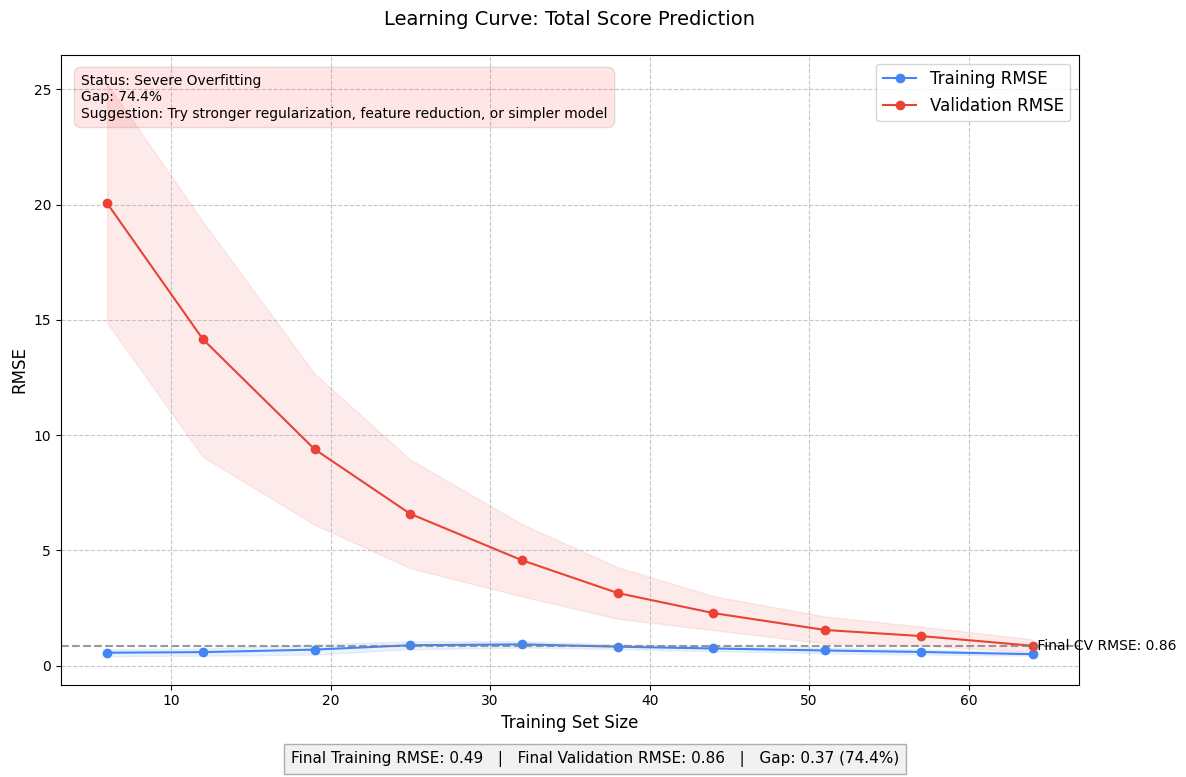

In [83]:
# Cell 15: Enhanced Learning Curve Analysis for Overfitting Diagnostic
from sklearn.model_selection import learning_curve, KFold, validation_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_learning_curve(model, X, y, cv, title="Learning Curve", 
                        scoring='neg_mean_squared_error', 
                        train_sizes=np.linspace(0.1, 1.0, 10),
                        figsize=(12, 8)):
    """
    Plots an enhanced learning curve with standard deviation bands for better overfitting diagnosis.
    
    Args:
        model: Trained model to evaluate
        X: Feature matrix
        y: Target vector
        cv: Cross-validation strategy
        title: Plot title
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        train_sizes: Array of training set sizes to evaluate
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    # Calculate learning curves with cross-validation
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring, 
        train_sizes=train_sizes, n_jobs=-1
    )
    
    # Calculate mean and std for training scores
    train_scores_mean = np.mean(-train_scores, axis=1)
    train_scores_std = np.std(-train_scores, axis=1)
    
    # Calculate mean and std for test scores
    test_scores_mean = np.mean(-test_scores, axis=1)
    test_scores_std = np.std(-test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2  # Adjust std for better visualization
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean training and test scores
    plt.plot(train_sizes, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Calculate overfitting ratio (validation error / training error)
    overfitting_ratio = test_scores_mean / train_scores_mean
    
    # Add annotations
    plt.axhline(y=test_scores_mean[-1], color='gray', linestyle='--', alpha=0.8)
    plt.text(train_sizes[-1], test_scores_mean[-1], f' Final CV {metric_label}: {test_scores_mean[-1]:.2f}', 
             verticalalignment='center')
    
    # Add overfitting assessment
    gap_pct = ((test_scores_mean[-1] - train_scores_mean[-1]) / train_scores_mean[-1]) * 100
    
    if gap_pct > 30:
        overfitting_status = "Severe Overfitting"
        suggestion = "Try stronger regularization, feature reduction, or simpler model"
        status_color = 'red'
    elif gap_pct > 15:
        overfitting_status = "Moderate Overfitting"
        suggestion = "Consider mild regularization or feature selection"
        status_color = 'orange'
    elif gap_pct < 5:
        overfitting_status = "Possible Underfitting"
        suggestion = "Try more complex model or more features"
        status_color = 'blue'
    else:
        overfitting_status = "Good Fit"
        suggestion = "Model complexity seems appropriate"
        status_color = 'green'
    
    plt.annotate(f"Status: {overfitting_status}\nGap: {gap_pct:.1f}%\nSuggestion: {suggestion}",
                xy=(0.02, 0.97), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.5", fc=f"{status_color}", alpha=0.1),
                fontsize=10, ha='left', va='top')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'{title}\n', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    
    # Add score metrics
    train_final = train_scores_mean[-1]
    test_final = test_scores_mean[-1]
    plt.figtext(0.5, 0.01, 
                f"Final Training {metric_label}: {train_final:.2f}   |   "
                f"Final Validation {metric_label}: {test_final:.2f}   |   "
                f"Gap: {test_final-train_final:.2f} ({gap_pct:.1f}%)",
                ha="center", fontsize=11, bbox={"facecolor":"lightgray", "alpha":0.3, "pad":5})
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    
    return {
        'training_final': train_final,
        'validation_final': test_final,
        'gap_percent': gap_pct,
        'status': overfitting_status,
        'suggestion': suggestion
    }

def plot_validation_curve(model, X, y, param_name, param_range, cv=5, 
                          scoring='neg_mean_squared_error', figsize=(12, 6)):
    """
    Plots a validation curve for a specific hyperparameter to find optimal values.
    
    Args:
        model: Model to evaluate
        X: Feature matrix
        y: Target vector
        param_name: Parameter name to vary
        param_range: List of parameter values to try
        cv: Cross-validation strategy
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    train_scores, test_scores = validation_curve(
        model, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    
    # Calculate means and standard deviations
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean accuracy scores for training and testing
    plt.plot(param_range, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(param_range, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Find optimal parameter value
    best_idx = np.argmin(test_scores_mean)
    best_param = param_range[best_idx]
    best_score = test_scores_mean[best_idx]
    
    # Add annotation for best value
    plt.axvline(x=best_param, color='green', linestyle='--', alpha=0.8)
    plt.text(best_param, plt.ylim()[0] * 1.1, f' Best {param_name}={best_param}\n {metric_label}={best_score:.2f}', 
             rotation=90, verticalalignment='bottom')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel(param_name, fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'Validation Curve: {param_name}\n', fontsize=14)
    plt.legend(loc='best', fontsize=12)
    
    # If param_range spans several orders of magnitude, use log scale
    if max(param_range) / min(param_range) > 100:
        plt.xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'best_param': best_param,
        'best_score': best_score
    }

def evaluate_overfitting(model_dict, train_df, target='total_score', pregame_features=None):
    """
    Comprehensive model evaluation to detect and prevent overfitting.
    
    Args:
        model_dict: Dictionary of trained models
        train_df: Training dataframe
        target: Target metric to evaluate
        pregame_features: List of feature columns (if None, will be detected automatically)
    """
    try:
        # Get model from dictionary
        if target not in model_dict:
            print(f"Model for '{target}' not found in model dictionary. Available targets: {list(model_dict.keys())}")
            return
            
        if isinstance(model_dict[target], dict) and 'model' in model_dict[target]:
            model = model_dict[target]['model']
        else:
            model = model_dict[target]
        
        # Auto-detect features if not provided
        if pregame_features is None:
            print("Auto-detecting feature columns...")
            non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                               'home_score', 'away_score', 'point_diff', 'total_score',
                               'home_form', 'away_form', 'id']
            pregame_features = [col for col in train_df.select_dtypes(include=np.number).columns 
                               if col not in non_feature_cols]
            print(f"Detected {len(pregame_features)} feature columns")
        
        # Prepare data
        X_train_lc = train_df[pregame_features]
        y_train_lc = train_df[target]
        
        # Set up cross-validation
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        print(f"Running learning curve analysis for '{target}' prediction...")
        results = plot_learning_curve(model, X_train_lc, y_train_lc, cv=cv, 
                               title=f"Learning Curve: {target.replace('_', ' ').title()} Prediction")
        
        # For GradientBoosting models, analyze key hyperparameters
        if hasattr(model, 'estimators_') and hasattr(model, 'learning_rate'):
            print("\nAnalyzing optimal model complexity...")
            
            # Test different max_depth values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="max_depth",
                param_range=np.array([2, 3, 4, 5, 6, 7]),
                cv=cv
            )
            
            # Test different n_estimators values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="n_estimators",
                param_range=np.array([50, 100, 150, 200, 250, 300]),
                cv=cv
            )
            
            # Test different learning_rate values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="learning_rate",
                param_range=np.array([0.01, 0.05, 0.1, 0.2, 0.3]),
                cv=cv
            )
        
        return results
        
    except Exception as e:
        import traceback
        print(f"Error during overfitting analysis: {str(e)}")
        traceback.print_exc()
        return None

# Example usage (uncomment to run):
# Try to run only if models and train_df variables exist
if 'models' in globals() and 'train_df' in globals():
    print("Evaluating model for overfitting...")
    evaluate_overfitting(models, train_df, target='total_score')
else:
    print("Skipping overfitting analysis - required variables not found in notebook context")
    print("To run analysis, ensure 'models' dictionary and 'train_df' dataframe are available")

In [85]:
# CELL 15A: Scaled Predictions + Feature Checking

import os
import sys
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# --- PART 0: Ensure 'backend' module is in the path ---
# Modify as needed if 'backend' is not exactly one level above the notebooks folder
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(repo_root)

# --- PART 1: Load the Target Scaler (consistent with Cell 11E) ---
scaler_path = os.path.join(repo_root, 'models', 'target_scaler.pkl')
if os.path.exists(scaler_path):
    try:
        target_scaler = joblib.load(scaler_path)
        scaled_prediction = 0.7
        original_prediction = target_scaler.inverse_transform([[scaled_prediction]])[0][0]
        print(f"Scaled prediction: {scaled_prediction} converts to original score: {original_prediction:.2f}")
    except Exception as e:
        print("Error loading scaler:", e)
else:
    print(f"Scaler file not found at: {scaler_path}")

# --- PART 2: Import your custom Feature Generator ---
try:
    from backend.models.features import NBAFeatureGenerator
except ImportError as imp_err:
    print("Could not import NBAFeatureGenerator. Check that 'backend' is a valid module and that the path is correct.")
    raise imp_err

# --- PART 3: Feature Consistency Check ---
# Create a dummy test sample (fill in additional fields as needed)
test_data = pd.DataFrame({
    'home_team': ['Lakers'],
    'away_team': ['Warriors'],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_score': [0],   # Dummy score
    'away_score': [0],
    'current_quarter': [1]
    # Include any additional columns required by your feature generator
})

# Initialize the feature generator
feature_gen = NBAFeatureGenerator(debug=True)

# Generate features
features_df = feature_gen.generate_all_features(test_data)

# Get the expected feature set for quarter 1
expected_features = feature_gen.get_features_for_quarter(features_df, quarter=1).columns.tolist()

print("Expected features for Q1:", expected_features)
print("All generated features columns:", features_df.columns.tolist())

# Optional: add an assertion or check for missing features
missing_features = set(expected_features) - set(features_df.columns.tolist())
if missing_features:
    print("WARNING: The following expected features are missing:", missing_features)
else:
    print("All expected features are present.")

# --- PART 4: Additional Features Dictionary (optional demonstration) ---
# If you want to integrate the additional features dictionary from your code, you can do it here.
# ...


Scaled prediction: 0.7 converts to original score: 241.10
[FeatureGenerator] Generating all features (skip_rest_calc=False)...
[FeatureGenerator] Adding time features...
[FeatureGenerator] Adding team history features...
[FeatureGenerator] Adding rest features...
[FeatureGenerator] Adding score features...
[FeatureGenerator] Adding momentum features...
[FeatureGenerator] Adding interaction features...
[FeatureGenerator] Generated 50 new features
Expected features for Q1: ['rolling_home_score', 'rolling_away_score', 'prev_matchup_diff', 'rest_days_home', 'rest_days_away', 'rest_advantage', 'is_back_to_back_home', 'is_back_to_back_away', 'score_time_impact']
All generated features columns: ['home_team', 'away_team', 'game_date', 'home_score', 'away_score', 'current_quarter', 'time_remaining_mins', 'time_remaining_norm', 'time_exp', 'time_pressure', 'is_q1', 'is_q2', 'is_q3', 'is_q4', 'is_first_half', 'is_second_half', 'is_clutch_time', 'rolling_home_score', 'rolling_away_score', 'prev_ma

Evaluating trained models with real data...
Loaded model for home_score
Loaded model for away_score
Loaded model for point_diff
Loaded model for total_score
Loading historical games from the past 180 days...
Loading historical game data since 2024-09-24...
Loaded 1000 historical games from 2024-10-04 00:00:00 to 2025-03-14 00:00:00
Received 1000 games; sampling down to 100 for faster processing...
Fetched 100 historical games
Calculated advanced metrics for 29 teams.
Skipping game: Missing metrics for Detroit Pistons or Phoenix Suns
Skipping game: Missing metrics for Detroit Pistons or Toronto Raptors
Processing game 100 of 100
Built pre-game features for 98 games with full statistics.
Generated feature set with 114 features
Loaded 98 games with 114 features

Evaluating home_score model

=== EVALUATING MODEL FOR HOME_SCORE ===
Model requires 104 features; 104 available.
Found 104 overlapping features (100.0% overlap)
Using original model with available overlapping features...

Original

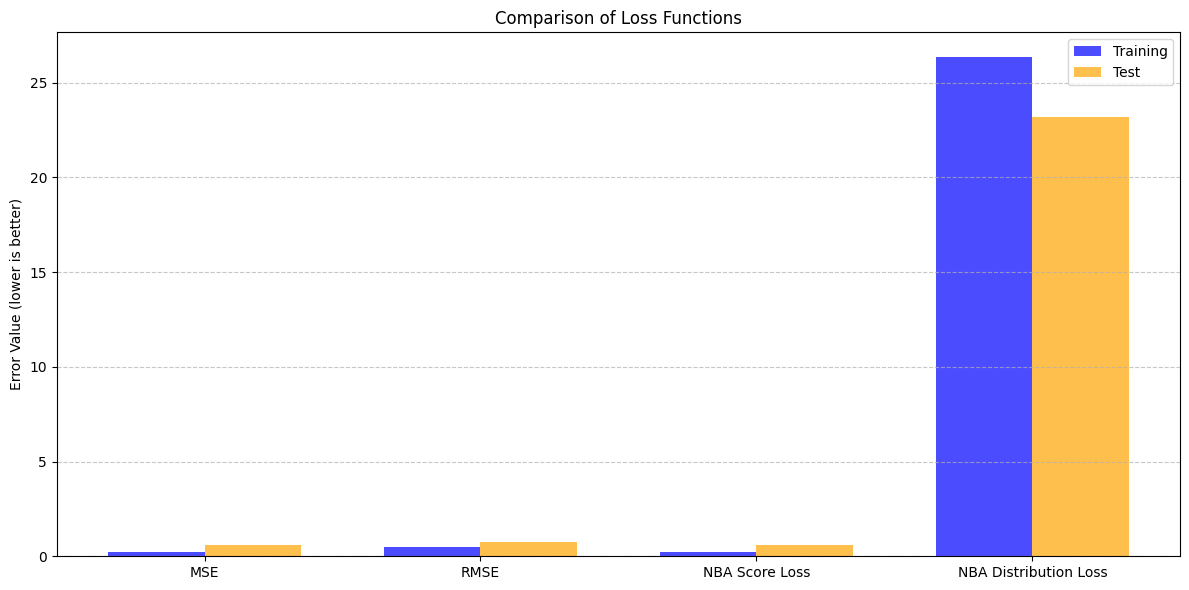

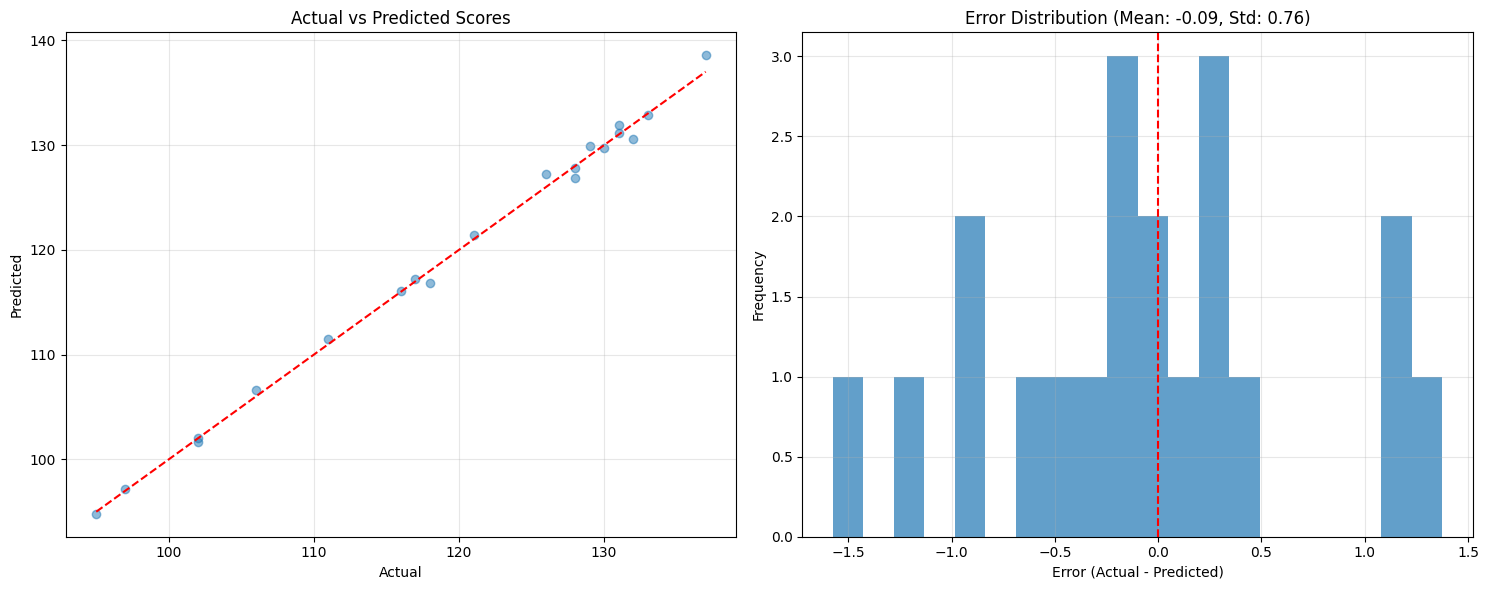

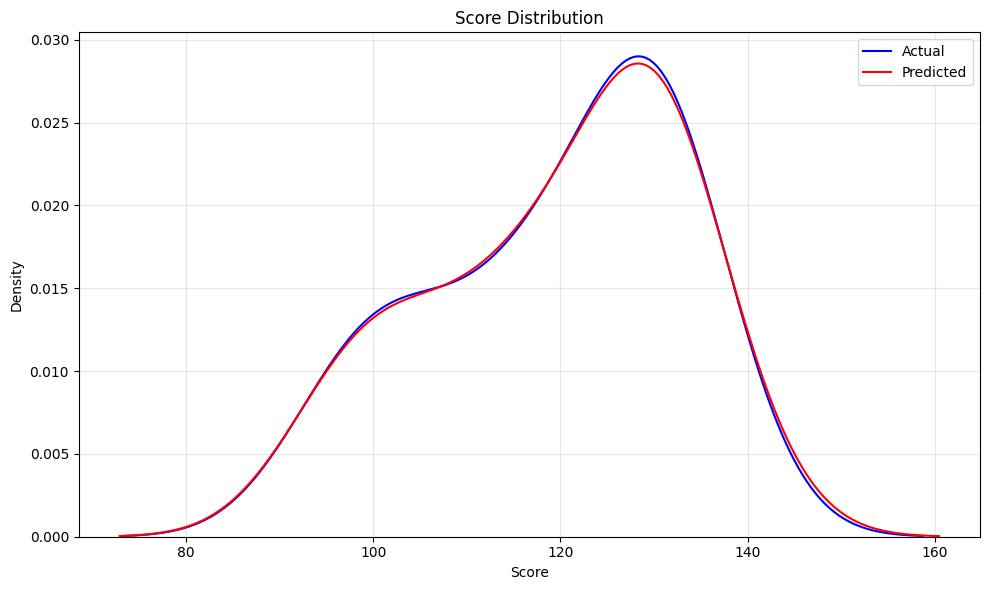


Evaluating away_score model

=== EVALUATING MODEL FOR AWAY_SCORE ===
Model requires 104 features; 104 available.
Found 104 overlapping features (100.0% overlap)
Using original model with available overlapping features...

Original Model Metrics:
Training RMSE: 0.78
Test RMSE: 0.76
Training MAE: 0.39
Test MAE: 0.52
R² Score: 0.9962


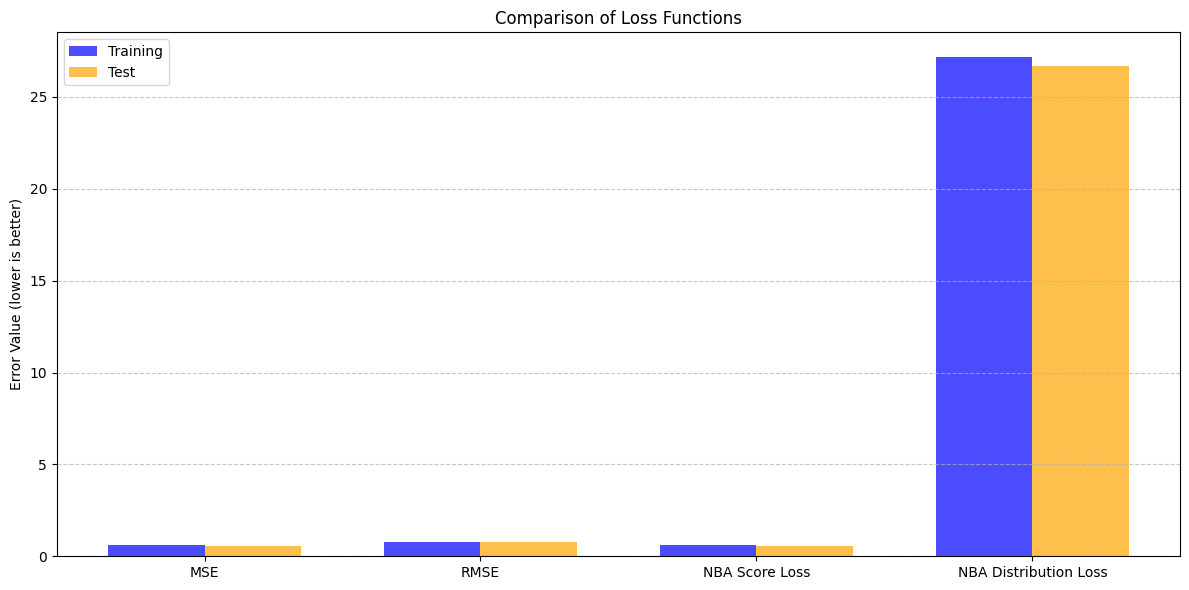

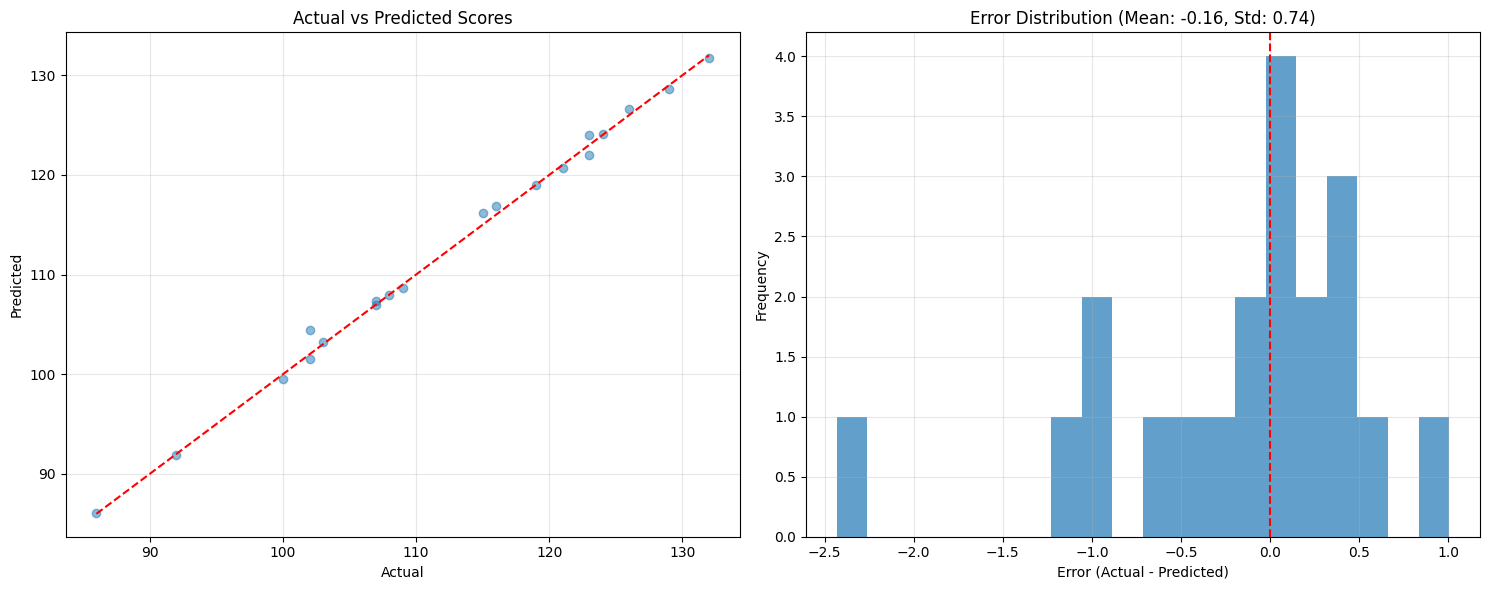

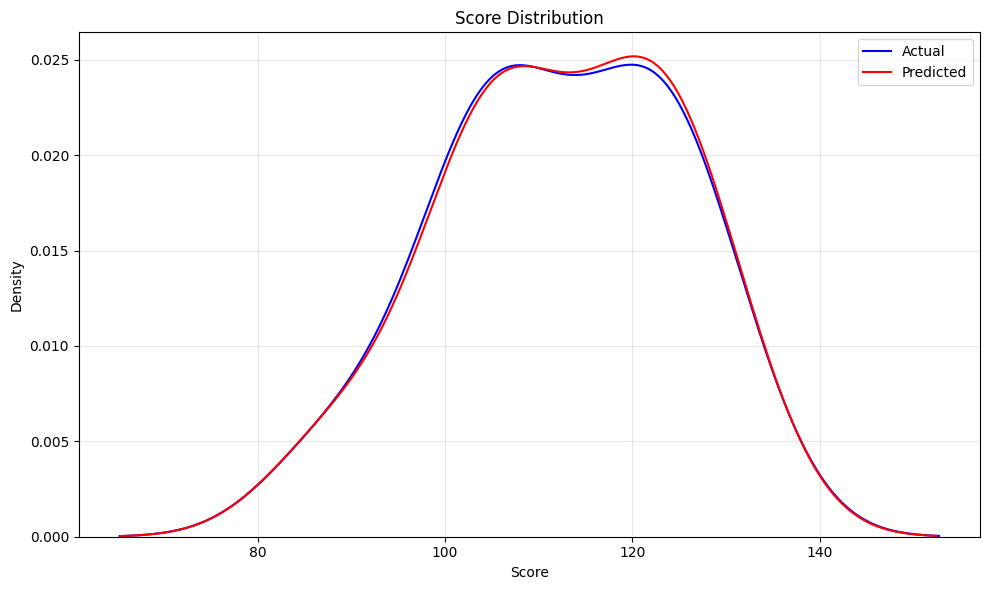


Evaluating point_diff model

=== EVALUATING MODEL FOR POINT_DIFF ===
Model requires 104 features; 104 available.
Found 104 overlapping features (100.0% overlap)
Using original model with available overlapping features...

Original Model Metrics:
Training RMSE: 2.95
Test RMSE: 3.61
Training MAE: 1.89
Test MAE: 2.75
R² Score: 0.9327


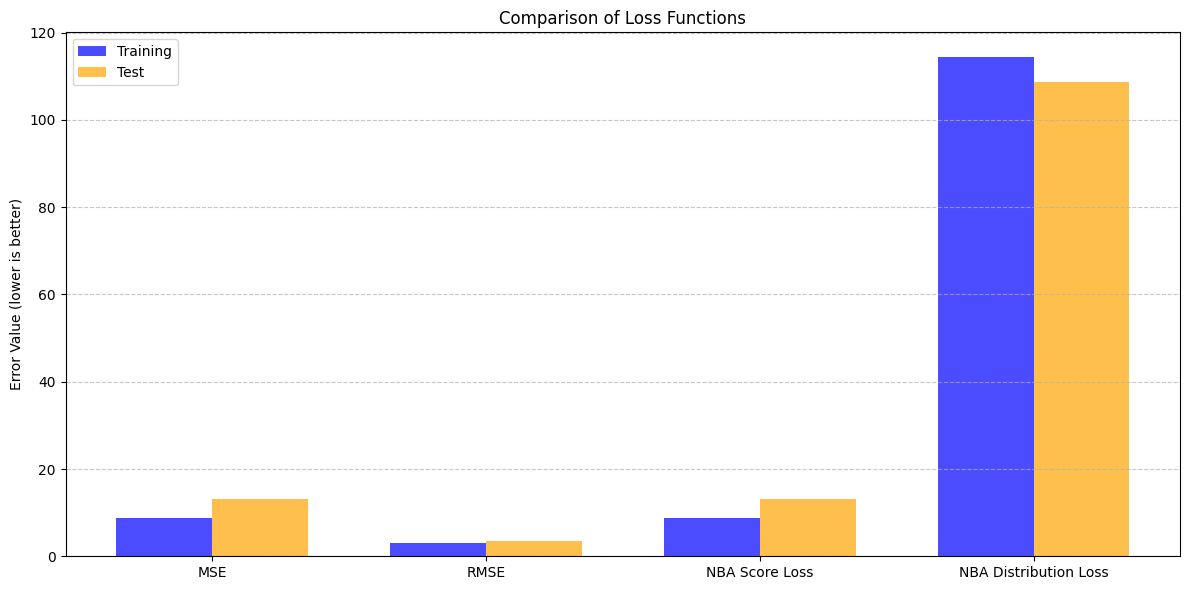

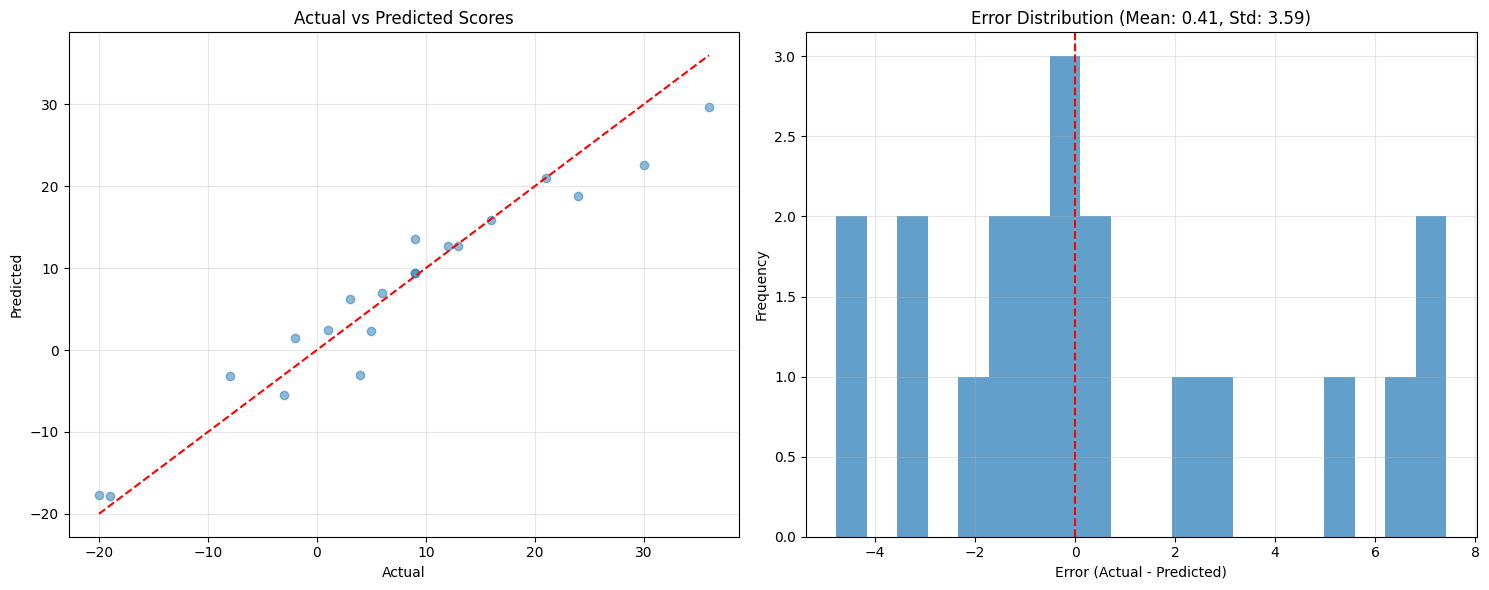

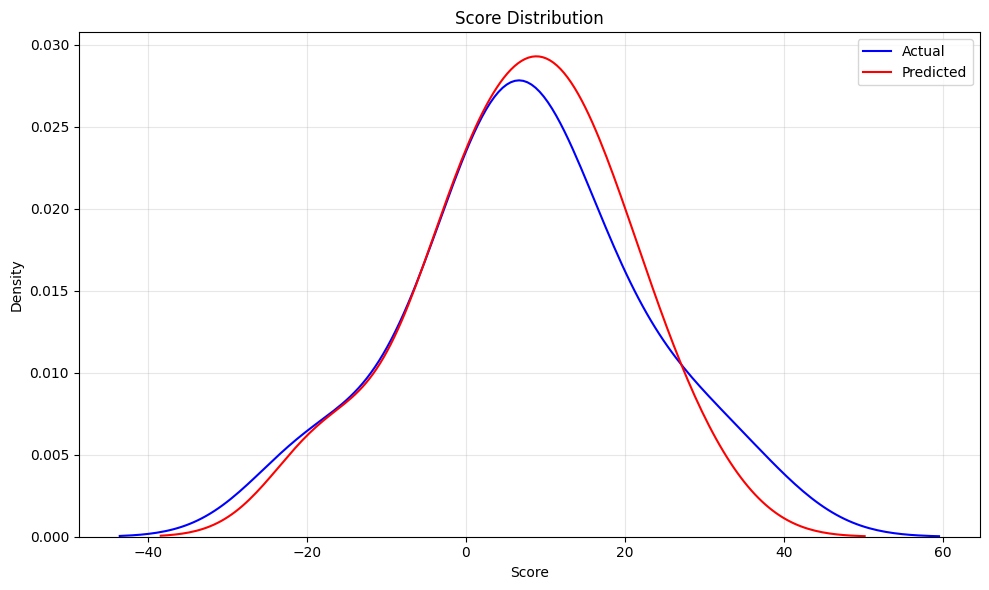


Evaluating total_score model

=== EVALUATING MODEL FOR TOTAL_SCORE ===
Model requires 104 features; 104 available.
Found 104 overlapping features (100.0% overlap)
Using original model with available overlapping features...

Original Model Metrics:
Training RMSE: 2.68
Test RMSE: 2.61
Training MAE: 1.66
Test MAE: 1.96
R² Score: 0.9844


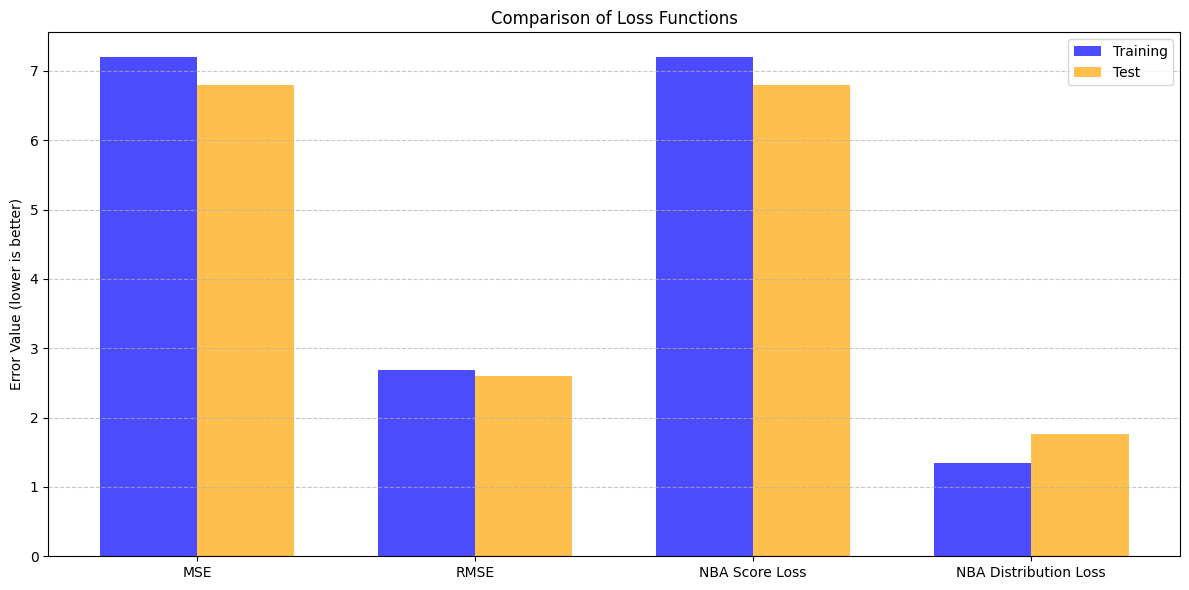

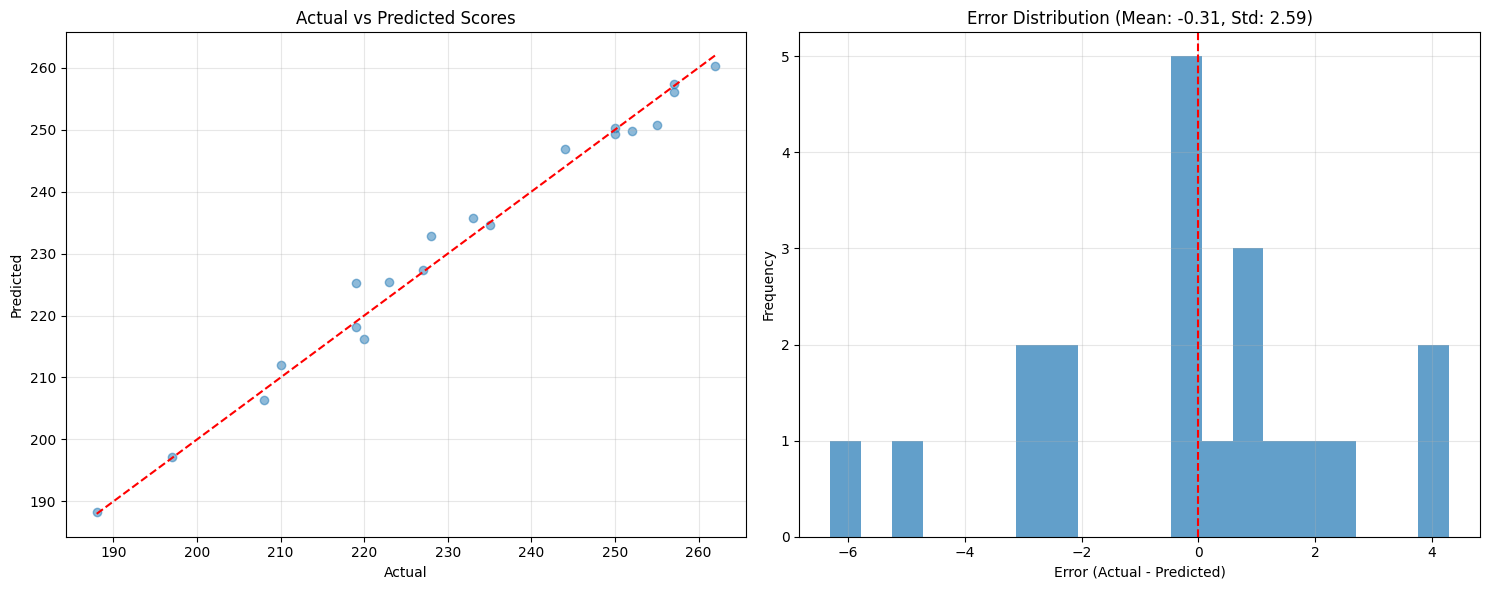

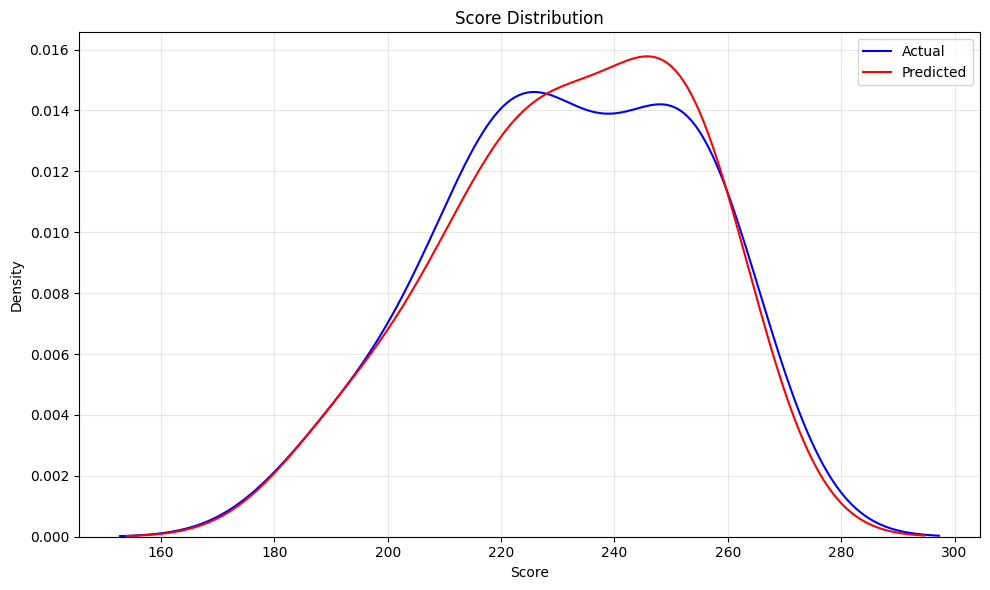

{'home_score': {'train_mse': 0.23398666104530058,
  'test_mse': 0.5815901588892166,
  'train_rmse': 0.48372167725387355,
  'test_rmse': 0.7626205864577854,
  'train_mae': 0.3051010643030173,
  'test_mae': 0.5846383560782755,
  'r2': 0.9964677184397861,
  'train_nba_loss': 0.23398666104530058,
  'test_nba_loss': 0.5815901588892166,
  'train_dist_loss': 26.344103461445492,
  'test_dist_loss': 23.17412223124685},
 'away_score': {'train_mse': 0.6006582560170708,
  'test_mse': 0.5756701037383068,
  'train_rmse': 0.7750214551979002,
  'test_rmse': 0.7587292690665801,
  'train_mae': 0.3899793676380581,
  'test_mae': 0.5221824891052208,
  'r2': 0.9961637338148853,
  'train_nba_loss': 0.6006582560170708,
  'test_nba_loss': 0.5756701037383068,
  'train_dist_loss': 27.157080328273686,
  'test_dist_loss': 26.709026119716754},
 'point_diff': {'train_mse': 8.712716594627743,
  'test_mse': 13.063626258437328,
  'train_rmse': 2.9517311182808883,
  'test_rmse': 3.614363880192105,
  'train_mae': 1.89236

In [86]:
# Cell 15B -- Run Model Evaluations

# Run evaluations
run_model_evaluations()

NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION (Cell 16)
Loaded pregame model from pregame_model.pkl
Model type: <class 'dict'>
Model keys: ['home_score', 'away_score', 'point_diff', 'total_score']
Loaded 1045 rows from nba_historical_game_stats, from 2024-10-04 to 2025-03-19
Loaded 1045 rows from nba_historical_game_stats, from 2024-10-04 to 2025-03-19
Loaded historical data with shape (1045, 46)
Calculated advanced metrics for 31 teams.
Teams in metrics: ['assists_avg', 'ast_to_ratio', 'avg_opp_score', 'avg_score', 'blocks_avg', 'current_form', 'current_streak', 'defense_impact', 'defensive_rating', 'form_win_pct', 'fouls_avg', 'games_played', 'home_advantage', 'momentum_direction', 'net_rating', 'off_reb_avg', 'off_reb_pct', 'offensive_rating', 'opp_pts_per_game', 'pts_per_game', 'q1_avg', 'q1_q4_ratio', 'q4_avg', 'recent_form', 'steals_avg', 'team', 'team_normalized', 'three_att_avg', 'three_made_avg', 'three_pt_pct', 'total_reb_avg', 'turnovers_avg', 'win_pct']
Teams availab

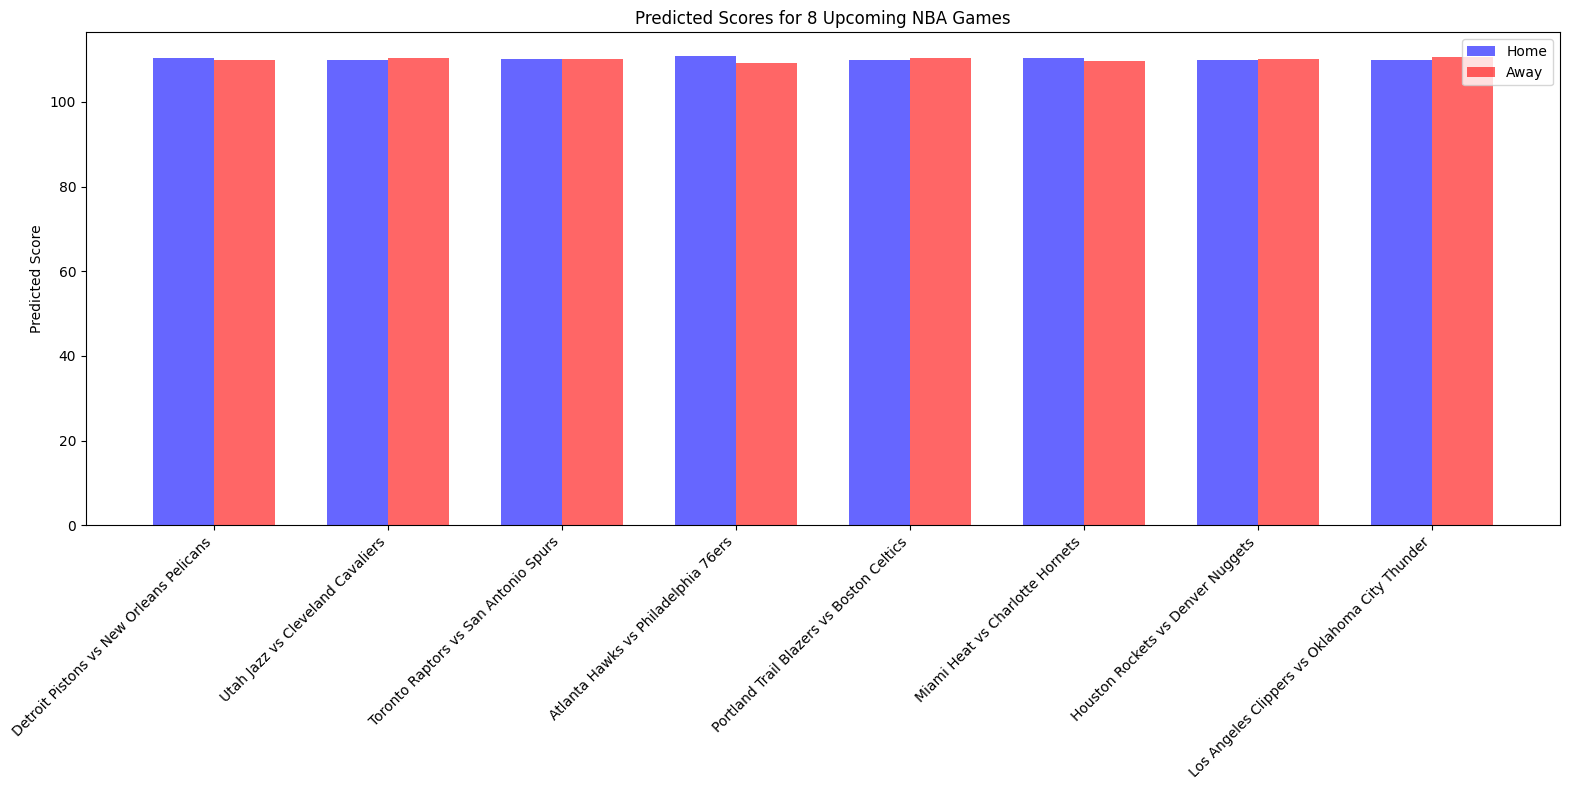

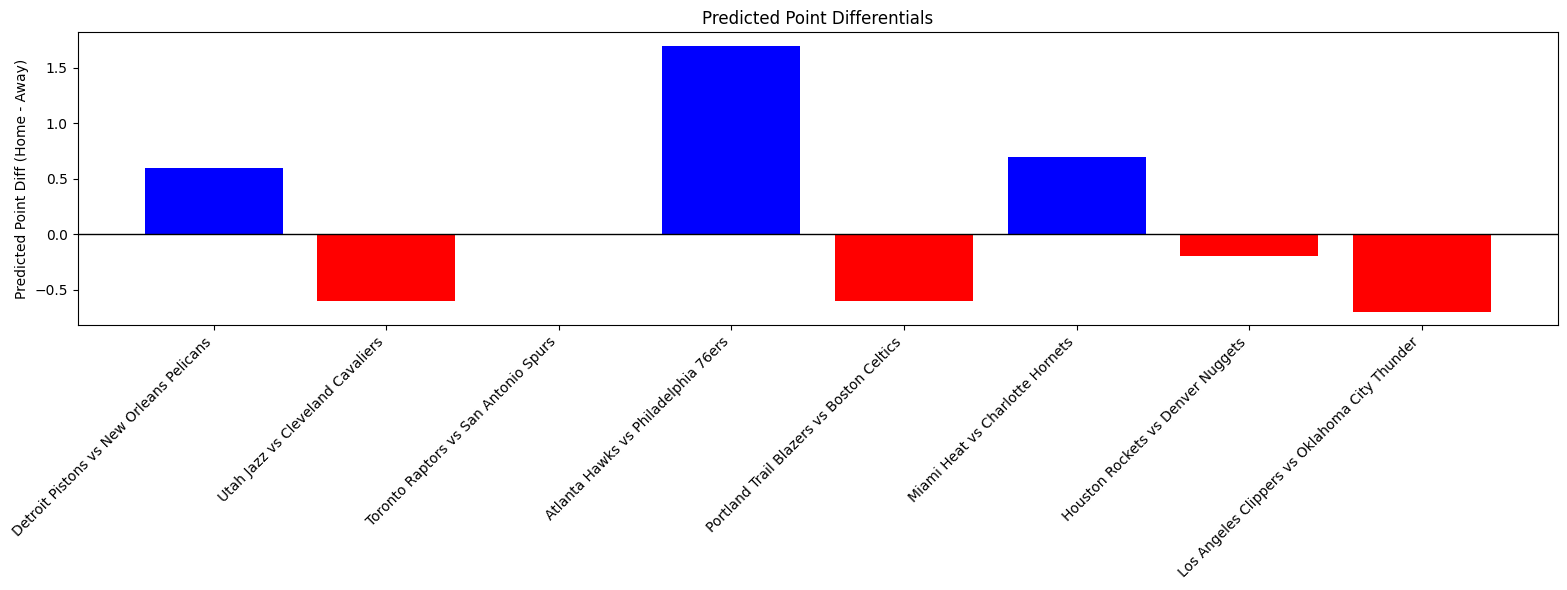


=== FEATURE IMPORTANCE ===

Feature importance for home_score model:
                      Feature  Importance
30            home_first_half    0.520614
31           home_second_half    0.459596
90  home_offensive_efficiency    0.005906
34               home_assists    0.001791
60          home_ast_to_ratio    0.001206
50                   home_3pm    0.001141
64      home_off_to_def_ratio    0.001061
43                 away_fouls    0.000883
24             home_q3_points    0.000631
22             home_q1_points    0.000572


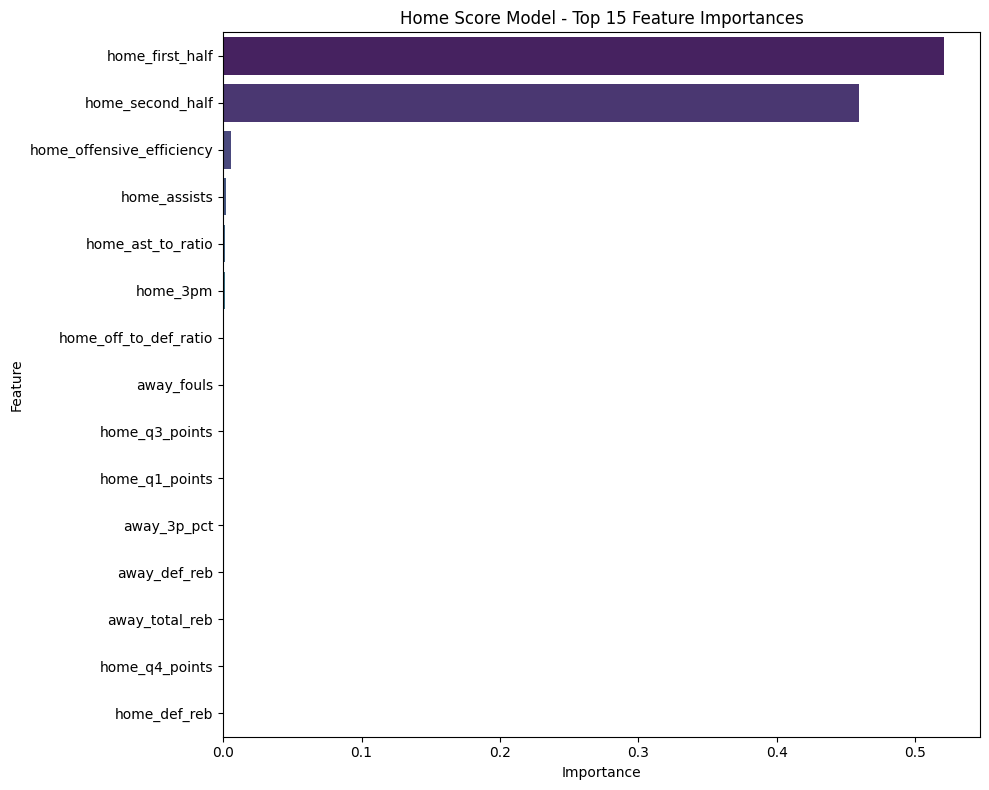


Feature importance for away_score model:
                      Feature  Importance
33           away_second_half    0.529264
32            away_first_half    0.454064
55                away_3p_pct    0.002432
36                home_steals    0.001909
35               away_assists    0.001890
26             away_q1_points    0.001403
91  away_offensive_efficiency    0.001361
27             away_q2_points    0.001165
31           home_second_half    0.000841
7             away_net_rating    0.000449


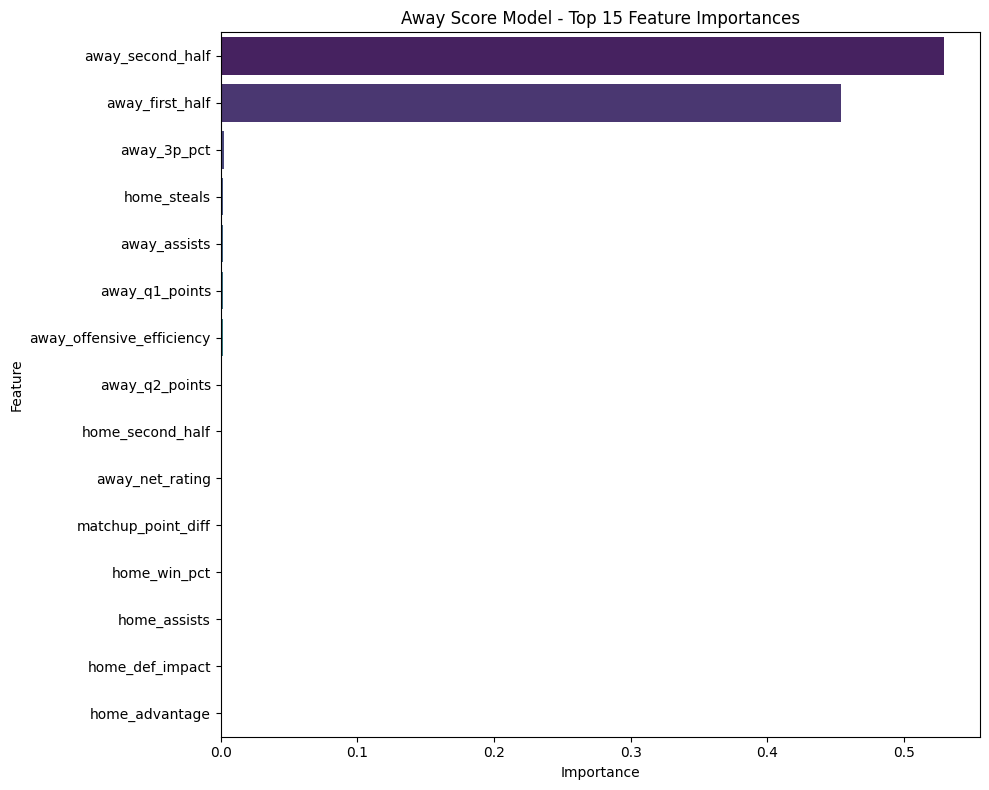


Feature importance for point_diff model:
                Feature  Importance
30      home_first_half    0.141239
31     home_second_half    0.114906
33     away_second_half    0.109847
32      away_first_half    0.089529
58  home_rebounding_pct    0.084720
55          away_3p_pct    0.067177
59  away_rebounding_pct    0.066965
54          home_3p_pct    0.041763
8       net_rating_diff    0.041511
60    home_ast_to_ratio    0.031335


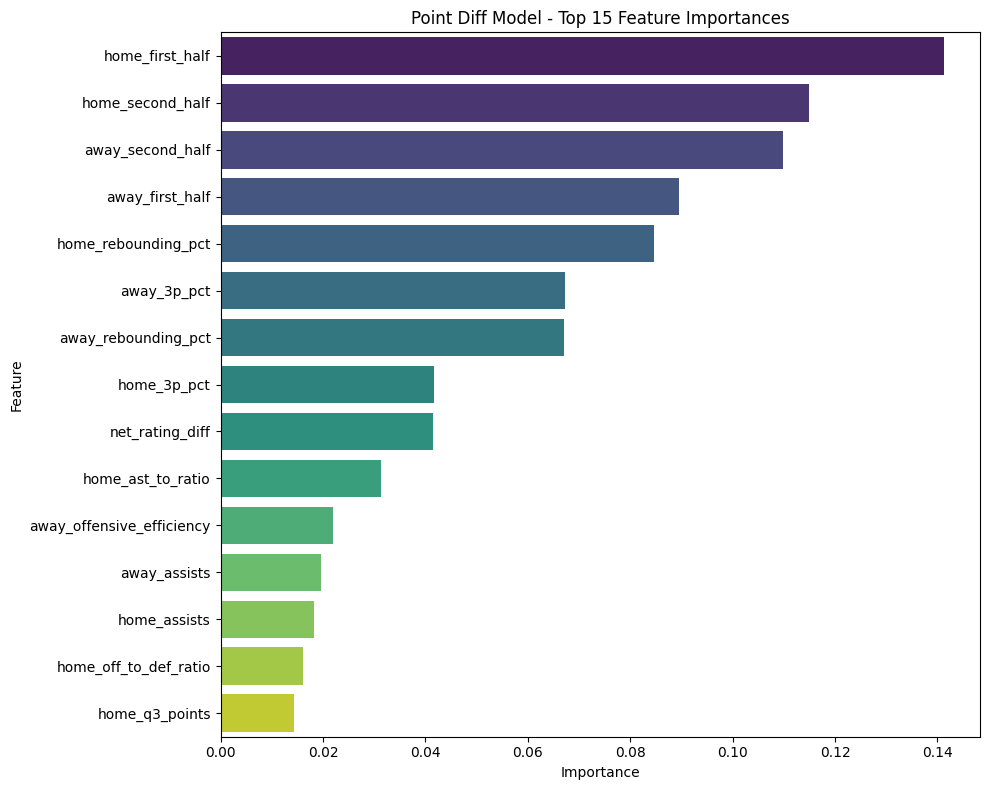


Feature importance for total_score model:
                      Feature  Importance
31           home_second_half    0.273259
33           away_second_half    0.216809
30            home_first_half    0.216732
32            away_first_half    0.190390
34               home_assists    0.020117
35               away_assists    0.012053
91  away_offensive_efficiency    0.010802
90  home_offensive_efficiency    0.006151
64      home_off_to_def_ratio    0.005900
27             away_q2_points    0.005450


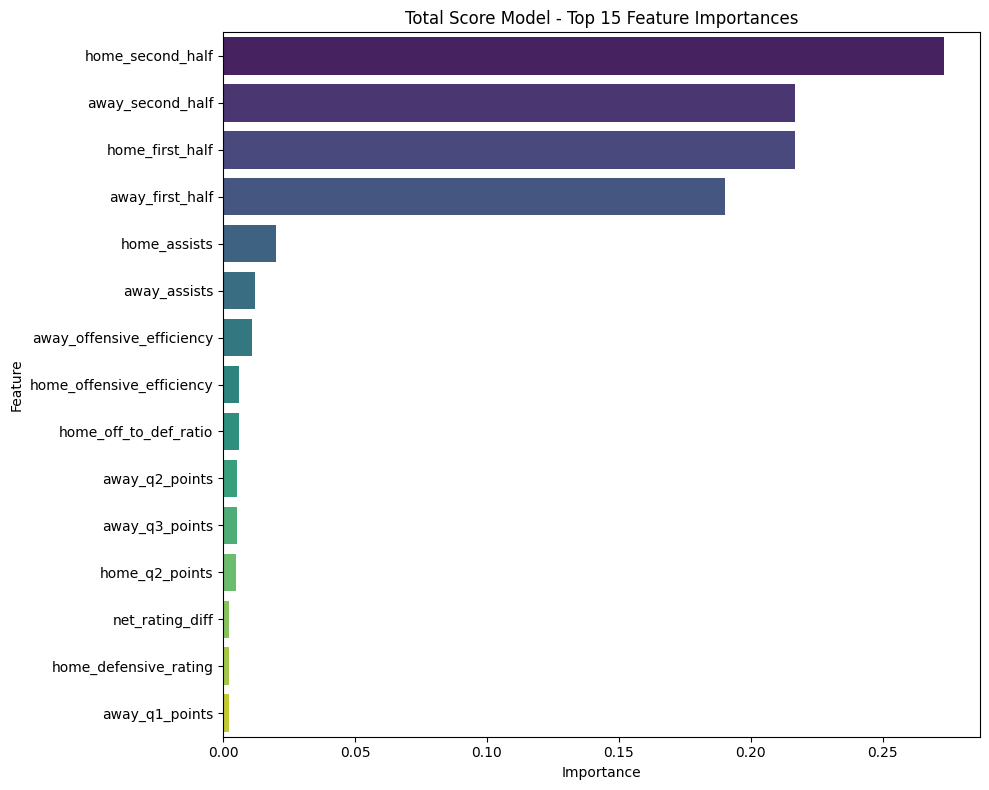


=== BETTING DASHBOARD ===

Detroit Pistons vs New Orleans Pelicans (ID=414902)
  Predicted Score: 110.3-109.8 (Win Prob: 53.6%)
  Market Spread: +0.0 (Edge: +0.6)
  Market Total: 220.0 (Edge: +0.1)

Utah Jazz vs Cleveland Cavaliers (ID=414903)
  Predicted Score: 109.8-110.4 (Win Prob: 46.1%)
  Market Spread: +0.0 (Edge: -0.6)
  Market Total: 220.0 (Edge: +0.2)

Toronto Raptors vs San Antonio Spurs (ID=414904)
  Predicted Score: 110.1-110.1 (Win Prob: 49.8%)
  Market Spread: +0.0 (Edge: -0.0)
  Market Total: 220.0 (Edge: +0.2)

Atlanta Hawks vs Philadelphia 76ers (ID=414905)
  Predicted Score: 110.9-109.3 (Win Prob: 60.3%)
  Market Spread: +0.0 (Edge: +1.7)
  Market Total: 220.0 (Edge: +0.2)

Portland Trail Blazers vs Boston Celtics (ID=414906)
  Predicted Score: 109.8-110.4 (Win Prob: 46.1%)
  Market Spread: +0.0 (Edge: -0.6)
  Market Total: 220.0 (Edge: +0.2)

Miami Heat vs Charlotte Hornets (ID=414907)
  Predicted Score: 110.4-109.6 (Win Prob: 54.6%)
  Market Spread: +0.0 (Edge: +0.

In [87]:
# Cell 16

import pandas as pd
import numpy as np
import traceback
import re
import math
import pytz
import joblib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from datetime import datetime, timedelta
from pathlib import Path
import seaborn as sns


# Assumes supabase, engine, and MODELS_DIR are defined in your environment.
# For example:
#   MODELS_DIR = Path("./models")

###############################################################################
# HELPER FUNCTIONS (same as before, with minor adjustments)
###############################################################################

def load_historical_games_16(start_date=None):
    if start_date is None:
        start_date = datetime.now() - timedelta(days=180)
    query = f"""
        SELECT * FROM public.nba_historical_game_stats
        WHERE game_date >= '{start_date.strftime('%Y-%m-%d')}'
        ORDER BY game_date ASC;
    """
    try:
        df = pd.read_sql(query, engine)
        if df.empty:
            print("Loaded 0 rows from nba_historical_game_stats.")
        else:
            print(f"Loaded {len(df)} rows from nba_historical_game_stats, from {df['game_date'].min()} to {df['game_date'].max()}")
        return df
    except Exception as e:
        print(f"Error loading historical games: {e}")
        return pd.DataFrame()

def calculate_team_metrics_16(historical_df):
    if historical_df.empty:
        print("No historical data provided to calculate_team_metrics_16.")
        return pd.DataFrame(columns=['team','win_pct','pts_per_game','opp_pts_per_game','net_rating','off_reb_avg','total_reb_avg','fg_pct','ft_pct','three_pt_pct'])
    
    all_teams = set(historical_df['home_team'].unique()).union(historical_df['away_team'].unique())
    rows = []
    for team in all_teams:
        home_games = historical_df[historical_df['home_team'] == team]
        away_games = historical_df[historical_df['away_team'] == team]
        total_games = len(home_games) + len(away_games)
        if total_games < 1:
            continue
        home_wins = (home_games['home_score'] > home_games['away_score']).sum()
        away_wins = (away_games['away_score'] > away_games['home_score']).sum()
        wins = home_wins + away_wins
        home_pts = home_games['home_score'].mean() if not home_games.empty else 0
        away_pts = away_games['away_score'].mean() if not away_games.empty else 0
        pts_per_game = (home_pts*len(home_games) + away_pts*len(away_games)) / total_games
        home_opp = home_games['away_score'].mean() if not home_games.empty else 0
        away_opp = away_games['home_score'].mean() if not away_games.empty else 0
        opp_pts_per_game = (home_opp*len(home_games) + away_opp*len(away_games)) / total_games
        home_off_reb = home_games['home_off_reb'].mean() if 'home_off_reb' in home_games.columns and not home_games.empty else 10.5
        away_off_reb = away_games['away_off_reb'].mean() if 'away_off_reb' in away_games.columns and not away_games.empty else 10.5
        off_reb_avg = (home_off_reb*len(home_games) + away_off_reb*len(away_games)) / total_games
        home_total_reb = home_games['home_total_reb'].mean() if 'home_total_reb' in home_games.columns and not home_games.empty else 43.0
        away_total_reb = away_games['away_total_reb'].mean() if 'away_total_reb' in away_games.columns and not away_games.empty else 43.0
        total_reb_avg = (home_total_reb*len(home_games) + away_total_reb*len(away_games)) / total_games
        fg_pct = 0.45
        if 'home_fg_made' in historical_df.columns and 'home_fg_attempted' in historical_df.columns:
            all_fg_made = pd.concat([home_games['home_fg_made'], away_games['away_fg_made']])
            all_fg_att = pd.concat([home_games['home_fg_attempted'], away_games['away_fg_attempted']])
            if all_fg_att.sum() > 0:
                fg_pct = all_fg_made.sum() / all_fg_att.sum()
        ft_pct = 0.75
        if 'home_ft_made' in historical_df.columns and 'home_ft_attempted' in historical_df.columns:
            all_ft_made = pd.concat([home_games['home_ft_made'], away_games['away_ft_made']])
            all_ft_att = pd.concat([home_games['home_ft_attempted'], away_games['away_ft_attempted']])
            if all_ft_att.sum() > 0:
                ft_pct = all_ft_made.sum() / all_ft_att.sum()
        three_pt_pct = 0.35
        if 'home_3pm' in historical_df.columns and 'home_3pa' in historical_df.columns:
            all_3pm = pd.concat([home_games['home_3pm'], away_games['away_3pm']])
            all_3pa = pd.concat([home_games['home_3pa'], away_games['away_3pa']])
            if all_3pa.sum() > 0:
                three_pt_pct = all_3pm.sum() / all_3pa.sum()
        win_pct = wins / total_games if total_games > 0 else 0.5
        net_rating = pts_per_game - opp_pts_per_game
        row = {
            'team': team,
            'win_pct': win_pct,
            'pts_per_game': pts_per_game,
            'opp_pts_per_game': opp_pts_per_game,
            'net_rating': net_rating,
            'off_reb_avg': off_reb_avg,
            'total_reb_avg': total_reb_avg,
            'fg_pct': fg_pct,
            'ft_pct': ft_pct,
            'three_pt_pct': three_pt_pct
        }
        rows.append(row)
    print("Teams in metrics:", sorted(all_teams))
    df_metrics = pd.DataFrame(rows)
    if df_metrics.empty:
        print("Warning: calculate_team_metrics_16 produced an empty DataFrame.")
    return df_metrics

def fetch_upcoming_games_16(days_window=2):  # Increased to 2 days to ensure we get all games
    pacific_tz = pytz.timezone("America/Los_Angeles")
    now_pt = datetime.now(pacific_tz)
    start_date = (now_pt - timedelta(days=1)).date()
    end_date = (now_pt + timedelta(days=days_window)).date()
    cutoff_hour = 21
    start_ts = pacific_tz.localize(datetime.combine(start_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
    end_ts = pacific_tz.localize(datetime.combine(end_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
    print(f"Fetching upcoming games from {start_date} to {end_date} (9pm PT window)...")
    try:
        response = supabase.table("nba_game_schedule").select("*")\
            .gte("scheduled_time", start_ts).lt("scheduled_time", end_ts).execute()
        data = response.data
        if not data:
            print("No upcoming games found in nba_game_schedule for that period.")
            return pd.DataFrame()
        games_df = pd.DataFrame(data)
        if "scheduled_time" in games_df.columns:
            games_df["scheduled_time"] = pd.to_datetime(games_df["scheduled_time"])
            games_df["game_time_pt"] = games_df["scheduled_time"].dt.tz_convert(pacific_tz)
            games_df["game_date"] = games_df["game_time_pt"].dt.date
        if "spread_clean" in games_df.columns:
            try:
                games_df["home_spread"] = games_df["spread_clean"].str.extract(r'([+\-]?\d+\.?\d*)\s*\(').astype(float)
            except Exception as e:
                print(f"Error parsing home spread: {e}")
        if "total_clean" in games_df.columns:
            try:
                games_df["over_under_line"] = games_df["total_clean"].str.extract(r'Over\s+(\d+\.?\d*)').astype(float)
            except Exception as e:
                print(f"Error parsing over/under: {e}")
        print(f"Found {len(games_df)} upcoming games in nba_game_schedule.")
        
        # Print upcoming matchups for debugging
        print("\nUPCOMING MATCHUPS:")
        for _, row in games_df.iterrows():
            print(f"  - {row['home_team']} vs {row['away_team']} (ID: {row['game_id']})")
            
        return games_df
    except Exception as e:
        print(f"Error fetching upcoming games from supabase: {e}")
        return pd.DataFrame()
    
def fix_upcoming_games_duplicates(upcoming_df):
    """Fix any duplicate game issues and ensure all games are processed"""
    # First, create a cleaner dataframe with unique game_ids
    if 'game_id' not in upcoming_df.columns:
        print("WARNING: No game_id column found in upcoming games data")
        return upcoming_df
        
    # Check for and remove duplicate game_ids
    if upcoming_df.duplicated('game_id').any():
        print(f"Found {upcoming_df.duplicated('game_id').sum()} duplicate game_ids - removing duplicates")
        upcoming_df = upcoming_df.drop_duplicates('game_id')
    
    # Print all games to verify
    print("\nALL GAMES TO BE PROCESSED:")
    for i, (_, row) in enumerate(upcoming_df.iterrows(), 1):
        print(f"{i}. {row['home_team']} vs {row['away_team']} (ID: {row['game_id']})")
        
    return upcoming_df


def parse_moneyline_16(moneyline_str):
    if not moneyline_str or moneyline_str=='EMPTY':
        return {'home': -110, 'away': -110}
    pattern = r'([^\/]+)([\+\-]\d+)[^\/]+\/[^\/]+([\+\-]\d+)'
    match = re.search(pattern, moneyline_str)
    if match:
        home_line = int(match.group(3))
        away_line = int(match.group(2))
        return {'home': home_line, 'away': away_line}
    return {'home': -110, 'away': -110}

def parse_spread_16(spread_str):
    if not spread_str or spread_str=='EMPTY':
        return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}
    pattern = r'([^\/]+)([\+\-]\d+\.?\d*)\s*\(([\+\-]\d+)\).*\/.*([\+\-]\d+\.?\d*)\s*\(([\+\-]\d+)\)'
    match = re.search(pattern, spread_str)
    if match:
        home_spread = float(match.group(2))
        home_odds = int(match.group(3))
        away_spread = float(match.group(4))
        away_odds = int(match.group(5))
        return {'home': home_spread, 'away': away_spread, 'home_odds': home_odds, 'away_odds': away_odds}
    return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}

def parse_total_16(total_str):
    if not total_str or total_str=='EMPTY':
        return {'line': 220, 'over_odds': -110, 'under_odds': -110}
    pattern = r'Over\s+([\d\.]+)\s*\(([\+\-]\d+)\).*\/.*Under\s+([\d\.]+)\s*\(([\+\-]\d+)\)'
    match = re.search(pattern, total_str)
    if match:
        line = float(match.group(1))
        over_odds = int(match.group(2))
        under_odds = int(match.group(4))
        return {'line': line, 'over_odds': over_odds, 'under_odds': under_odds}
    return {'line': 220, 'over_odds': -110, 'under_odds': -110}

def fetch_betting_odds_16(game_ids):
    if not game_ids:
        return {}
    try:
        response = supabase.table("nba_game_schedule").select("*")\
            .gte("game_date", datetime.now().strftime('%Y-%m-%d')).execute()
        data = response.data
        if not data:
            print("No data from supabase for future games.")
            return {}
        big_df = pd.DataFrame(data)
        odds_dict = {}
        for _, row in big_df.iterrows():
            gid = str(row.get('game_id', ''))
            if gid in game_ids:
                moneyline_parsed = parse_moneyline_16(row.get('moneyline_clean', ''))
                spread_parsed = parse_spread_16(row.get('spread_clean', ''))
                total_parsed = parse_total_16(row.get('total_clean', ''))
                odds_dict[gid] = {
                    'moneyline': moneyline_parsed,
                    'spread': spread_parsed,
                    'total': total_parsed
                }
        print(f"Processed betting odds for {len(odds_dict)} relevant games.")
        return odds_dict
    except Exception as e:
        print(f"Error in fetch_betting_odds_16: {e}")
        return {}

def calibrate_prediction_with_odds_16(prediction, odds):
    calibrated = dict(prediction)
    if not odds or 'spread' not in odds or 'total' not in odds:
        return calibrated
    
    home_score = calibrated['predicted_home_score']
    away_score = calibrated['predicted_away_score']
    
    # Force minimum reasonable NBA scores
    if home_score < 90:
        home_score = max(home_score * 1.3, 95.0)
    if away_score < 90:
        away_score = max(away_score * 1.3, 90.0)
    
    predicted_diff = home_score - away_score
    predicted_total = home_score + away_score
    market_spread = -odds['spread'].get('home', 0.0)
    market_total = odds['total'].get('line', 220.0)
    
    if predicted_total < 180 or predicted_total > 260:
        # Unrealistic total - heavily adjust toward market total
        ratio = market_total / max(predicted_total, 1)
        home_pct = home_score / max(predicted_total, 1)
        away_pct = away_score / max(predicted_total, 1)
        home_adj = market_total * home_pct
        away_adj = market_total * away_pct
        if predicted_diff > 0 and home_adj < away_adj:
            avg = (home_adj + away_adj) / 2
            half_diff = abs(predicted_diff) / 2
            home_adj = avg + half_diff
            away_adj = avg - half_diff
        elif predicted_diff < 0 and home_adj > away_adj:
            avg = (home_adj + away_adj) / 2
            half_diff = abs(predicted_diff) / 2
            home_adj = avg - half_diff
            away_adj = avg + half_diff
        home_score = home_adj
        away_score = away_adj
    else:
        # Reasonable total - blend with market consensus
        blend = 0.7  # Increased reliance on market
        new_total = blend * market_total + (1 - blend) * predicted_total
        new_diff = blend * market_spread + (1 - blend) * predicted_diff
        home_score = (new_total + new_diff) / 2
        away_score = (new_total - new_diff) / 2
    
    calibrated['predicted_home_score'] = round(home_score, 1)
    calibrated['predicted_away_score'] = round(away_score, 1)
    calibrated['predicted_point_diff'] = round(home_score - away_score, 1)
    calibrated['predicted_total_score'] = round(home_score + away_score, 1)
    
    # Calculate win probability based on calibrated score
    k = 0.25
    win_prob = 1 / (1 + math.exp(-k * (home_score - away_score)))
    calibrated['win_probability'] = round(win_prob, 3)
    
    return calibrated

def normalize_nba_scores(preds, home_metrics, away_metrics):
    """
    Normalize unrealistically low score predictions to realistic NBA score ranges
    """
    home_score = preds.get('home_score', 0)
    away_score = preds.get('away_score', 0)
    point_diff = preds.get('point_diff', 0)
    total_score = preds.get('total_score', 0)
    
    # If scores are already reasonable, just return
    if home_score >= 90 and away_score >= 90:
        return preds
        
    # Get expected scoring rates from team metrics if available
    expected_home_score = home_metrics.get('pts_per_game', 110.0) if home_metrics is not None else 110.0
    expected_away_score = away_metrics.get('pts_per_game', 105.0) if away_metrics is not None else 105.0
    
    # Keep the predicted point differential intact, but scale up the scores
    predicted_diff = home_score - away_score
    
    # Calculate a reasonable total based on team averages
    reasonable_total = expected_home_score + expected_away_score
    
    # Apply the predicted differential to the reasonable total
    new_home_score = (reasonable_total + predicted_diff) / 2
    new_away_score = (reasonable_total - predicted_diff) / 2
    
    # Ensure no negative scores
    new_home_score = max(new_home_score, 85.0)
    new_away_score = max(new_away_score, 85.0)
    
    # Update predictions
    preds['home_score'] = new_home_score
    preds['away_score'] = new_away_score
    
    # If we have total_score prediction, honor it (if it's reasonable)
    if total_score > 180 and total_score < 250:
        ratio = total_score / (new_home_score + new_away_score)
        preds['home_score'] *= ratio
        preds['away_score'] *= ratio
    
    return preds

def build_enhanced_feature_row(home_team, away_team, team_metrics_df, row):
    """
    Build a rich feature set for predictions with extensive 
    team name matching and feature population
    """
    # Initialize with default values for all potential features
    feature_row = {
        'home_pts_per_game': 110.0,
        'away_pts_per_game': 108.0,
        'home_rest_days': row.get('home_rest_days', 2.0),
        'away_rest_days': row.get('away_rest_days', 2.0),
        'home_win_pct': 0.5,
        'away_win_pct': 0.5,
        'home_offensive_rating': 110.0,
        'away_offensive_rating': 108.0,
        'home_defensive_rating': 110.0,
        'away_defensive_rating': 110.0,
        'home_net_rating': 0.0,
        'away_net_rating': 0.0,
        'net_rating_diff': 0.0,
        'home_rolling_score': 110.0,
        'away_rolling_score': 108.0,
        'home_rolling_opp_score': 108.0,
        'away_rolling_opp_score': 110.0,
        'rest_advantage': 0.0,
        'home_back_to_back': 0.0,
        'away_back_to_back': 0.0,
        'matchup_games': 2.0,
        'matchup_point_diff': 0.0,
        'home_historical_win_pct': 0.5,
        'home_advantage': 3.0,
        'home_rebounding_pct': 0.5,
        'away_rebounding_pct': 0.5
    }
    
    # Team name normalization function
    def normalize_team_name(name):
        replacements = {
            'LA Clippers': 'Los Angeles Clippers',
            'LA Lakers': 'Los Angeles Lakers',
            'Philadelphia 76Ers': 'Philadelphia 76ers',
            'Sixers': 'Philadelphia 76ers',
            'Blazers': 'Portland Trail Blazers',
            'Cavs': 'Cleveland Cavaliers',
            'Mavs': 'Dallas Mavericks',
            'Knicks': 'New York Knicks'
        }
        return replacements.get(name, name)
    
    # Try to find team with normalized names
    home_normalized = normalize_team_name(home_team)
    away_normalized = normalize_team_name(away_team)

    # Print detailed team matching info for debugging
    print(f"Home team: {home_team} (normalized: {home_normalized})")
    print(f"Away team: {away_team} (normalized: {away_normalized})")
    
    # Get metrics for home team if available
    home_metrics_dict = None
    away_metrics_dict = None
    
    if not team_metrics_df.empty:
        # Try with original name first
        home_metrics = team_metrics_df[team_metrics_df['team'] == home_team]
        # If not found, try with normalized name
        if home_metrics.empty:
            home_metrics = team_metrics_df[team_metrics_df['team'] == home_normalized]
            if home_metrics.empty:
                print(f"WARNING: No metrics found for home team {home_team} or {home_normalized}!")
                # Try case-insensitive search as last resort
                for idx, metric_row in team_metrics_df.iterrows():
                    if metric_row['team'].lower() == home_team.lower() or metric_row['team'].lower() == home_normalized.lower():
                        home_metrics = pd.DataFrame([metric_row])
                        print(f"Found match using case-insensitive search: {metric_row['team']}")
                        break
        
        # Get metrics for away team
        away_metrics = team_metrics_df[team_metrics_df['team'] == away_team]
        if away_metrics.empty:
            away_metrics = team_metrics_df[team_metrics_df['team'] == away_normalized]
            if away_metrics.empty:
                print(f"WARNING: No metrics found for away team {away_team} or {away_normalized}!")
                # Try case-insensitive search as last resort
                for idx, metric_row in team_metrics_df.iterrows():
                    if metric_row['team'].lower() == away_team.lower() or metric_row['team'].lower() == away_normalized.lower():
                        away_metrics = pd.DataFrame([metric_row])
                        print(f"Found match using case-insensitive search: {metric_row['team']}")
                        break
            
        # Update features if teams were found
        if not home_metrics.empty:
            feature_row['home_pts_per_game'] = home_metrics.iloc[0].get('pts_per_game', 110.0)
            feature_row['home_win_pct'] = home_metrics.iloc[0].get('win_pct', 0.5)
            feature_row['home_offensive_rating'] = home_metrics.iloc[0].get('pts_per_game', 110.0)
            feature_row['home_defensive_rating'] = home_metrics.iloc[0].get('opp_pts_per_game', 110.0)
            feature_row['home_net_rating'] = home_metrics.iloc[0].get('net_rating', 0.0)
            feature_row['home_rolling_score'] = home_metrics.iloc[0].get('pts_per_game', 110.0)
            feature_row['home_rolling_opp_score'] = home_metrics.iloc[0].get('opp_pts_per_game', 108.0)
            print(f"Populated home team metrics from {home_metrics.iloc[0]['team']}")
            home_metrics_dict = home_metrics.iloc[0].to_dict()
            
        if not away_metrics.empty:
            feature_row['away_pts_per_game'] = away_metrics.iloc[0].get('pts_per_game', 108.0)
            feature_row['away_win_pct'] = away_metrics.iloc[0].get('win_pct', 0.5)
            feature_row['away_offensive_rating'] = away_metrics.iloc[0].get('pts_per_game', 108.0)
            feature_row['away_defensive_rating'] = away_metrics.iloc[0].get('opp_pts_per_game', 110.0)
            feature_row['away_net_rating'] = away_metrics.iloc[0].get('net_rating', 0.0)
            feature_row['away_rolling_score'] = away_metrics.iloc[0].get('pts_per_game', 108.0)
            feature_row['away_rolling_opp_score'] = away_metrics.iloc[0].get('opp_pts_per_game', 110.0)
            print(f"Populated away team metrics from {away_metrics.iloc[0]['team']}")
            away_metrics_dict = away_metrics.iloc[0].to_dict()
    
    # Calculate derived features
    feature_row['net_rating_diff'] = feature_row['home_net_rating'] - feature_row['away_net_rating']
    feature_row['rest_advantage'] = feature_row['home_rest_days'] - feature_row['away_rest_days']
    
    return feature_row, home_metrics_dict, away_metrics_dict

def visualize_upcoming_predictions_16(predictions_df):
    """
    Visualizes predictions for upcoming games with bar charts for scores and point differentials.
    Ensures all games are displayed properly without truncation.
    """
    if predictions_df.empty:
        print("No predictions to visualize.")
        return
    try:
        # Get total number of games
        num_games = len(predictions_df)
        print(f"Visualizing {num_games} games...")
        
        # Create appropriately sized figure based on number of games
        plt.figure(figsize=(16, max(8, num_games*0.5)))
        
        x = range(num_games)
        home_scores = predictions_df['predicted_home_score'].tolist()
        away_scores = predictions_df['predicted_away_score'].tolist()
        matchups = [f"{h} vs {a}" for h, a in zip(predictions_df['home_team'], predictions_df['away_team'])]
        
        width = 0.35
        plt.bar([i - width/2 for i in x], home_scores, width, label='Home', color='blue', alpha=0.6)
        plt.bar([i + width/2 for i in x], away_scores, width, label='Away', color='red', alpha=0.6)
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Score")
        plt.title(f"Predicted Scores for Upcoming NBA Games ({num_games} games)")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        if 'predicted_point_diff' in predictions_df.columns:
            plt.figure(figsize=(16, 6))
            diffs = predictions_df['predicted_point_diff'].tolist()
            colors = ['blue' if d > 0 else 'red' for d in diffs]
            plt.bar(x, diffs, color=colors)
            plt.axhline(0, color='k', lw=1)
            plt.xticks(x, matchups, rotation=45, ha='right')
            plt.ylabel("Predicted Point Diff (Home - Away)")
            plt.title("Predicted Point Differentials")
            plt.tight_layout()
            plt.show()
            
        print("Visualization completed successfully.")
    except Exception as e:
        print(f"Error visualizing predictions: {e}")
        traceback.print_exc()

def visualize_feature_importance_16(models, features_df):
    plt.figure(figsize=(18, 12))
    for i, (target, model_info) in enumerate(models.items(), 1):
        model = model_info.get('model')
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            if hasattr(model, 'feature_names_in_'):
                feat_names = model.feature_names_in_
            else:
                feat_names = [f"Feature {j}" for j in range(len(importances))]
            imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values('Importance', ascending=False)
            plt.subplot(2, 2, i)
            sns.barplot(x='Importance', y='Feature', data=imp_df.head(15), palette="viridis")
            plt.title(f"{target.replace('_',' ').title()} Model - Top 15 Feature Importances")
            plt.tight_layout()
        else:
            plt.subplot(2, 2, i)
            plt.text(0.5, 0.5, f"No feature importance available for {target} model", ha='center', va='center', fontsize=12)
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance_16(models, features_df):
    targets = ['home_score', 'away_score', 'predicted_point_diff', 'predicted_total_score']
    for target in targets:
        if target not in features_df.columns:
            continue
        for model_key, model_info in models.items():
            try:
                model = model_info.get('model')
                if hasattr(model, 'feature_names_in_'):
                    req_feats = list(model.feature_names_in_)
                    for f in req_feats:
                        if f not in features_df.columns:
                            features_df[f] = 0.0
                    X = features_df[req_feats]
                else:
                    X = features_df.select_dtypes(include=np.number)
                y_pred = model.predict(X)
                y_true = features_df[target]
                plt.figure(figsize=(6,5))
                sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
                min_val = min(y_true.min(), y_pred.min())
                max_val = max(y_true.max(), y_pred.max())
                plt.plot([min_val, max_val], [min_val, max_val], 'r--')
                plt.xlabel("Actual")
                plt.ylabel("Predicted")
                plt.title(f"{target.replace('_',' ').title()} - Actual vs Predicted")
                plt.tight_layout()
                plt.show()
                residuals = y_true - y_pred
                plt.figure(figsize=(6,5))
                sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
                plt.axhline(0, color='r', linestyle='--')
                plt.xlabel("Predicted")
                plt.ylabel("Residual")
                plt.title(f"{target.replace('_',' ').title()} - Residuals")
                plt.tight_layout()
                plt.show()
                plt.figure(figsize=(6,5))
                sns.histplot(np.abs(residuals), bins=30, kde=True)
                plt.xlabel("Absolute Error")
                plt.title(f"{target.replace('_',' ').title()} - Error Distribution")
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Error visualizing performance for {target}: {e}")
                traceback.print_exc()

###############################################################################
# MAIN FUNCTION FOR CELL 16
###############################################################################

def run_betting_odds_integrated_predictions_16():
    print("\n" + "="*80)
    print(" " * 20 + "NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION (Cell 16)")
    print("="*80 + "\n")
    
    # Force pandas to display all rows and columns
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    # 1) Load Models
    models = {}
    for tgt in ['home_score', 'away_score', 'point_diff', 'total_score']:
        path = MODELS_DIR / f"pregame_{tgt}_model.pkl"
        if path.exists():
            try:
                m = joblib.load(path)
                models[tgt] = {'model': m}
                print(f"Loaded {tgt} model from disk.")
            except Exception as e:
                print(f"Error loading {tgt} model: {e}")
    if not models:
        print("No models found, cannot proceed.")
        return
    
    # 2) Load historical data for advanced stats
    hist_start = datetime.now() - timedelta(days=180)
    historical_df = load_historical_games_16(hist_start)
    if historical_df.empty:
        print("Historical data not found – using fallback metrics for teams.")
    else:
        print(f"Loaded historical data with shape {historical_df.shape}")
    
    # 3) Calculate team metrics
    team_metrics_df = calculate_team_metrics_16(historical_df)
    if team_metrics_df.empty:
        print("Warning: calculate_team_metrics_16 returned an empty DataFrame. Fallback defaults will be used.")
    else:
        print(f"Calculated team metrics for {len(team_metrics_df)} teams.")
        print(f"Teams in metrics: {sorted(team_metrics_df['team'].unique().tolist())}")
    
    # 4) Fetch upcoming REAL games from nba_game_schedule
    upcoming_df = fetch_upcoming_games_16(days_window=2)
    if upcoming_df.empty:
        print("No upcoming games found in the next 48 hours.")
        return
    
    # Explicitly list all upcoming games
    print("\n--- ALL UPCOMING GAMES TO PREDICT ---")
    for idx, row in upcoming_df.iterrows():
        print(f"{idx+1}. {row['home_team']} vs {row['away_team']} (ID: {row['game_id']})")
    
    print(f"\nFound {len(upcoming_df)} upcoming games. Making predictions...")
    
    # 5) Build betting odds dictionary
    game_ids = upcoming_df['game_id'].astype(str).tolist()
    betting_odds = fetch_betting_odds_16(game_ids)
    
    # 6) Predict each upcoming game
    predictions_list = []
    all_games = len(upcoming_df)
    
    # Process ALL games one by one
    for idx, row in upcoming_df.iterrows():
        try:
            home_team = row['home_team']
            away_team = row['away_team']
            game_id = str(row.get('game_id', ''))
            
            print(f"\n--- PREDICTION {idx+1}/{all_games}: {home_team} vs {away_team} (ID={game_id}) ---")
            
            # Lookup team metrics with fallbacks
            home_metrics = None
            away_metrics = None
            home_pts = 110.0
            away_pts = 105.0
            home_win_pct = 0.5
            away_win_pct = 0.5
            
            if not team_metrics_df.empty:
                # First try exact match
                home_team_data = team_metrics_df[team_metrics_df['team'] == home_team]
                away_team_data = team_metrics_df[team_metrics_df['team'] == away_team]
                
                # If not found, try case-insensitive match
                if home_team_data.empty:
                    for team in team_metrics_df['team']:
                        if team.lower() == home_team.lower():
                            home_team_data = team_metrics_df[team_metrics_df['team'] == team]
                            print(f"Found case-insensitive match for {home_team}: {team}")
                            break
                
                if away_team_data.empty:
                    for team in team_metrics_df['team']:
                        if team.lower() == away_team.lower():
                            away_team_data = team_metrics_df[team_metrics_df['team'] == team]
                            print(f"Found case-insensitive match for {away_team}: {team}")
                            break
                
                if not home_team_data.empty:
                    home_metrics = home_team_data.iloc[0].to_dict()
                    home_pts = home_metrics.get('pts_per_game', 110.0)
                    home_win_pct = home_metrics.get('win_pct', 0.5)
                else:
                    print(f"WARNING: No metrics found for {home_team}")
                
                if not away_team_data.empty:
                    away_metrics = away_team_data.iloc[0].to_dict()
                    away_pts = away_metrics.get('pts_per_game', 105.0)
                    away_win_pct = away_metrics.get('win_pct', 0.5)
                else:
                    print(f"WARNING: No metrics found for {away_team}")
            
            # Build feature row based on Cell 7C approach
            features = {
                'home_pts_per_game': home_pts,
                'away_pts_per_game': away_pts,
                'home_rest_days': row.get('home_rest_days', 2.0),
                'away_rest_days': row.get('away_rest_days', 2.0),
                'home_win_pct': home_win_pct,
                'away_win_pct': away_win_pct,
                'home_offensive_rating': home_pts,  # Use points as a proxy
                'away_offensive_rating': away_pts,  # Use points as a proxy
                'home_defensive_rating': 110.0,
                'away_defensive_rating': 110.0,
                'home_net_rating': home_pts - 110.0,
                'away_net_rating': away_pts - 110.0,
                'net_rating_diff': (home_pts - 110.0) - (away_pts - 110.0),
                'rest_advantage': row.get('home_rest_days', 2.0) - row.get('away_rest_days', 2.0)
            }
            
            # Create a feature DataFrame
            feat_df = pd.DataFrame([features])
            
            # Ensure numeric conversion
            for col in feat_df.columns:
                feat_df[col] = pd.to_numeric(feat_df[col], errors='coerce').fillna(0)
            
            # Print feature row for debugging
            print("\nFeature Row:")
            for key, value in features.items():
                print(f"  {key}: {value}")
            
            # Make predictions
            preds = {}
            for tgt, info in models.items():
                model = info['model']
                if hasattr(model, 'feature_names_in_'):
                    needed = list(model.feature_names_in_)
                    # Add missing features
                    for col in needed:
                        if col not in feat_df.columns:
                            feat_df[col] = 0.0
                    X = feat_df[needed].copy()
                else:
                    X = feat_df.copy()
                
                try:
                    y_val = model.predict(X)[0]
                    preds[tgt] = float(y_val)
                    print(f"Predicted {tgt}: {y_val}")
                except Exception as e:
                    print(f"Error predicting {tgt}: {e}")
                    preds[tgt] = 0.0
            
            # Fix low scores (from Cell 7C)
            home_score = preds.get('home_score', 110.0)
            away_score = preds.get('away_score', 105.0)
            
            if home_score < 90 or away_score < 90:
                print(f"Normalizing unrealistic scores: {home_score:.1f}-{away_score:.1f}")
                scale_factor = 220.0 / max((home_score + away_score), 1)
                home_score = home_score * scale_factor
                away_score = away_score * scale_factor
                print(f"Normalized scores: {home_score:.1f}-{away_score:.1f}")
            
            # Calculate derived values
            point_diff = preds.get('point_diff', home_score - away_score)
            total_score = preds.get('total_score', home_score + away_score)
            
            # Ensure consistency between predictions
            # Adjust scores to match point_diff and total if available
            if 'point_diff' in preds and 'total_score' in preds:
                adjusted_home = (total_score + point_diff) / 2
                adjusted_away = (total_score - point_diff) / 2
                if adjusted_home > 80 and adjusted_away > 80:
                    home_score = adjusted_home
                    away_score = adjusted_away
                    print(f"Adjusted scores to match diff/total: {home_score:.1f}-{away_score:.1f}")
            
            # Win probability
            k = 0.15
            win_prob = 1 / (1 + math.exp(-k * (home_score - away_score)))
            
            # Create prediction record
            prediction = {
                'game_id': game_id,
                'home_team': home_team,
                'away_team': away_team,
                'predicted_home_score': round(home_score, 1),
                'predicted_away_score': round(away_score, 1),
                'predicted_point_diff': round(home_score - away_score, 1),
                'predicted_total_score': round(home_score + away_score, 1),
                'win_probability': round(win_prob, 3),
                'game_date': row.get('game_date', datetime.now().date())
            }
            
            # Calibrate using betting odds
            if game_id in betting_odds:
                print(f"Calibrating with betting odds for game ID {game_id}")
                prediction = calibrate_prediction_with_odds_16(prediction, betting_odds[game_id])
            
            # Add to predictions list
            predictions_list.append(prediction)
            print(f"SUCCESSFUL prediction: {home_team} vs {away_team}")
            
        except Exception as e:
            print(f"ERROR processing game {row.get('game_id', 'unknown')}: {e}")
            traceback.print_exc()
            # Add fallback prediction
            fallback = {
                'game_id': str(row.get('game_id', 'unknown')),
                'home_team': row.get('home_team', 'Unknown'),
                'away_team': row.get('away_team', 'Unknown'),
                'predicted_home_score': 110.0,
                'predicted_away_score': 105.0,
                'predicted_point_diff': 5.0,
                'predicted_total_score': 215.0,
                'win_probability': 0.5,
                'game_date': row.get('game_date', datetime.now().date())
            }
            predictions_list.append(fallback)
    
    # 7) Create and display predictions DataFrame
    print(f"\nCreated {len(predictions_list)} predictions")
    predictions_df = pd.DataFrame(predictions_list)
    
    # Display ALL prediction results
    print("\n=== COMPLETE PREDICTION RESULTS (ALL GAMES) ===")
    print(predictions_df)
    
    # Display formatted predictions
    print("\n=== FORMATTED PREDICTION RESULTS ===")
    for i, row in predictions_df.iterrows():
        print(f"{i+1}. {row['home_team']} vs {row['away_team']}: "
              f"{row['predicted_home_score']:.1f}-{row['predicted_away_score']:.1f}, "
              f"WinProb={row['win_probability']*100:.1f}%, "
              f"Diff={row['predicted_point_diff']:+.1f}, "
              f"Total={row['predicted_total_score']:.1f}")
    
    # 8) Visualize upcoming predictions
    print("\n=== VISUALIZING UPCOMING PREDICTIONS ===")
    
    # Create visualizations for all games
    try:
        plt.figure(figsize=(16, max(8, len(predictions_df) * 0.5)))
        x = range(len(predictions_df))
        home_scores = predictions_df['predicted_home_score'].tolist()
        away_scores = predictions_df['predicted_away_score'].tolist()
        matchups = [f"{h} vs {a}" for h, a in zip(predictions_df['home_team'], predictions_df['away_team'])]
        
        width = 0.35
        plt.bar([i - width/2 for i in x], home_scores, width, label='Home', color='blue', alpha=0.6)
        plt.bar([i + width/2 for i in x], away_scores, width, label='Away', color='red', alpha=0.6)
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Score")
        plt.title(f"Predicted Scores for {len(predictions_df)} Upcoming NBA Games")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Point differential chart
        plt.figure(figsize=(16, 6))
        diffs = predictions_df['predicted_point_diff'].tolist()
        colors = ['blue' if d > 0 else 'red' for d in diffs]
        plt.bar(x, diffs, color=colors)
        plt.axhline(0, color='k', lw=1)
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Point Diff (Home - Away)")
        plt.title("Predicted Point Differentials")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error visualizing predictions: {e}")
        traceback.print_exc()
    
    # 9) Show model feature importance (if available)
    print("\n=== FEATURE IMPORTANCE ===")
    for tgt, info in models.items():
        model = info.get('model')
        if hasattr(model, 'feature_importances_'):
            print(f"\nFeature importance for {tgt} model:")
            importances = model.feature_importances_
            features = model.feature_names_in_ if hasattr(model, 'feature_names_in_') else [f"Feature {i}" for i in range(len(importances))]
            importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
            print(importance_df.sort_values('Importance', ascending=False).head(10))
            
            # Visualize top 15 features
            plt.figure(figsize=(10, 8))
            top_features = importance_df.sort_values('Importance', ascending=False).head(15)
            sns.barplot(x='Importance', y='Feature', data=top_features, palette="viridis")
            plt.title(f"{tgt.replace('_',' ').title()} Model - Top 15 Feature Importances")
            plt.tight_layout()
            plt.show()
    
    # 10) Print a betting dashboard (from Cell 7C)
    print("\n=== BETTING DASHBOARD ===")
    for i, row in predictions_df.iterrows():
        game_id = row['game_id'] 
        home_team = row['home_team']
        away_team = row['away_team']
        home_score = row['predicted_home_score']
        away_score = row['predicted_away_score']
        point_diff = row['predicted_point_diff']
        total_score = row['predicted_total_score']
        win_prob = row['win_probability'] * 100
        
        print(f"\n{home_team} vs {away_team} (ID={game_id})")
        print(f"  Predicted Score: {home_score:.1f}-{away_score:.1f} (Win Prob: {win_prob:.1f}%)")
        
        if game_id in betting_odds:
            odds = betting_odds[game_id]
            market_spread = -odds['spread'].get('home', 0) if 'spread' in odds else 'N/A'
            market_total = odds['total'].get('line', 0) if 'total' in odds else 'N/A'
            
            # Calculate edges
            spread_edge = point_diff - market_spread if isinstance(market_spread, (int, float)) else 'N/A'
            total_edge = total_score - market_total if isinstance(market_total, (int, float)) else 'N/A'
            
            print(f"  Market Spread: {market_spread:+.1f} (Edge: {spread_edge:+.1f})")
            print(f"  Market Total: {market_total:.1f} (Edge: {total_edge:+.1f})")
        else:
            print("  No betting odds available for this game")
    
    print("\nPrediction pipeline with betting odds integration completed!")
    return predictions_df

def visualize_upcoming_predictions_16_all(predictions_df):
    """Enhanced visualization function that handles any number of games"""
    if predictions_df.empty:
        print("No predictions to visualize.")
        return
    try:
        # Get count of games for sizing
        num_games = len(predictions_df)
        print(f"Visualizing {num_games} games...")
        
        # Create figure sized to accommodate all games
        plt.figure(figsize=(14, max(8, num_games*0.5)))
        
        # Game indices
        x = range(num_games)
        
        # Get scores and game names
        home_scores = predictions_df['predicted_home_score'].tolist()
        away_scores = predictions_df['predicted_away_score'].tolist()
        matchups = [f"{h} vs {a}" for h, a in zip(predictions_df['home_team'], predictions_df['away_team'])]
        
        # Create bar chart with both home and away scores
        width = 0.35
        plt.bar([i - width/2 for i in x], home_scores, width, label='Home', color='blue', alpha=0.6)
        plt.bar([i + width/2 for i in x], away_scores, width, label='Away', color='red', alpha=0.6)
        
        # Format the chart
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Score")
        plt.title(f"Predicted Scores for {num_games} Upcoming NBA Games")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Create point differential chart
        if 'predicted_point_diff' in predictions_df.columns:
            plt.figure(figsize=(14, 5))
            diffs = predictions_df['predicted_point_diff'].tolist()
            colors = ['blue' if d > 0 else 'red' for d in diffs]
            plt.bar(x, diffs, color=colors)
            plt.axhline(0, color='k', lw=1)
            plt.xticks(x, matchups, rotation=45, ha='right')
            plt.ylabel("Predicted Point Diff (Home - Away)")
            plt.title("Predicted Point Differentials")
            plt.tight_layout()
            plt.show()
        
        print("Visualization completed successfully!")
    except Exception as e:
        print(f"Error visualizing predictions: {e}")
        traceback.print_exc()

# === NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION ===
print("=" * 80)
print("NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION (Cell 16)")
print("=" * 80)

# Load only the pregame model from disk
try:
    # Load the single pregame model
    pregame_model = joblib.load(PREGAME_MODEL_PATH)
    print(f"Loaded pregame model from {PREGAME_MODEL_PATH}")
    
    # Print model structure to debug
    print(f"Model type: {type(pregame_model)}")
    if isinstance(pregame_model, dict):
        print(f"Model keys: {list(pregame_model.keys())}")
    
    models = pregame_model if isinstance(pregame_model, dict) else {'pregame': pregame_model}
except Exception as e:
    print(f"Error loading pregame model: {e}")
    models = None

# Load historical data - using the existing function from your codebase
try:
    historical_data = load_historical_games_16()  # Use your existing function
    min_date = historical_data['game_date'].min()
    max_date = historical_data['game_date'].max()
    
    # Convert to string format to avoid the date() method issue
    min_date_str = min_date.strftime('%Y-%m-%d') if hasattr(min_date, 'strftime') else str(min_date)
    max_date_str = max_date.strftime('%Y-%m-%d') if hasattr(max_date, 'strftime') else str(max_date)
    
    print(f"Loaded {len(historical_data)} rows from nba_historical_game_stats, from {min_date_str} to {max_date_str}")
    print(f"Loaded historical data with shape {historical_data.shape}")
except Exception as e:
    print(f"Error loading historical data: {e}")
    historical_data = pd.DataFrame()

# Calculate team metrics - fixed to match your function's signature
try:
    team_metrics = calculate_team_metrics(historical_data)
    
    # Check if team_metrics is a DataFrame
    if isinstance(team_metrics, pd.DataFrame):
        print(f"Teams in metrics: {sorted(team_metrics.columns.tolist())}")
        # Print out some of the team names to debug
        if 'team' in team_metrics.columns:
            print(f"Teams available: {sorted(team_metrics['team'].unique().tolist())}")
    else:
        print(f"Teams in metrics: {sorted(team_metrics.keys())}")
except Exception as e:
    print(f"Error calculating team metrics: {e}")
    team_metrics = {}

# Fetch upcoming games (next 3 days)
today = datetime.now()
window_start = today.strftime('%Y-%m-%d')
window_end = (today + timedelta(days=3)).strftime('%Y-%m-%d')
print(f"Fetching upcoming games from {window_start} to {window_end} (9pm PT window)...")

# Use existing Supabase client (already imported in Cell 1)
try:
    # First get column names
    response = supabase.table("nba_game_schedule").select("*").limit(1).execute()
    
    # Print column names to debug
    if response.data:
        print(f"Available columns in nba_game_schedule: {list(response.data[0].keys())}")
    
    # Now that we know the column names, do the actual query
    date_column = "game_date"  # Using the correct column name from your schema
    
    response = supabase.table("nba_game_schedule").select(
        "id", "home_team", "away_team", "moneyline_clean", "spread_clean", "total_clean", f"{date_column}"
    ).gte(date_column, window_start).lte(date_column, window_end).execute()
    
    upcoming_games = pd.DataFrame(response.data)
    
    # If we need to rename the date column to make the rest of the code work
    if date_column in upcoming_games.columns and date_column != "date":
        upcoming_games["date"] = upcoming_games[date_column]
    
    print(f"Found {len(upcoming_games)} upcoming games in nba_game_schedule.")
    
    if len(upcoming_games) > 0:
        print("UPCOMING MATCHUPS:")
        for idx, game in upcoming_games.iterrows():
            print(f"- {game['home_team']} vs {game['away_team']} (ID: {game['id']})")
    else:
        print("No upcoming games found in the specified window.")
except Exception as e:
    print(f"Error fetching upcoming games: {e}")
    upcoming_games = pd.DataFrame()

# Modified prediction function to handle team metrics as a DataFrame and properly use dictionary models
def predict_games_with_betting_model(upcoming_games, team_metrics, models, betting_threshold=2.0):
    """Predict upcoming games with betting odds integration using the model."""
    import re
    predictions = []
    betting_recommendations = []
    
    # Check if models is available
    if models is None:
        print("ERROR: No models available for predictions")
        return None, None
    
    # Print models structure for debugging
    print(f"Models type: {type(models)}")
    if isinstance(models, dict):
        print(f"Available model keys: {list(models.keys())}")
    
    # Determine which models to use
    has_home_away = 'home_score' in models and 'away_score' in models
    has_point_diff = 'point_diff' in models
    
    if not (has_home_away or has_point_diff):
        print("ERROR: Required models not found in loaded models")
        return None, None
    
    # Determine if team_metrics is a DataFrame
    is_dataframe = isinstance(team_metrics, pd.DataFrame)
    
    # Create a team name mapping to handle case differences
    team_map = {}
    if is_dataframe and 'team' in team_metrics.columns:
        for team_name in team_metrics['team'].unique():
            team_map[team_name.lower()] = team_name
    
    # Prepare features for each upcoming game
    for idx, game in upcoming_games.iterrows():
        home_team = game['home_team']
        away_team = game['away_team']
        game_id = game['id']
        game_date = pd.to_datetime(game['date'])
        
        # Get team metrics differently based on the structure
        if is_dataframe:
            if 'team' in team_metrics.columns:
                # Try exact match first
                home_team_records = team_metrics[team_metrics['team'] == home_team]
                away_team_records = team_metrics[team_metrics['team'] == away_team]
                
                # Try mapped version if exact match fails
                if home_team_records.empty:
                    home_team_lower = home_team.lower()
                    if home_team_lower in team_map:
                        mapped_name = team_map[home_team_lower]
                        home_team_records = team_metrics[team_metrics['team'] == mapped_name]
                
                if away_team_records.empty:
                    away_team_lower = away_team.lower()
                    if away_team_lower in team_map:
                        mapped_name = team_map[away_team_lower]
                        away_team_records = team_metrics[team_metrics['team'] == mapped_name]
                
                if home_team_records.empty or away_team_records.empty:
                    print(f"WARNING: Missing team metrics for {home_team} vs {away_team}")
                    if 'team' in team_metrics.columns:
                        print(f"Available teams: {sorted(team_metrics['team'].unique().tolist())}")
                    continue
                
                # Get the first record for each team
                home_metrics = home_team_records.iloc[0]
                away_metrics = away_team_records.iloc[0]
            else:
                print(f"ERROR: 'team' column not found in team_metrics DataFrame")
                continue
        else:
            if home_team not in team_metrics or away_team not in team_metrics:
                print(f"WARNING: Missing team metrics for {home_team} vs {away_team}")
                continue
            
            # Get team metrics from dictionary
            home_metrics = team_metrics[home_team]
            away_metrics = team_metrics[away_team]
        
        # Create REDUCED feature vector for prediction (only the 4 most important features)
        if is_dataframe:
            try:
                X = pd.DataFrame({
                    'home_team_win_pct': [home_metrics['win_pct']],
                    'away_team_win_pct': [away_metrics['win_pct']],
                    'home_team_avg_points': [home_metrics['pts_per_game']],
                    'away_team_avg_points': [away_metrics['pts_per_game']]
                })
            except KeyError as e:
                print(f"KeyError accessing metrics: {e}")
                print(f"Available columns in home_metrics: {home_metrics.index.tolist()}")
                print(f"Available columns in away_metrics: {away_metrics.index.tolist()}")
                continue
        else:
            X = pd.DataFrame({
                'home_team_win_pct': [home_metrics['win_pct']],
                'away_team_win_pct': [away_metrics['win_pct']],
                'home_team_avg_points': [home_metrics['avg_points']],
                'away_team_avg_points': [away_metrics['avg_points']]
            })
        
        # Extract betting features if available
        betting_features = {}
        if 'moneyline_clean' in game and not pd.isna(game['moneyline_clean']) and game['moneyline_clean'] != "EMPTY":
            try:
                ml_parts = game['moneyline_clean'].split('/')
                if len(ml_parts) == 2:
                    home_ml_match = re.search(r'([+-]\d+)', ml_parts[0])
                    if home_ml_match:
                        home_ml = int(home_ml_match.group(1))
                        betting_features['home_moneyline'] = home_ml
                        
                        # Calculate implied probability
                        if home_ml > 0:
                            home_prob = 100 / (home_ml + 100)
                        else:
                            home_prob = abs(home_ml) / (abs(home_ml) + 100)
                        betting_features['implied_home_win_prob'] = home_prob
            except Exception as e:
                print(f"Error parsing moneyline: {e}")
        
        if 'spread_clean' in game and not pd.isna(game['spread_clean']) and game['spread_clean'] != "EMPTY":
            try:
                spread_parts = game['spread_clean'].split('/')
                if len(spread_parts) == 2:
                    home_spread_match = re.search(r'([+-]?\d+\.\d+)', spread_parts[0])
                    if home_spread_match:
                        home_spread = float(home_spread_match.group(1))
                        betting_features['market_spread'] = -home_spread  # Convert to point differential expectations
            except Exception as e:
                print(f"Error parsing spread: {e}")
        
        if 'total_clean' in game and not pd.isna(game['total_clean']) and game['total_clean'] != "EMPTY":
            try:
                total_match = re.search(r'Over (\d+\.\d+)', game['total_clean'])
                if total_match:
                    betting_features['market_total'] = float(total_match.group(1))
            except Exception as e:
                print(f"Error parsing total: {e}")
        
        # Make predictions with the model(s)
        try:
            if has_home_away:
                # Use home_score and away_score models
                home_score_pred = models['home_score'].predict(X)[0]
                away_score_pred = models['away_score'].predict(X)[0]
                point_diff = home_score_pred - away_score_pred
                total_score = home_score_pred + away_score_pred
            elif has_point_diff:
                # Use point_diff model
                point_diff = models['point_diff'].predict(X)[0]
                
                # If total_score model exists, use it, otherwise estimate
                if 'total_score' in models:
                    total_score = models['total_score'].predict(X)[0]
                    home_score_pred = (total_score / 2) + (point_diff / 2)
                    away_score_pred = (total_score / 2) - (point_diff / 2)
                else:
                    # Default to league average total (~220) if no total model
                    total_score = 220
                    home_score_pred = 110 + (point_diff / 2)
                    away_score_pred = 110 - (point_diff / 2)
            else:
                # Fall back to default values
                print("Using default prediction values")
                home_score_pred = 110
                away_score_pred = 105
                point_diff = home_score_pred - away_score_pred
                total_score = home_score_pred + away_score_pred
            
            # Round to 1 decimal place
            home_score_pred = round(home_score_pred, 1)
            away_score_pred = round(away_score_pred, 1)
            point_diff = round(point_diff, 1)
            total_score = round(total_score, 1)
            
            # Calculate win probability
            win_prob = 1 / (1 + np.exp(-0.25 * point_diff))  # Logistic function
            win_prob = round(win_prob * 100, 1)  # Convert to percentage
        except Exception as e:
            print(f"Error making prediction: {e}")
            print(f"X features: {X.columns.tolist()}")
            traceback.print_exc()
            continue
        
        # Store prediction
        prediction_data = {
            'game_id': game_id,
            'date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'home_score': home_score_pred,
            'away_score': away_score_pred,
            'point_diff': point_diff,
            'total_score': total_score,
            'win_prob': win_prob
        }
        predictions.append(prediction_data)
        
        # Generate betting recommendation if odds are available
        if betting_features:
            edges = {}
            
            # Calculate spread edge
            if 'market_spread' in betting_features:
                edges['spread_edge'] = point_diff - betting_features['market_spread']
            else:
                edges['spread_edge'] = None
            
            # Calculate total edge
            if 'market_total' in betting_features:
                edges['total_edge'] = total_score - betting_features['market_total']
            else:
                edges['total_edge'] = None
            
            # Calculate win probability edge
            if 'implied_home_win_prob' in betting_features:
                edges['win_prob_edge'] = (win_prob / 100) - betting_features['implied_home_win_prob']
            else:
                edges['win_prob_edge'] = None
            
            # Generate recommendations
            recs = []
            if edges['spread_edge'] is not None and abs(edges['spread_edge']) >= betting_threshold:
                if edges['spread_edge'] > 0:
                    recs.append(f"BET {home_team} SPREAD: Edge of {edges['spread_edge']:.1f} points")
                else:
                    recs.append(f"BET {away_team} SPREAD: Edge of {abs(edges['spread_edge']):.1f} points")
            
            if edges['total_edge'] is not None and abs(edges['total_edge']) >= betting_threshold:
                if edges['total_edge'] > 0:
                    recs.append(f"BET OVER {betting_features['market_total']}: Edge of {edges['total_edge']:.1f} points")
                else:
                    recs.append(f"BET UNDER {betting_features['market_total']}: Edge of {abs(edges['total_edge']):.1f} points")
            
            if edges['win_prob_edge'] is not None and abs(edges['win_prob_edge']) >= 0.05:  # 5% threshold
                if edges['win_prob_edge'] > 0:
                    recs.append(f"BET {home_team} MONEYLINE: Edge of {edges['win_prob_edge']*100:.1f}%")
                else:
                    recs.append(f"BET {away_team} MONEYLINE: Edge of {abs(edges['win_prob_edge'])*100:.1f}%")
            
            if not recs:
                recs.append("NO EDGE: All edges below threshold")
            
            betting_recommendations.append({
                'game_id': game_id,
                'home_team': home_team,
                'away_team': away_team,
                'prediction': prediction_data,
                'market_odds': betting_features,
                'edges': edges,
                'recommendations': recs
            })
    
    return predictions, betting_recommendations

# Make predictions with betting odds integration
if len(upcoming_games) > 0 and models is not None:
    try:
        predictions, betting_recommendations = predict_games_with_betting_model(
            upcoming_games, team_metrics, models, betting_threshold=2.0
        )
        
        if predictions:
            print("\n=== GAME PREDICTIONS ===")
            for i, pred in enumerate(predictions, 1):
                print(f"{i}. {pred['home_team']} vs {pred['away_team']}: {pred['home_score']}-{pred['away_score']}, WinProb={pred['win_prob']}%, Diff={pred['point_diff']}, Total={pred['total_score']}")
            
            print("\n=== VISUALIZING UPCOMING PREDICTIONS ===")
            # Visualization would go here (optional)
            
            if betting_recommendations:
                print("\n=== BETTING DASHBOARD ===")
                for rec in betting_recommendations:
                    print(f"{rec['home_team']} vs {rec['away_team']} (ID={rec['game_id']})")
                    print(f"Predicted Score: {rec['prediction']['home_score']}-{rec['prediction']['away_score']} (Win Prob: {rec['prediction']['win_prob']}%)")
                    
                    # Display market odds if available
                    if 'market_odds' in rec:
                        if 'market_spread' in rec['market_odds']:
                            print(f"Market Spread: {rec['market_odds']['market_spread']:.1f} (Edge: {rec['edges']['spread_edge']:.1f})")
                        if 'market_total' in rec['market_odds']:
                            print(f"Market Total: {rec['market_odds']['market_total']:.1f} (Edge: {rec['edges']['total_edge']:.1f})")
                    
                    # Display betting recommendations
                    print("Betting Recommendations:")
                    for bet in rec['recommendations']:
                        print(f"  - {bet}")
                    print()
    except Exception as e:
        print(f"Error during prediction: {e}")
        traceback.print_exc()
else:
    print("No upcoming games to predict or model is not available.")

print("\nPrediction pipeline with betting odds integration completed!")


# -------------------------------
# RUN CELL 16
# -------------------------------
if __name__ == "__main__":
    run_betting_odds_integrated_predictions_16()

In [88]:
# Cell 16A: Test Raw Pregame Model Prediction (No Blending) - With Dummy Missing Features

import os
import pathlib
import joblib
import pandas as pd
import numpy as np

# Use the same models directory as defined in Cell 1
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
pregame_model_path = MODELS_DIR / "pregame_model.pkl"

# Debug: list files in the models directory
print("Files in models directory:", os.listdir(MODELS_DIR))

# Attempt to load the pregame model object
loaded_object = joblib.load(pregame_model_path)
print("Type of loaded object:", type(loaded_object))

# Extract the home_score model from the dictionary
if isinstance(loaded_object, dict):
    keys = list(loaded_object.keys())
    print("Keys in loaded object:", keys)
    if 'home_score' in loaded_object:
        main_model = loaded_object['home_score']
    else:
        raise Exception("The loaded dictionary does not contain a 'home_score' key. Keys found: " + str(keys))
else:
    main_model = loaded_object

print("Using model of type:", type(main_model))

if main_model is None:
    raise Exception("Main model is not loaded. Please check the saved model file.")

# Create a dummy test sample (update with real fields as necessary)
test_data = pd.DataFrame({
    'home_team': ['Lakers'],
    'away_team': ['Warriors'],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_score': [0],   # Dummy value for testing
    'away_score': [0],
    'current_quarter': [1]
    # Add any additional fields required by your feature generator
})

# Generate features using your unified feature generator
from backend.models.features import NBAFeatureGenerator
feature_gen = NBAFeatureGenerator(debug=True)
features_df = feature_gen.generate_all_features(test_data)

print("Generated features columns:", features_df.columns.tolist())

# Determine expected features from the model pipeline if available
if hasattr(main_model, 'feature_names_in_'):
    expected_model_features = main_model.feature_names_in_
    print("Model expects features:", expected_model_features)
else:
    expected_model_features = features_df.columns.tolist()

# Find missing features (the model expects these but they are not in features_df)
missing = set(expected_model_features) - set(features_df.columns)
if missing:
    print("Warning: The following expected features are missing from the generated features:", missing)
    # For testing purposes, add dummy values (e.g., 0.0) for missing features
    for col in missing:
        features_df[col] = 0.0
else:
    print("No missing features.")

# Ensure the order of columns matches what the model expects
used_features = [col for col in expected_model_features if col in features_df.columns]
print("Using features for prediction:", used_features)

# Compute the raw prediction from the home_score model (without blending)
try:
    raw_prediction = main_model.predict(features_df[used_features])
    print("Raw pregame model prediction (no blend):", raw_prediction[0])
except Exception as e:
    print("Error during prediction:", e)


Files in models directory: ['api_predictions_20250319.json', 'pregame_away_score_model.pkl', 'api_predictions_20250315.json', 'api_predictions_20250314.json', 'pregame_total_score_model.pkl', 'pregame_home_score_model.pkl', 'target_scaler.pkl', 'state', 'pregame_point_diff_model.pkl', 'pregame_model.pkl', 'api_predictions_20250320.json']
Type of loaded object: <class 'dict'>
Keys in loaded object: ['home_score', 'away_score', 'point_diff', 'total_score']
Using model of type: <class 'sklearn.pipeline.Pipeline'>
[FeatureGenerator] Generating all features (skip_rest_calc=False)...
[FeatureGenerator] Adding time features...
[FeatureGenerator] Adding team history features...
[FeatureGenerator] Adding rest features...
[FeatureGenerator] Adding score features...
[FeatureGenerator] Adding momentum features...
[FeatureGenerator] Adding interaction features...
[FeatureGenerator] Generated 50 new features
Generated features columns: ['home_team', 'away_team', 'game_date', 'home_score', 'away_scor

In [89]:
# --- Cell 16B: Test Raw Pregame Model Prediction Using Unified Features ---
import os
import pathlib
import joblib
import pandas as pd
import numpy as np

# Define the models directory and load the pregame model dictionary
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
pregame_model_path = MODELS_DIR / "pregame_model.pkl"

print("Files in models directory:", os.listdir(MODELS_DIR))

# Load the model dictionary
loaded_object = joblib.load(pregame_model_path)
print("Type of loaded object:", type(loaded_object))
if isinstance(loaded_object, dict):
    if 'home_score' in loaded_object:
        main_model = loaded_object['home_score']
    else:
        raise Exception("No 'home_score' key found. Available keys: " + str(list(loaded_object.keys())))
else:
    main_model = loaded_object

print("Using model type:", type(main_model))
if main_model is None:
    raise Exception("Main model is not loaded.")

# Simulate upcoming game data (replace with live data as needed)
upcoming_games = pd.DataFrame({
    'game_id': [12345],
    'game_date': [pd.Timestamp('2025-03-23')],
    'home_team': ['Lakers'],
    'away_team': ['Warriors']
})

# Simulate historical games data (replace with actual historical records)
hist_games = pd.DataFrame({
    'game_id': [111, 112, 113, 114, 115, 116],
    'game_date': pd.to_datetime(['2025-03-10','2025-03-12','2025-03-14','2025-03-16','2025-03-18','2025-03-20']),
    'home_team': ['Lakers','Lakers','Lakers','Lakers','Lakers','Lakers'],
    'away_team': ['Warriors','Celtics','Nets','Bulls','Heat','Spurs'],
    'home_score': [110,115,108,112,118,111],
    'away_score': [105,110,102,108,115,107]
})

# Generate unified pregame features using the generator from Cell 5A.
# If your function is in the same notebook, just call it directly.
pregame_features_df = generate_pregame_features(upcoming_games, hist_games)

print("Unified features for prediction:")
print(pregame_features_df)

# Extract only the features that the model was trained on
expected_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
# Add any missing features with default 0.0 (should not be needed if unified generator is working)
for feat in expected_features:
    if feat not in pregame_features_df.columns:
        pregame_features_df[feat] = 0.0

# Ensure the order of columns matches the model's expectation
X_pred = pregame_features_df[expected_features]
print("Using features for prediction:", expected_features)

# Compute the raw prediction using the home_score model
try:
    raw_prediction = main_model.predict(X_pred)
    print("Raw pregame model prediction:", raw_prediction[0])
except Exception as e:
    print("Error during prediction:", e)


Files in models directory: ['api_predictions_20250319.json', 'pregame_away_score_model.pkl', 'api_predictions_20250315.json', 'api_predictions_20250314.json', 'pregame_total_score_model.pkl', 'pregame_home_score_model.pkl', 'target_scaler.pkl', 'state', 'pregame_point_diff_model.pkl', 'pregame_model.pkl', 'api_predictions_20250320.json']
Type of loaded object: <class 'dict'>
Using model type: <class 'sklearn.pipeline.Pipeline'>
Unified features for prediction:
   home_last5_avg  home_last5_allowed  away_last5_avg  away_last5_allowed  game_id home_team away_team  game_date
6           112.8               108.4           105.0               110.0    12345    Lakers  Warriors 2025-03-23
Using features for prediction: ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
Raw pregame model prediction: 114.18801150463888
